# Distillation by complexity splits — MMLU

Students are trained on one of six single-token-entropy complexity bins, from
**bin 0 (easiest)** to **bin 5 (hardest)**. This notebook reads the saved JSON
summaries under `artifacts/distillation_by_complexity_splits/mmlu` directly;
the existing HTML charts are not a data source.

**Random600** is the common 600-question held-out random test for each model.
**Balanced600** combines six held-out probes of 100 questions each, at the
same epoch and checkpoint. Its accuracy is the equal mean of the six probe
accuracies. These common tests allow comparisons between training bins within
each model. Probe bins are model-specific; an all-model mean gives each model
equal weight and does not imply identical questions or difficulty thresholds.
The random600 construction prefers shared held-out question IDs across models,
but summaries alone do not establish that the questions are identical.

Each learning curve uses **training samples seen = epoch × training-set rows**.
Budgets are read from training-parquet metadata, or the original split metadata
when the artifact is absent. Random baselines use the experiment's one-bin budget
when their training parquet is absent. The current budget is 1,604 rows per epoch.
Curves begin at the first recorded checkpoint, without an unrelated base-model
anchor. Stable colours identify training bins; a bold dashed gray line identifies
random training (seed 42).

Common-test comparisons include all three models. Random-versus-bin means use
only Qwen and Llama, whose random baselines are available. In-bin evaluations
at caps 2048 and 4096 exist for Qwen and Phi; Llama in-bin results and a Phi
random baseline are absent from the current JSON artifacts.

Each figure is followed by a result table. Final and best accuracy are reported
separately; best-checkpoint results are descriptive maxima on these test sets.
Ties choose the earliest epoch. There is only one training seed per configuration,
so **95% seed-based confidence intervals are unavailable**, including for model
means. No uncertainty bands are drawn. Transfer heatmaps use a single checkpoint
for each training run: its final complete probe checkpoint or its best balanced600
checkpoint, rather than optimizing each test bin independently.

The presentation follows `distillation_by_metrics.ipynb`: shared graph style,
legends above the axes, headings outside the images, and tables beneath figures.
Learning-curve Y axes fit the observed values; transfer heatmaps share a 0–1 scale.
With `SAVE = True`, title-free PDFs are written to the experiment's `mmlu/plots/`.


In [11]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import Markdown, display

from core.utils.graph_style import set_style

set_style()

GROUP_NAME = "distillation_by_complexity_splits"
DATASET = "mmlu"
METRIC = "accuracy"
SAVE = True
LEGEND_COLUMNS = 2
MODELS = {
    "Qwen2.5-3B-Instruct": ("qwen_3b", "Qwen 3B"),
    "Phi-4-mini-instruct": ("phi4_mini", "Phi-4 Mini"),
    "llama_3b": ("llama_3b", "Llama 3B"),
}
EVAL_LABELS = {"random600": "Random600", "balanced600": "Balanced600", "in_bin": "In-bin test"}
ARMS = [f"group{g}" for g in range(6)]
CMAP = plt.get_cmap("tab20")
ARM_COLORS = {arm: CMAP(2 * g) for g, arm in enumerate(ARMS)}
ARM_COLORS["random"] = "gray"
CI_NOTE = "Unavailable (one training seed per model)"


def find_repo_root():
    start = Path.cwd().resolve()
    for directory in (start, *start.parents):
        if (directory / "artifacts" / GROUP_NAME / DATASET).is_dir():
            return directory
    raise FileNotFoundError(f"Cannot find artifacts/{GROUP_NAME}/{DATASET} above cwd")


ROOT = find_repo_root()
DATA_DIR = ROOT / "artifacts" / GROUP_NAME / DATASET
PLOT_DIR = DATA_DIR / "plots"
result_tables = {}


In [12]:
SUMMARY_RE = re.compile(
    r"_summary_(?P<evaluation>reasoning_evals|common_random600|common_probe_bin(?P<bin>[0-5]))"
    r"_cap(?P<cap>\d+)\.json$"
)
RUN_RE = re.compile(r"(?P<arm>group[0-5]|random_seed(?P<seed>\d+))$")


def parquet_rows(path):
    return pq.ParquetFile(path).metadata.num_rows


def training_budget(model, run_dir):
    """Read actual training rows, falling back to the original one-bin split."""
    training_files = sorted(run_dir.glob("train*distilled*.parquet"))
    if len(training_files) > 1:
        raise ValueError(f"Ambiguous training parquets in {run_dir}")
    if training_files:
        path = training_files[0]
        return parquet_rows(path), str(path.relative_to(ROOT))
    nick = MODELS[model][0]
    group = int(run_dir.name[-1]) if run_dir.name.startswith("group") else 0
    path = ROOT / "data/out/splits/single_token_entropy/mmlu" / nick / f"group{group}_train.parquet"
    rows = parquet_rows(path)
    source = str(path.relative_to(ROOT))
    if run_dir.name.startswith("random_seed"):
        source = f"One-bin random budget from {source} (training artifact absent)"
    return rows, source


def load_results():
    rows, inventory = [], []
    for model in MODELS:
        for run_dir in sorted((DATA_DIR / model).iterdir()):
            if not run_dir.is_dir() or not (run := RUN_RE.fullmatch(run_dir.name)):
                continue
            files = sorted(run_dir.glob("*summary*.json"))
            if not files:
                continue
            arm = "random" if run.group("seed") else run.group("arm")
            train_bin = None if arm == "random" else int(arm[-1])
            seed = int(run.group("seed")) if run.group("seed") else 42
            budget, budget_source = training_budget(model, run_dir)
            inventory.append(dict(model=model, arm=arm, seed=seed, summaries=len(files),
                                  train_rows=budget, budget_source=budget_source))
            for summary in files:
                match = SUMMARY_RE.search(summary.name)
                if match is None:
                    raise ValueError(f"Unrecognized summary: {summary}")
                kind = match.group("evaluation")
                evaluation = "in_bin" if kind == "reasoning_evals" else (
                    "probe" if match.group("bin") is not None else "random600"
                )
                eval_bin = int(match.group("bin")) if evaluation == "probe" else (
                    train_bin if evaluation == "in_bin" else None
                )
                for eval_key, records in json.loads(summary.read_text()).items():
                    for record in records:
                        epoch = float(record["epoch"])
                        accuracy = float(record[METRIC])
                        total, correct = int(record["total"]), int(record["correct"])
                        truncated = int(record["num_truncated"])
                        if not (total > 0 and 0 <= correct <= total and 0 <= truncated <= total):
                            raise ValueError(f"Invalid counts: {summary}, epoch {epoch}")
                        if not np.isfinite(epoch) or epoch < 0 or not np.isclose(
                            accuracy, correct / total, rtol=0, atol=1e-10
                        ):
                            raise ValueError(f"Invalid epoch or inconsistent accuracy: {summary}, epoch {epoch}")
                        rows.append(dict(
                            model=model, arm=arm, train_bin=train_bin, seed=seed,
                            evaluation=evaluation, eval_bin=eval_bin, cap=int(match.group("cap")),
                            epoch=epoch, checkpoint=record["checkpoint"], accuracy=accuracy,
                            total=total, correct=correct, num_truncated=truncated,
                            truncation_rate=truncated / total, train_rows=budget,
                            samples_seen=epoch * budget, eval_key=eval_key,
                            summary=str(summary.relative_to(ROOT)),
                        ))
    frame = pd.DataFrame(rows)
    if frame.empty:
        raise ValueError(f"No results found in {DATA_DIR}")
    identity = ["model", "arm", "seed", "evaluation", "eval_bin", "cap", "epoch"]
    if frame.duplicated(identity).any():
        raise ValueError("Duplicate evaluation checkpoints in summary files")
    return frame.sort_values(["model", "arm", "cap", "evaluation", "epoch"]), pd.DataFrame(inventory)


def balanced_results(raw):
    """Pool equal-size probes only when all six bins share an epoch/checkpoint."""
    rows = []
    keys = ["model", "arm", "seed", "cap", "epoch"]
    for _, probes in raw.loc[raw.evaluation.eq("probe")].groupby(keys):
        if set(probes.eval_bin) != set(range(6)) or len(probes) != 6:
            raise ValueError(f"Incomplete six-bin probe checkpoint: {probes[keys].iloc[0].to_dict()}")
        if probes.checkpoint.nunique() != 1 or not probes.total.eq(100).all():
            raise ValueError("Balanced600 requires the same checkpoint and six 100-question probes")
        row = probes.iloc[0].to_dict()
        row.update(evaluation="balanced600", eval_bin=None, eval_key="derived_balanced600",
                   total=int(probes.total.sum()), correct=int(probes.correct.sum()),
                   num_truncated=int(probes.num_truncated.sum()),
                   summary="Derived from six probe summaries")
        row["accuracy"] = row["correct"] / row["total"]
        row["truncation_rate"] = row["num_truncated"] / row["total"]
        assert np.isclose(row["accuracy"], probes.accuracy.mean())
        rows.append(row)
    return pd.DataFrame(rows)


raw_results, inventory = load_results()
balanced = balanced_results(raw_results)
results = pd.concat([raw_results, balanced], ignore_index=True)
display(Markdown(f"Loaded **{raw_results.summary.nunique()} summaries**, "
                 f"**{len(raw_results)} recorded evaluations**, and "
                 f"**{len(balanced)} derived balanced600 evaluations**."))
display(inventory)
availability = raw_results.groupby(["model", "evaluation", "cap"]).size().unstack(["evaluation", "cap"], fill_value=0)
display(availability.rename(index={model: names[1] for model, names in MODELS.items()}))
display(Markdown("Phi random baseline: **unavailable**. Llama in-bin evaluations: **unavailable**. "
                 "95% seed-based confidence intervals: **unavailable (one seed per configuration)**."))


Loaded **164 summaries**, **820 recorded evaluations**, and **100 derived balanced600 evaluations**.

,model,arm,seed,summaries,train_rows,budget_source
0,Qwen2.5-3B-Instruct,group0,42,9,1604,artifacts/distillation_by_complexity_splits/mm...
1,Qwen2.5-3B-Instruct,group1,42,9,1604,artifacts/distillation_by_complexity_splits/mm...
2,Qwen2.5-3B-Instruct,group2,42,9,1604,artifacts/distillation_by_complexity_splits/mm...
3,Qwen2.5-3B-Instruct,group3,42,9,1604,artifacts/distillation_by_complexity_splits/mm...
4,Qwen2.5-3B-Instruct,group4,42,9,1604,artifacts/distillation_by_complexity_splits/mm...
5,Qwen2.5-3B-Instruct,group5,42,9,1604,artifacts/distillation_by_complexity_splits/mm...
6,Qwen2.5-3B-Instruct,random,42,7,1604,One-bin random budget from data/out/splits/sin...
7,Phi-4-mini-instruct,group0,42,9,1604,artifacts/distillation_by_complexity_splits/mm...
8,Phi-4-mini-instruct,group1,42,9,1604,artifacts/distillation_by_complexity_splits/mm...
9,Phi-4-mini-instruct,group2,42,9,1604,artifacts/distillation_by_complexity_splits/mm...


evaluation in_bin      probe random600
cap          2048 4096  2048      2048
model                                 
Phi-4 Mini     30   30   180        30
Qwen 3B        30   30   210        35
Llama 3B        0    0   210        35

Phi random baseline: **unavailable**. Llama in-bin evaluations: **unavailable**. 95% seed-based confidence intervals: **unavailable (one seed per configuration)**.

In [13]:
def arm_label(arm):
    return "Random (seed 42) [baseline]" if arm == "random" else f"Training bin {arm[-1]}"


def finish_plot(fig, ax, title, name):
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, fontsize="small", loc="lower center",
                  bbox_to_anchor=(0.5, 1.02), borderaxespad=0,
                  ncol=min(LEGEND_COLUMNS, len(handles)), frameon=False)
    if SAVE:
        PLOT_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(PLOT_DIR / f"{name}.pdf", format="pdf", bbox_inches="tight")
    display(Markdown(f"### {title}"))
    plt.show()
    plt.close(fig)


def best_checkpoint(curve):
    return curve.sort_values(["accuracy", "epoch"], ascending=[False, True]).iloc[0]


def curve_table(frame, metric="accuracy"):
    rows = []
    for arm, curve in frame.groupby("arm", sort=True):
        curve = curve.sort_values("samples_seen")
        final = curve.iloc[-1]
        row = {"Training": arm_label(arm), "Rows / epoch": final.train_rows,
               "Final epoch": final.epoch, "Training samples seen": final.samples_seen}
        if metric == "accuracy":
            best = best_checkpoint(curve)
            row.update({"Final accuracy": final.accuracy, "Best accuracy": best.accuracy,
                        "Best epoch": best.epoch, "95% CI (training seeds)": CI_NOTE})
        else:
            row["Final truncation rate"] = final[metric]
        if "total" in frame:
            row["Test questions"] = final.total
        if "num_models" in frame:
            row["Models"] = int(final.num_models)
        rows.append(row)
    return pd.DataFrame(rows)


def show_table(table, name):
    result_tables[name] = table
    formats = {col: "{:.4f}" for col in table.columns
               if "accuracy" in col.lower() or "rate" in col.lower() or "Δ" in col}
    formats.update({col: "{:,.0f}" for col in table.columns
                    if col in {"Rows / epoch", "Final epoch", "Best epoch", "Training samples seen", "Test questions"}})
    display(table.style.format(formats, na_rep="—").hide(axis="index"))


def learning_plot(frame, title, name, metric="accuracy"):
    if frame.empty:
        return
    fig, ax = plt.subplots(figsize=(20, 10))
    for arm in [*ARMS, "random"]:
        curve = frame.loc[frame.arm.eq(arm)].sort_values("samples_seen")
        if curve.empty:
            continue
        if curve.samples_seen.duplicated().any():
            raise ValueError(f"Multiple values for a plotted checkpoint: {title}, {arm}")
        ax.plot(curve.samples_seen, curve[metric], label=arm_label(arm), color=ARM_COLORS[arm],
                marker="o", linestyle="--" if arm == "random" else "-",
                linewidth=3 if arm == "random" else 2)
    ax.set_xlabel("Training samples seen")
    ax.set_ylabel("Accuracy" if metric == "accuracy" else "Truncation rate")
    values = frame[metric]
    if metric == "accuracy":
        padding = max(0.005, float(values.max() - values.min()) * 0.1)
        ax.set_ylim(max(0, values.min() - padding), min(1, values.max() + padding))
    else:
        ax.set_ylim(0, min(1, max(0.01, values.max() * 1.12)))
    finish_plot(fig, ax, title, name)
    show_table(curve_table(frame, metric), name)


def model_mean(frame, models, arms):
    """Equal model weights at observed sample budgets present for every model."""
    selected = frame.loc[frame.model.isin(models) & frame.arm.isin(arms)]
    rows = []
    for (arm, samples), points in selected.groupby(["arm", "samples_seen"]):
        if set(points.model) != set(models):
            continue
        if len(points) != len(models):
            raise ValueError("Model mean received duplicate model values")
        rows.append(dict(arm=arm, samples_seen=samples, accuracy=points.accuracy.mean(),
                         epoch=points.epoch.iloc[0] if points.epoch.nunique() == 1 else np.nan,
                         train_rows=points.train_rows.iloc[0] if points.train_rows.nunique() == 1 else np.nan,
                         num_models=len(models)))
    return pd.DataFrame(rows)


## Common-test accuracy by training bin

Each model has separate random600 and balanced600 figures at cap 2048.
Random-training baselines are included where recorded. Unlike the in-bin tests,
each common test is shared by every training arm of the same model.


### Qwen 3B — MMLU — Balanced600 — cap 2048

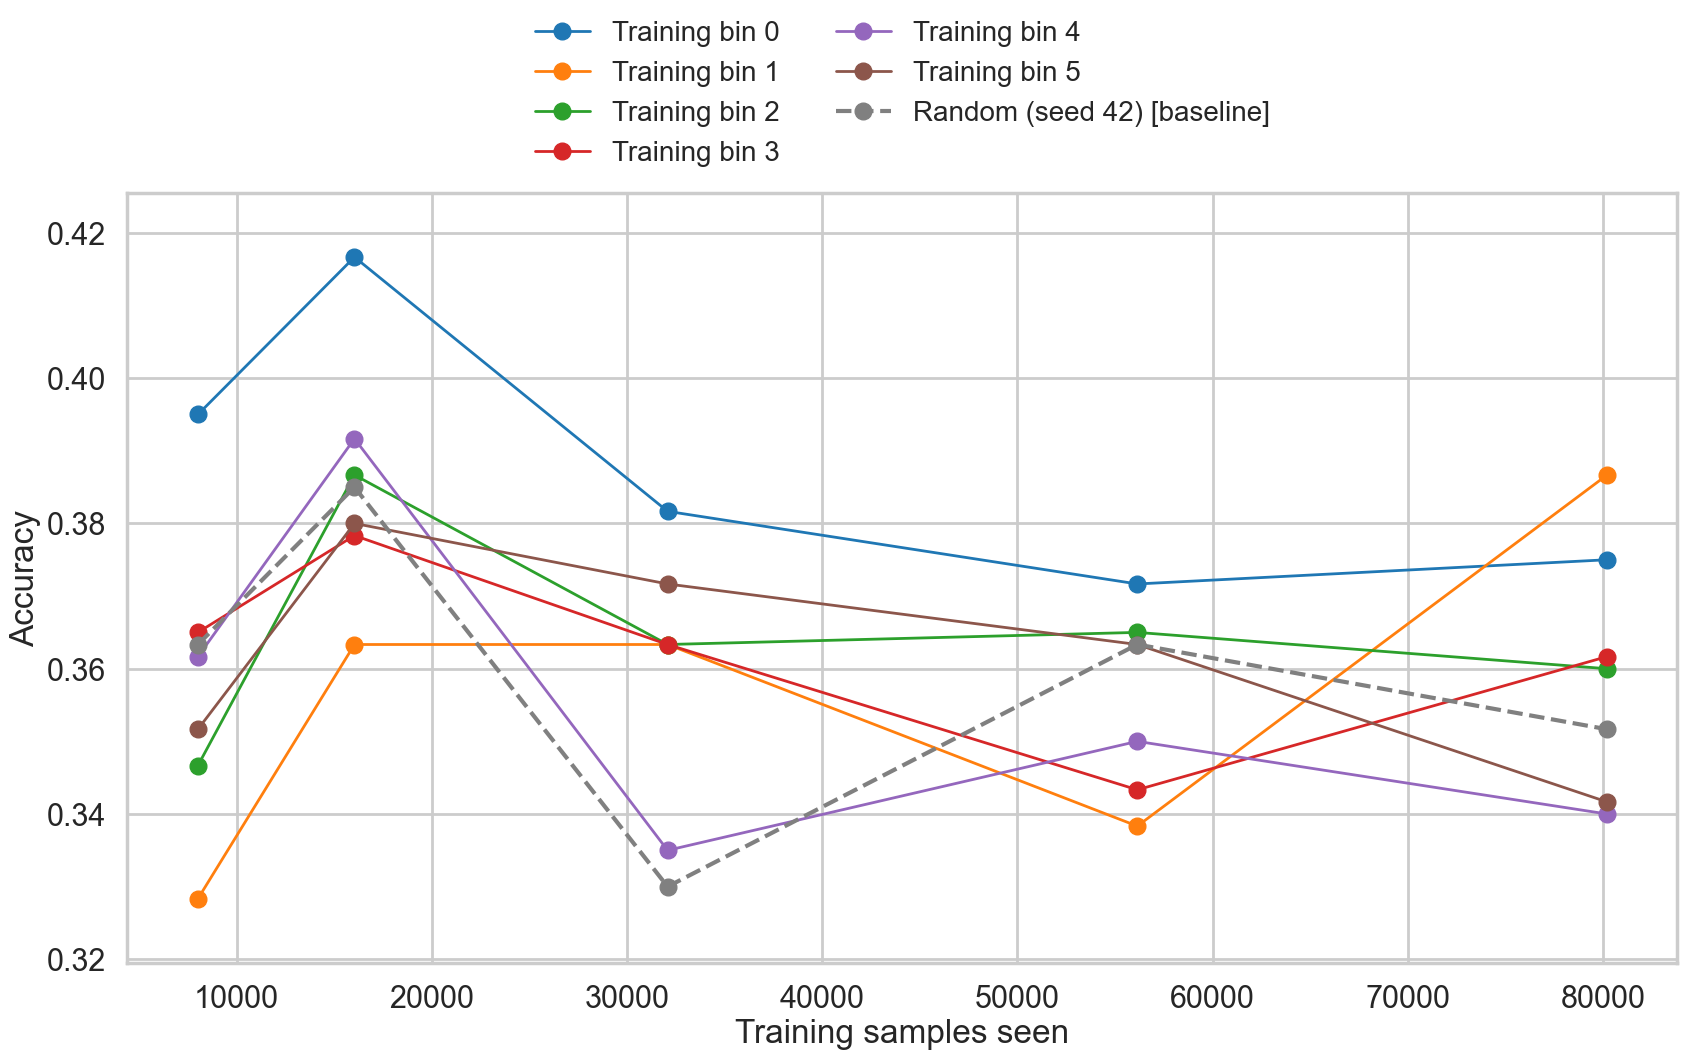

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions
Training bin 0,"1,604",50,"80,200",0.3750,0.4167,10,Unavailable (one training seed per model),600
Training bin 1,"1,604",50,"80,200",0.3867,0.3867,50,Unavailable (one training seed per model),600
Training bin 2,"1,604",50,"80,200",0.3600,0.3867,10,Unavailable (one training seed per model),600
Training bin 3,"1,604",50,"80,200",0.3617,0.3783,10,Unavailable (one training seed per model),600
Training bin 4,"1,604",50,"80,200",0.3400,0.3917,10,Unavailable (one training seed per model),600
Training bin 5,"1,604",50,"80,200",0.3417,0.3800,10,Unavailable (one training seed per model),600
Random (seed 42) [baseline],"1,604",50,"80,200",0.3517,0.3850,10,Unavailable (one training seed per model),600


### Qwen 3B — MMLU — Random600 — cap 2048

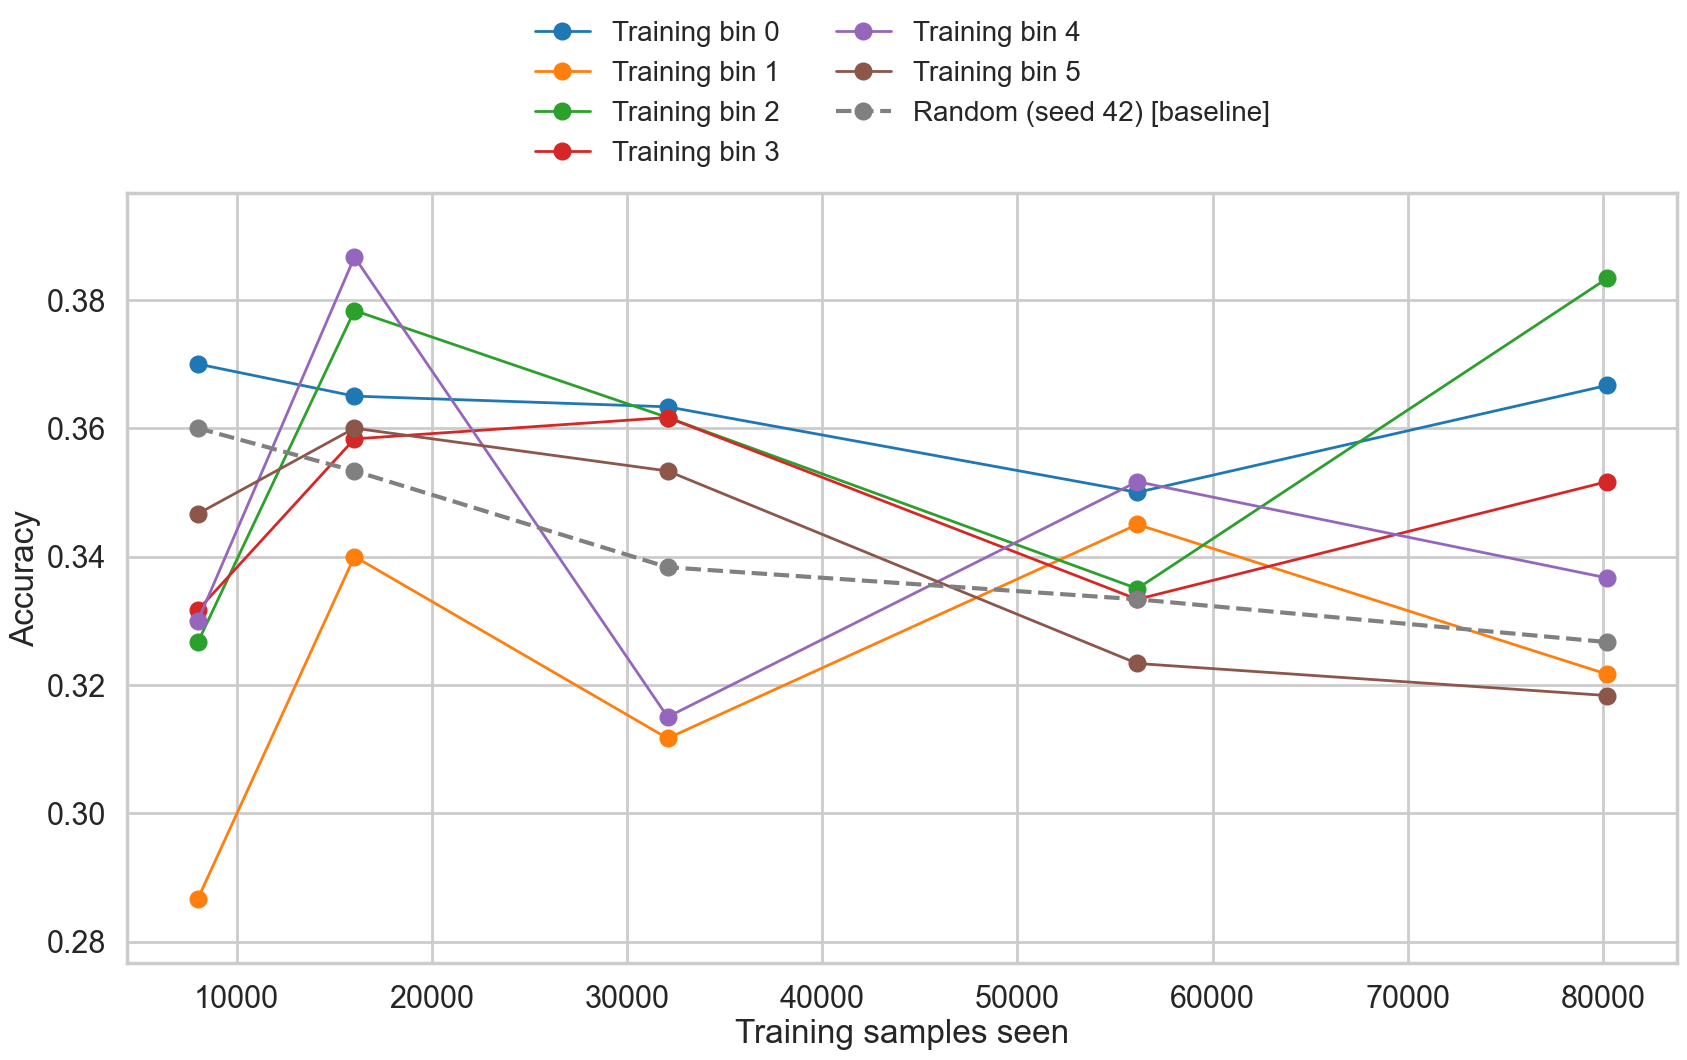

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions
Training bin 0,"1,604",50,"80,200",0.3667,0.3700,5,Unavailable (one training seed per model),600
Training bin 1,"1,604",50,"80,200",0.3217,0.3450,35,Unavailable (one training seed per model),600
Training bin 2,"1,604",50,"80,200",0.3833,0.3833,50,Unavailable (one training seed per model),600
Training bin 3,"1,604",50,"80,200",0.3517,0.3617,20,Unavailable (one training seed per model),600
Training bin 4,"1,604",50,"80,200",0.3367,0.3867,10,Unavailable (one training seed per model),600
Training bin 5,"1,604",50,"80,200",0.3183,0.3600,10,Unavailable (one training seed per model),600
Random (seed 42) [baseline],"1,604",50,"80,200",0.3267,0.3600,5,Unavailable (one training seed per model),600


### Phi-4 Mini — MMLU — Balanced600 — cap 2048

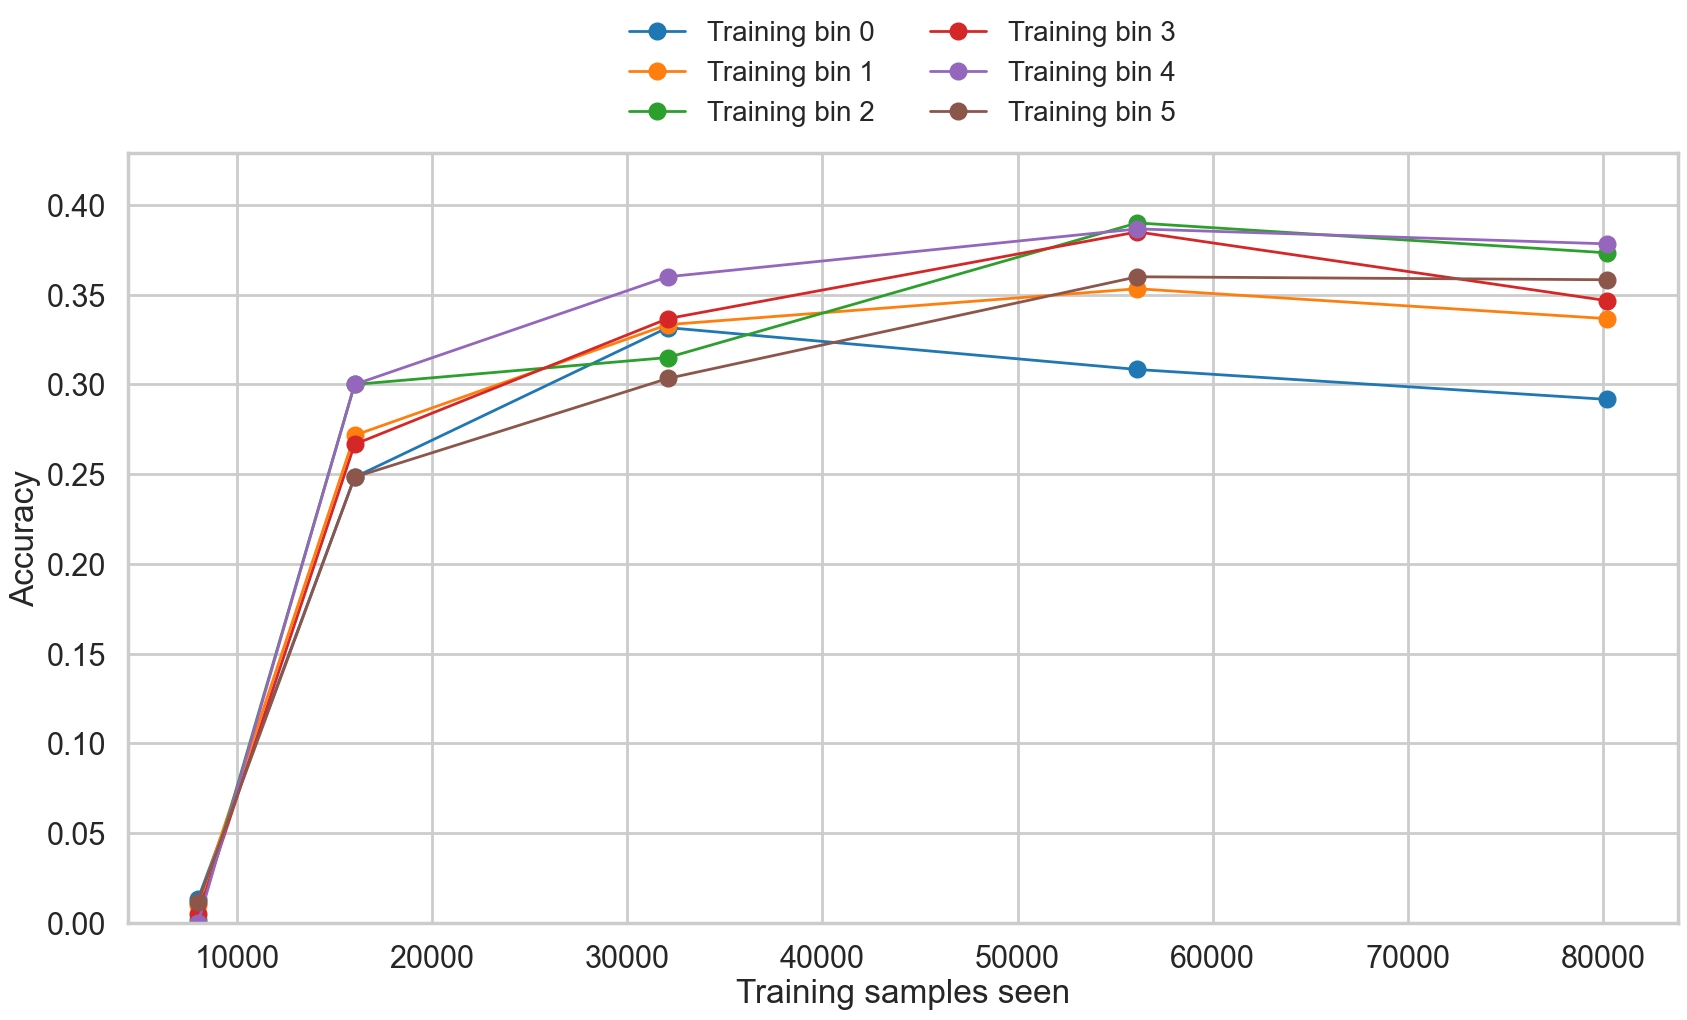

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions
Training bin 0,"1,604",50,"80,200",0.2917,0.3317,20,Unavailable (one training seed per model),600
Training bin 1,"1,604",50,"80,200",0.3367,0.3533,35,Unavailable (one training seed per model),600
Training bin 2,"1,604",50,"80,200",0.3733,0.3900,35,Unavailable (one training seed per model),600
Training bin 3,"1,604",50,"80,200",0.3467,0.3850,35,Unavailable (one training seed per model),600
Training bin 4,"1,604",50,"80,200",0.3783,0.3867,35,Unavailable (one training seed per model),600
Training bin 5,"1,604",50,"80,200",0.3583,0.3600,35,Unavailable (one training seed per model),600


### Phi-4 Mini — MMLU — Random600 — cap 2048

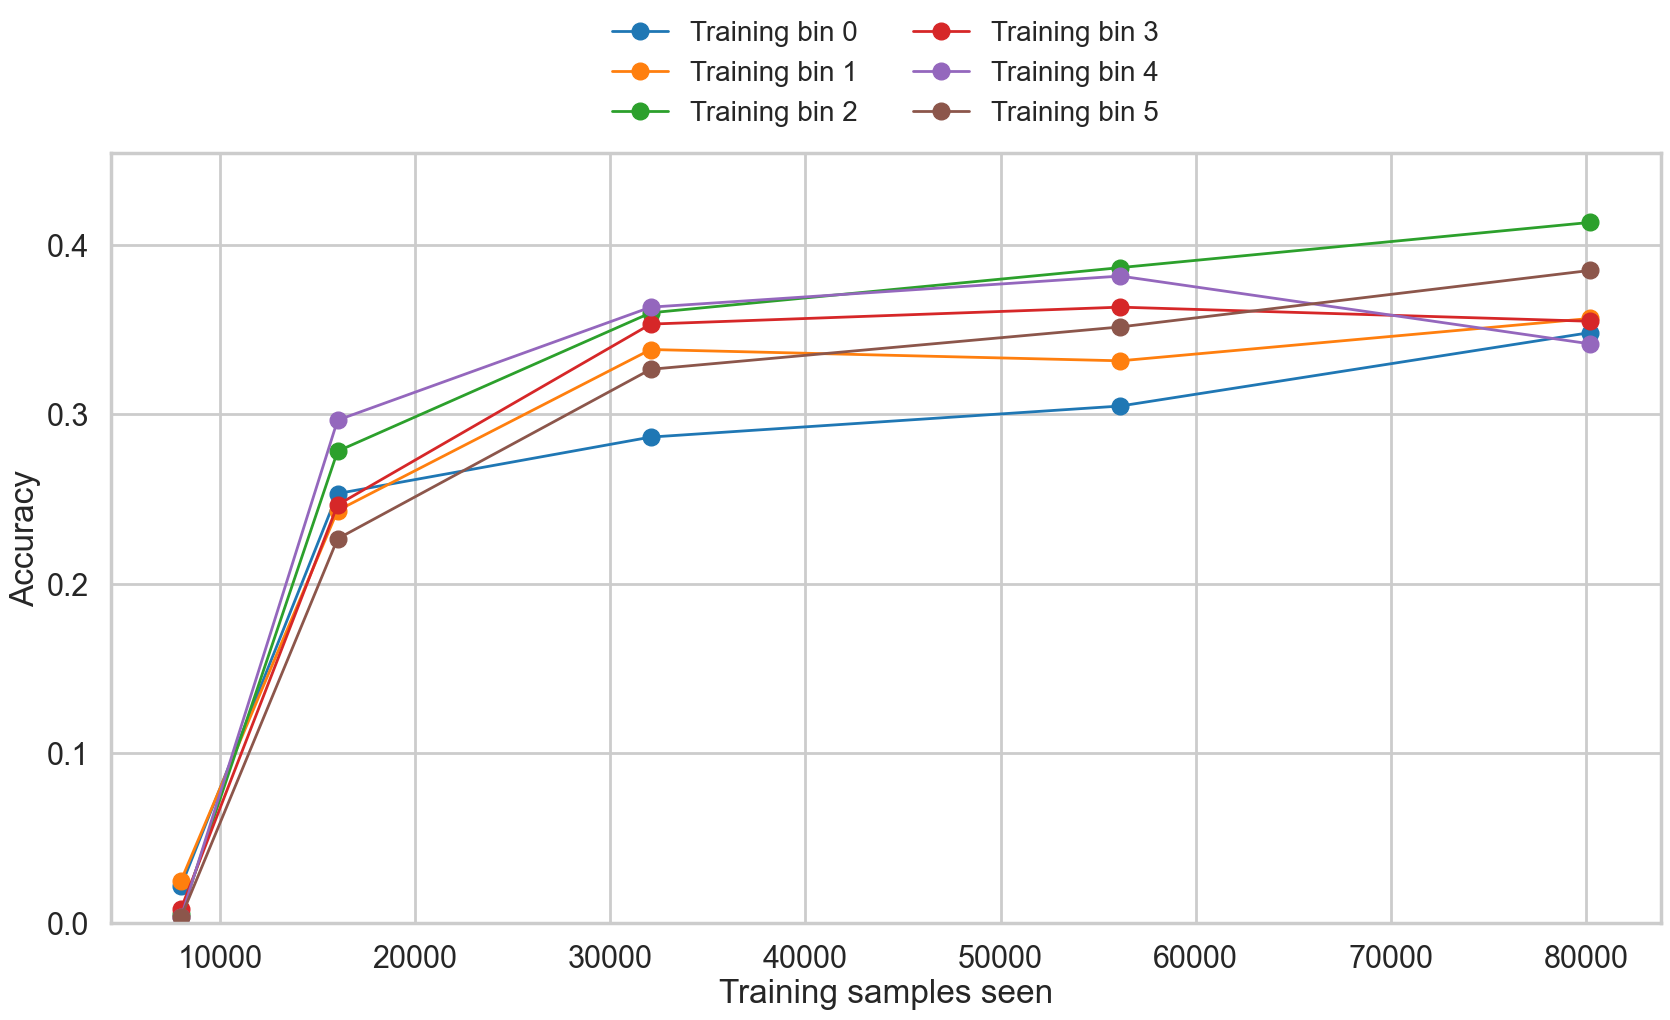

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions
Training bin 0,"1,604",50,"80,200",0.3483,0.3483,50,Unavailable (one training seed per model),600
Training bin 1,"1,604",50,"80,200",0.3567,0.3567,50,Unavailable (one training seed per model),600
Training bin 2,"1,604",50,"80,200",0.4133,0.4133,50,Unavailable (one training seed per model),600
Training bin 3,"1,604",50,"80,200",0.3550,0.3633,35,Unavailable (one training seed per model),600
Training bin 4,"1,604",50,"80,200",0.3417,0.3817,35,Unavailable (one training seed per model),600
Training bin 5,"1,604",50,"80,200",0.3850,0.3850,50,Unavailable (one training seed per model),600


### Llama 3B — MMLU — Balanced600 — cap 2048

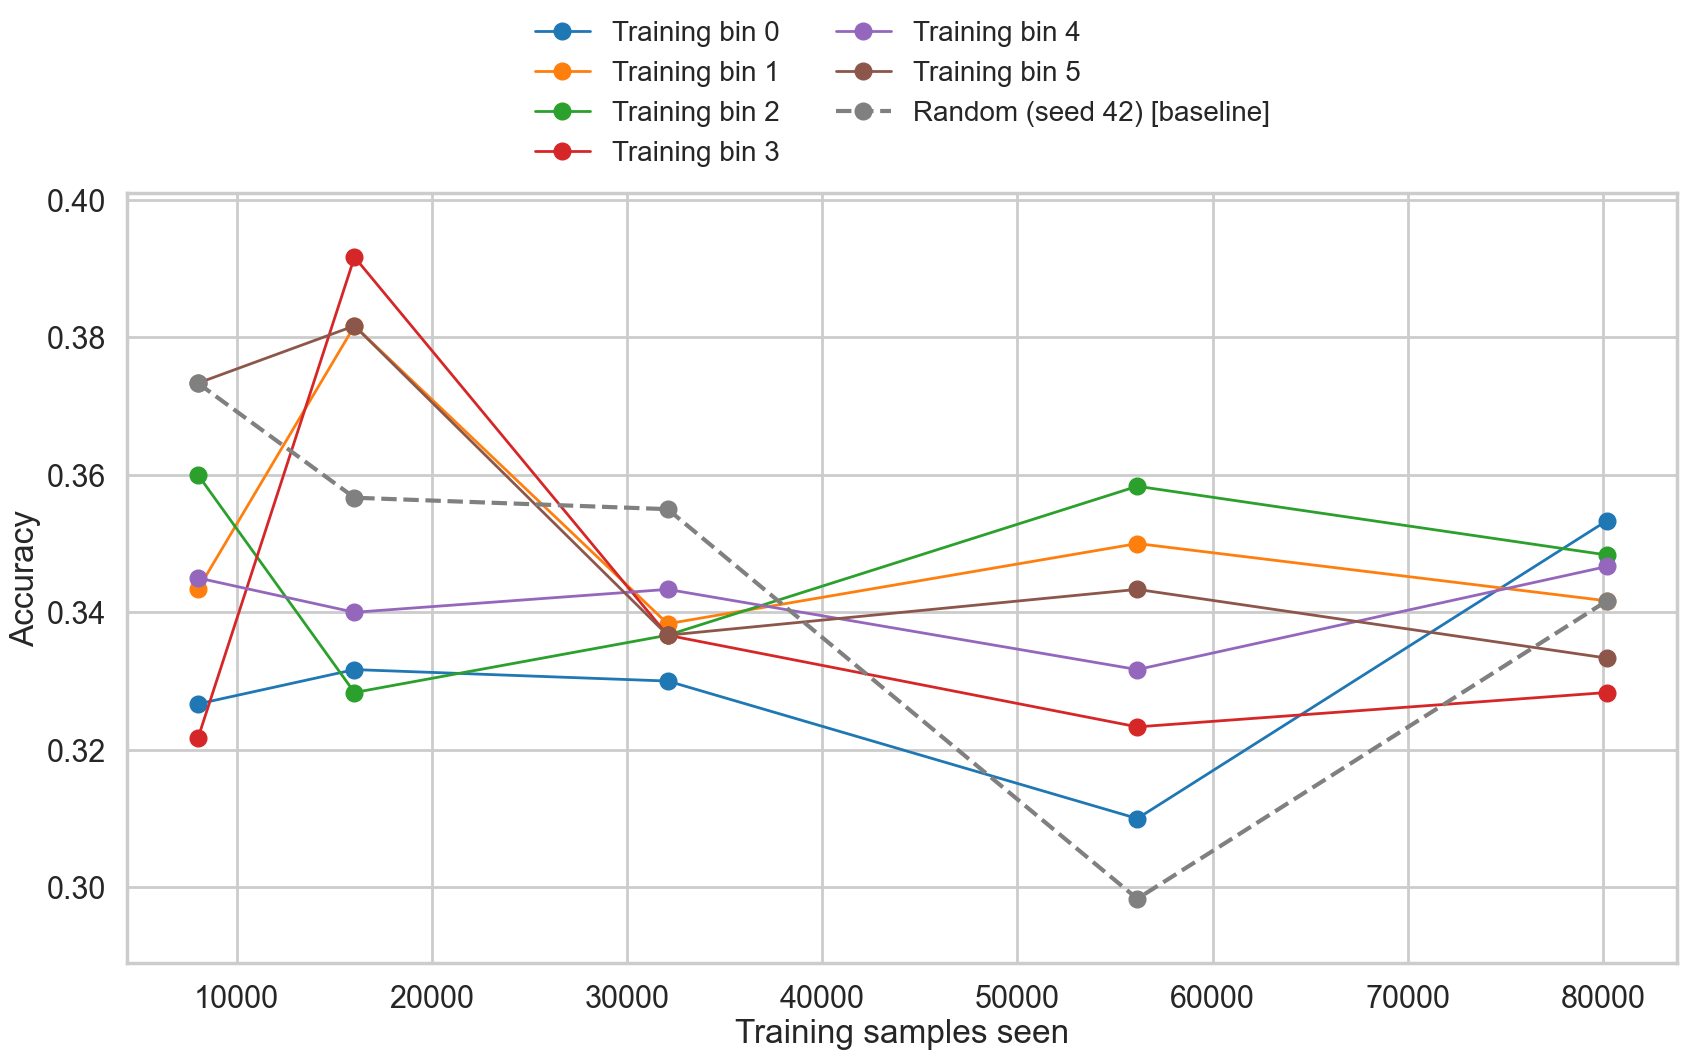

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions
Training bin 0,"1,604",50,"80,200",0.3533,0.3533,50,Unavailable (one training seed per model),600
Training bin 1,"1,604",50,"80,200",0.3417,0.3817,10,Unavailable (one training seed per model),600
Training bin 2,"1,604",50,"80,200",0.3483,0.3600,5,Unavailable (one training seed per model),600
Training bin 3,"1,604",50,"80,200",0.3283,0.3917,10,Unavailable (one training seed per model),600
Training bin 4,"1,604",50,"80,200",0.3467,0.3467,50,Unavailable (one training seed per model),600
Training bin 5,"1,604",50,"80,200",0.3333,0.3817,10,Unavailable (one training seed per model),600
Random (seed 42) [baseline],"1,604",50,"80,200",0.3417,0.3733,5,Unavailable (one training seed per model),600


### Llama 3B — MMLU — Random600 — cap 2048

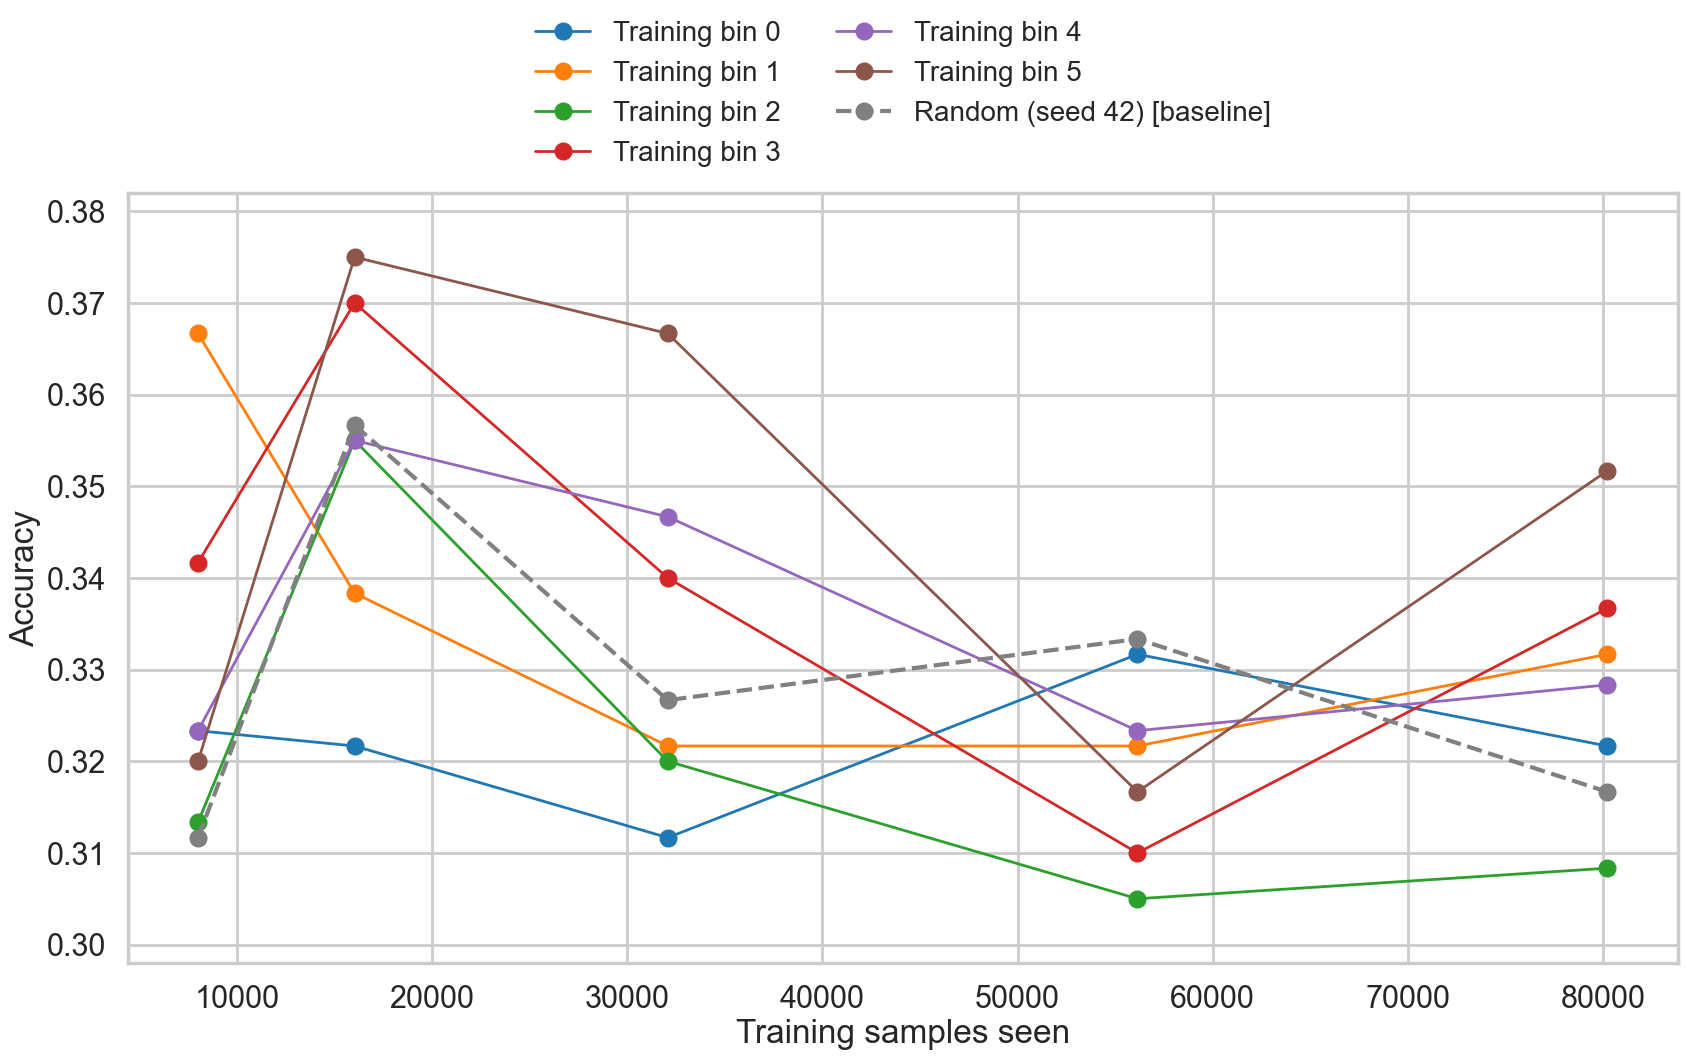

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions
Training bin 0,"1,604",50,"80,200",0.3217,0.3317,35,Unavailable (one training seed per model),600
Training bin 1,"1,604",50,"80,200",0.3317,0.3667,5,Unavailable (one training seed per model),600
Training bin 2,"1,604",50,"80,200",0.3083,0.3550,10,Unavailable (one training seed per model),600
Training bin 3,"1,604",50,"80,200",0.3367,0.3700,10,Unavailable (one training seed per model),600
Training bin 4,"1,604",50,"80,200",0.3283,0.3550,10,Unavailable (one training seed per model),600
Training bin 5,"1,604",50,"80,200",0.3517,0.3750,10,Unavailable (one training seed per model),600
Random (seed 42) [baseline],"1,604",50,"80,200",0.3167,0.3567,10,Unavailable (one training seed per model),600


In [14]:
common = results.loc[results.evaluation.isin(["random600", "balanced600"])]
for model, (nick, label) in MODELS.items():
    for (evaluation, cap), frame in common.loc[common.model.eq(model)].groupby(["evaluation", "cap"]):
        learning_plot(frame, f"{label} — MMLU — {EVAL_LABELS[evaluation]} — cap {cap}",
                      f"{nick}_{evaluation}_accuracy_cap{cap}")


## Common-test accuracy averaged across models

The first comparison gives equal weight to all three models and includes all
six training bins. The second gives equal weight to Qwen and Llama and includes
their random-training baselines as well as all six bins. Every mean point requires
every named model at that observed training-sample budget; no values are extrapolated
or interpolated. The tables describe the mean curve's final and best checkpoints.


### All-model mean (3 models) — Balanced600 — cap 2048

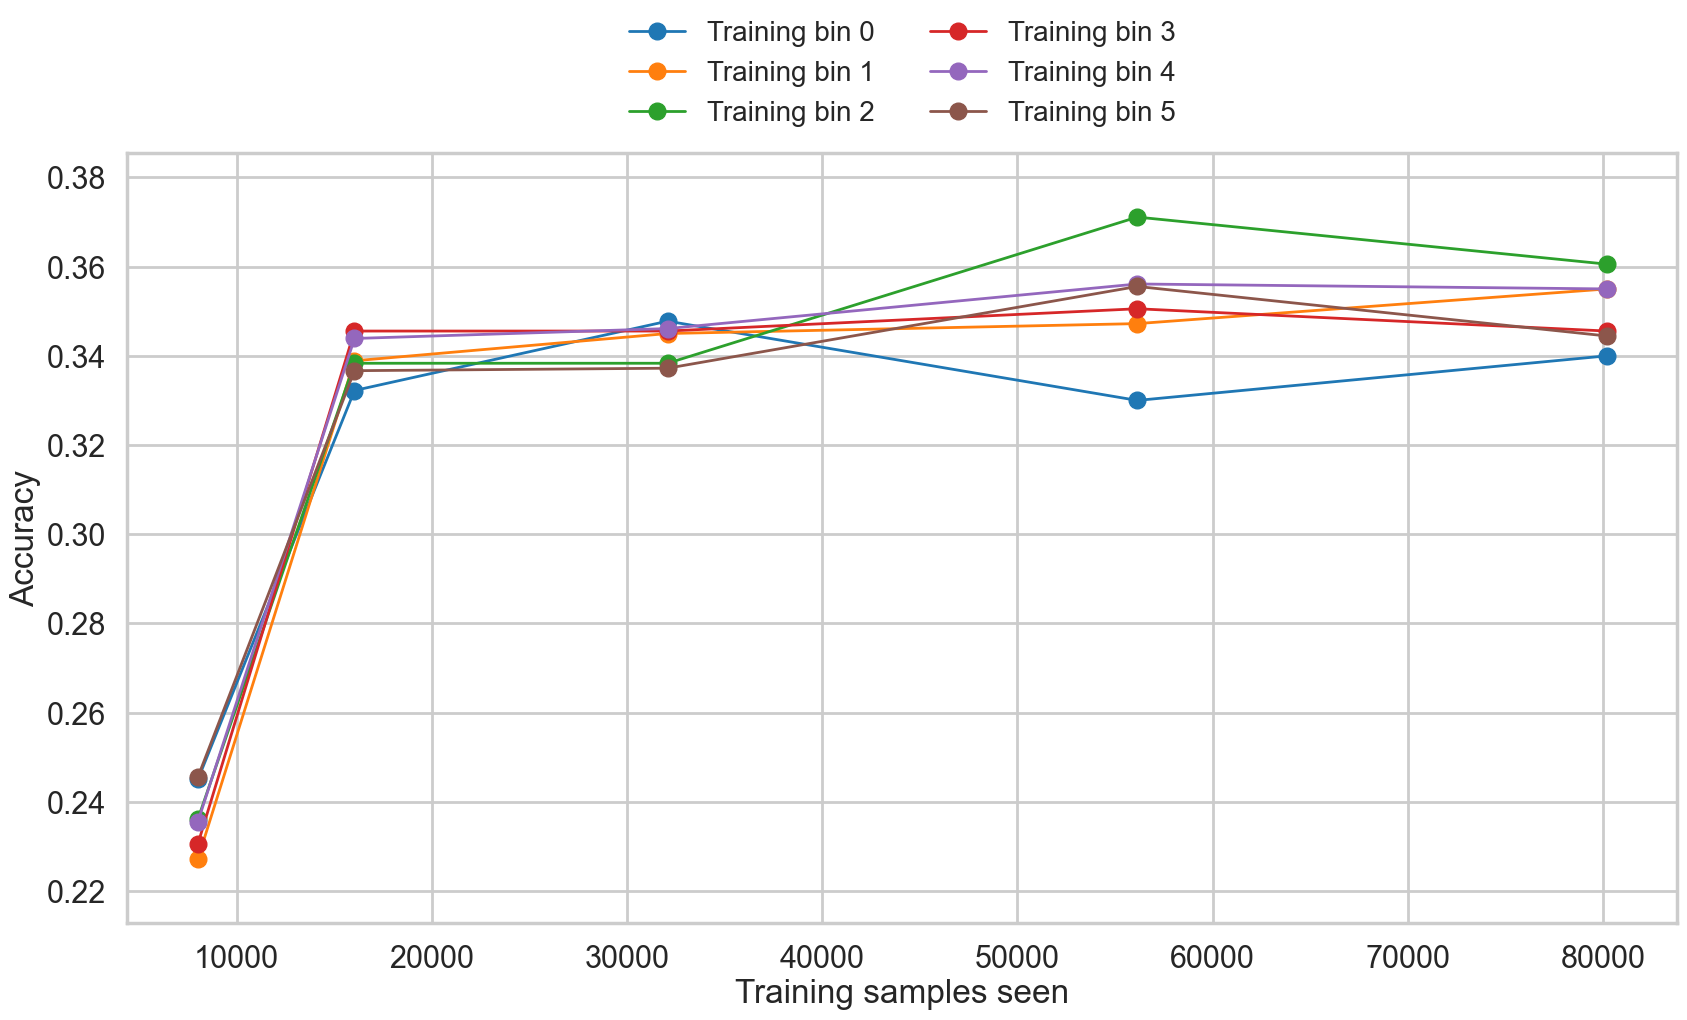

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Models
Training bin 0,"1,604",50,"80,200",0.3400,0.3478,20,Unavailable (one training seed per model),3
Training bin 1,"1,604",50,"80,200",0.3550,0.3550,50,Unavailable (one training seed per model),3
Training bin 2,"1,604",50,"80,200",0.3606,0.3711,35,Unavailable (one training seed per model),3
Training bin 3,"1,604",50,"80,200",0.3456,0.3506,35,Unavailable (one training seed per model),3
Training bin 4,"1,604",50,"80,200",0.3550,0.3561,35,Unavailable (one training seed per model),3
Training bin 5,"1,604",50,"80,200",0.3444,0.3556,35,Unavailable (one training seed per model),3


### Qwen + Llama mean — bins vs random — Balanced600 — cap 2048

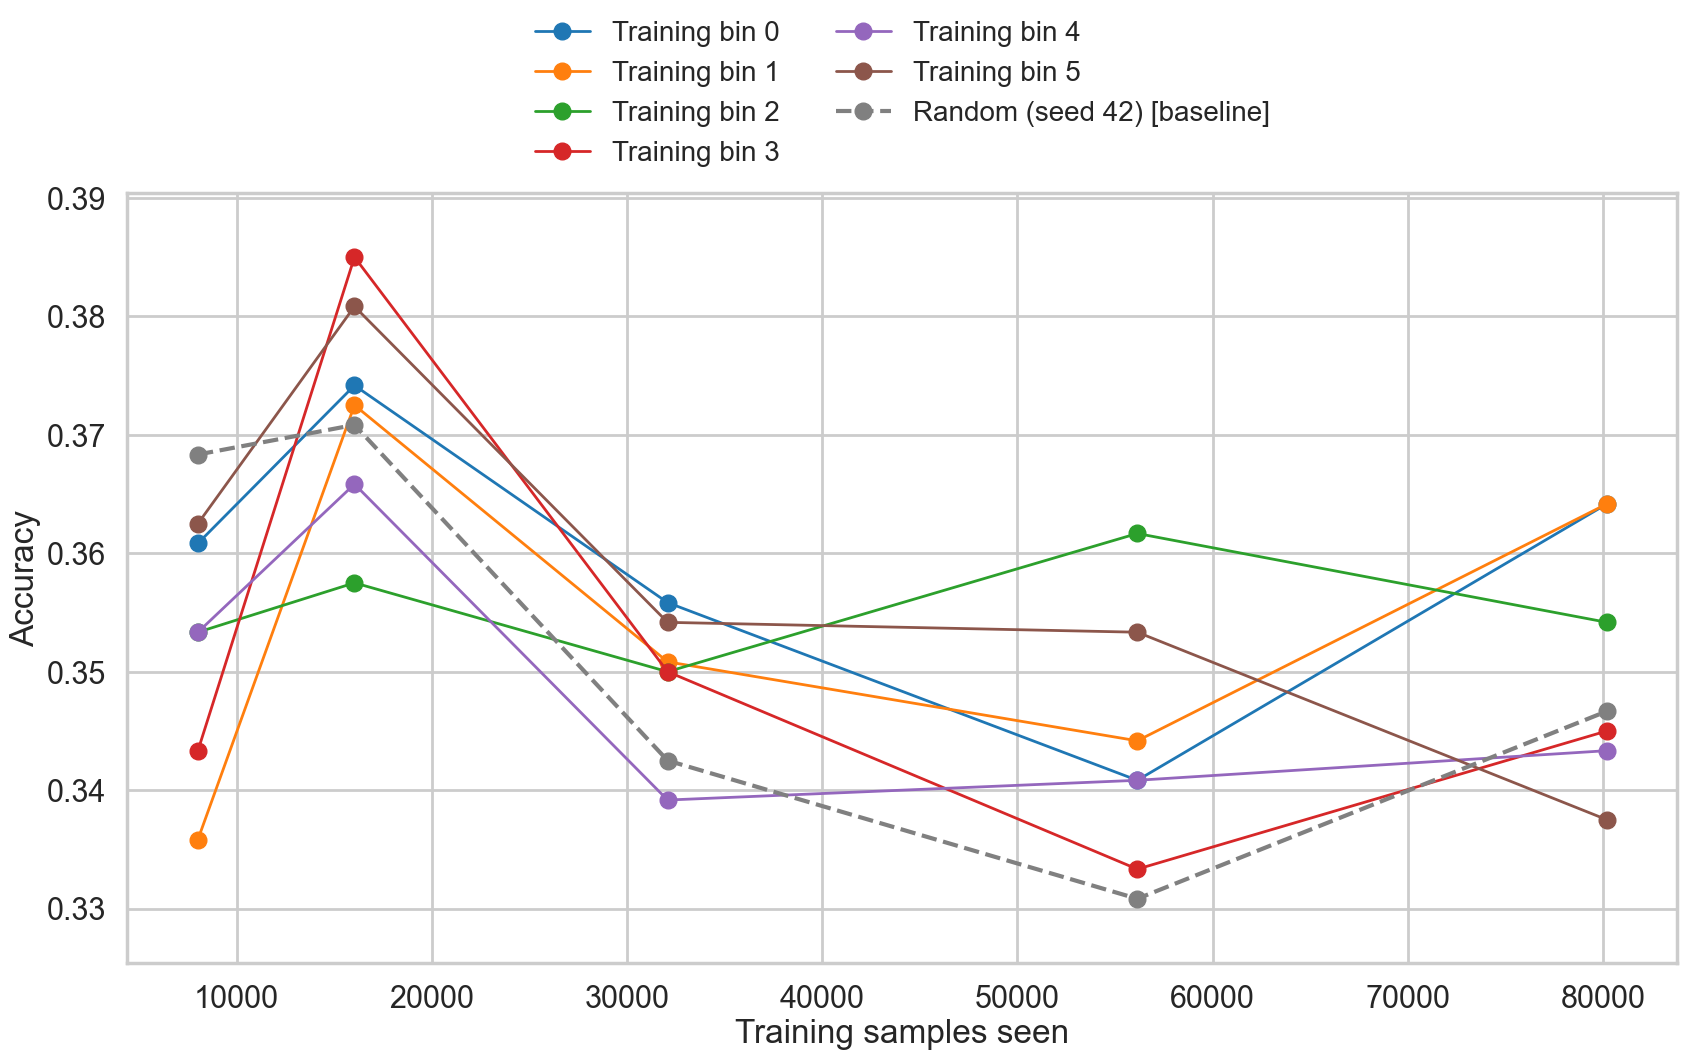

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Models
Training bin 0,"1,604",50,"80,200",0.3642,0.3742,10,Unavailable (one training seed per model),2
Training bin 1,"1,604",50,"80,200",0.3642,0.3725,10,Unavailable (one training seed per model),2
Training bin 2,"1,604",50,"80,200",0.3542,0.3617,35,Unavailable (one training seed per model),2
Training bin 3,"1,604",50,"80,200",0.3450,0.3850,10,Unavailable (one training seed per model),2
Training bin 4,"1,604",50,"80,200",0.3433,0.3658,10,Unavailable (one training seed per model),2
Training bin 5,"1,604",50,"80,200",0.3375,0.3808,10,Unavailable (one training seed per model),2
Random (seed 42) [baseline],"1,604",50,"80,200",0.3467,0.3708,10,Unavailable (one training seed per model),2


### All-model mean (3 models) — Random600 — cap 2048

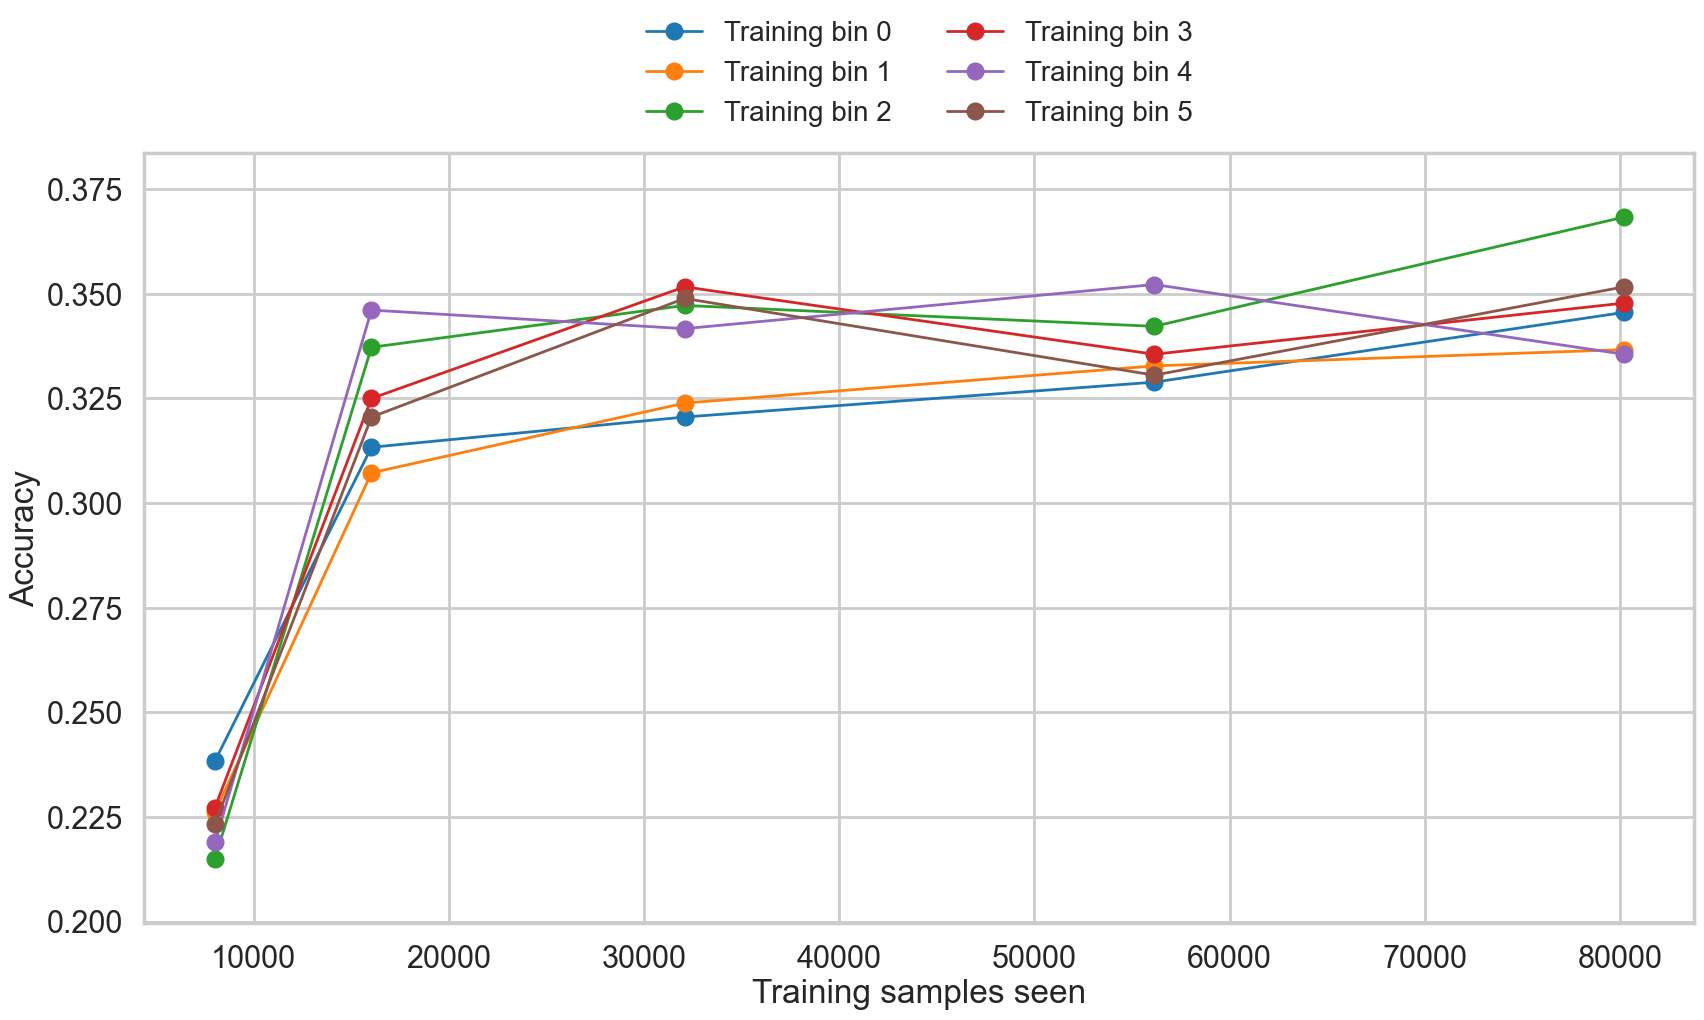

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Models
Training bin 0,"1,604",50,"80,200",0.3456,0.3456,50,Unavailable (one training seed per model),3
Training bin 1,"1,604",50,"80,200",0.3367,0.3367,50,Unavailable (one training seed per model),3
Training bin 2,"1,604",50,"80,200",0.3683,0.3683,50,Unavailable (one training seed per model),3
Training bin 3,"1,604",50,"80,200",0.3478,0.3517,20,Unavailable (one training seed per model),3
Training bin 4,"1,604",50,"80,200",0.3356,0.3522,35,Unavailable (one training seed per model),3
Training bin 5,"1,604",50,"80,200",0.3517,0.3517,50,Unavailable (one training seed per model),3


### Qwen + Llama mean — bins vs random — Random600 — cap 2048

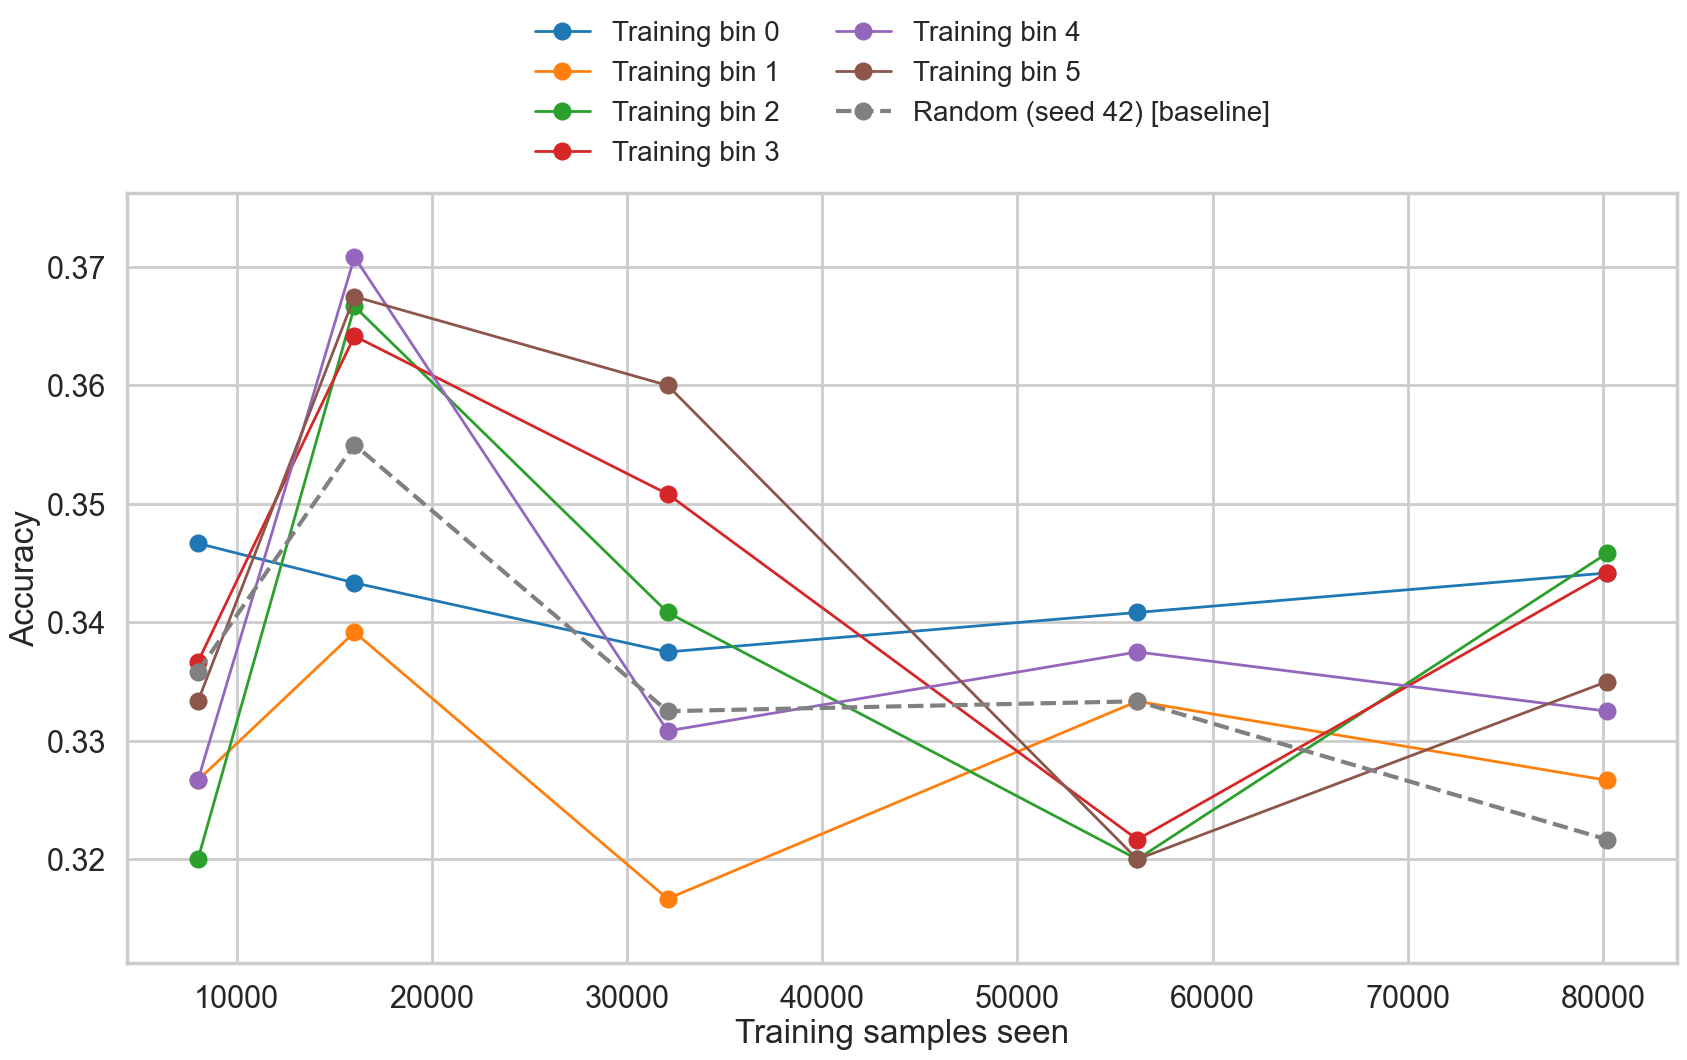

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Models
Training bin 0,"1,604",50,"80,200",0.3442,0.3467,5,Unavailable (one training seed per model),2
Training bin 1,"1,604",50,"80,200",0.3267,0.3392,10,Unavailable (one training seed per model),2
Training bin 2,"1,604",50,"80,200",0.3458,0.3667,10,Unavailable (one training seed per model),2
Training bin 3,"1,604",50,"80,200",0.3442,0.3642,10,Unavailable (one training seed per model),2
Training bin 4,"1,604",50,"80,200",0.3325,0.3708,10,Unavailable (one training seed per model),2
Training bin 5,"1,604",50,"80,200",0.3350,0.3675,10,Unavailable (one training seed per model),2
Random (seed 42) [baseline],"1,604",50,"80,200",0.3217,0.3550,10,Unavailable (one training seed per model),2


In [15]:
for (evaluation, cap), frame in common.groupby(["evaluation", "cap"]):
    all_models = list(MODELS)
    averaged = model_mean(frame, all_models, ARMS)
    learning_plot(averaged, f"All-model mean (3 models) — {EVAL_LABELS[evaluation]} — cap {cap}",
                  f"all_models_{evaluation}_accuracy_cap{cap}")
    baseline_models = ["Qwen2.5-3B-Instruct", "llama_3b"]
    averaged = model_mean(frame, baseline_models, [*ARMS, "random"])
    learning_plot(averaged, f"Qwen + Llama mean — bins vs random — {EVAL_LABELS[evaluation]} — cap {cap}",
                  f"qwen_llama_bins_vs_random_{evaluation}_cap{cap}")


## Cross-bin transfer at final and best balanced600 checkpoints

Rows identify the training bin (plus random training where available); columns
identify the held-out probe bin. Every row uses one checkpoint for all six columns.
The final matrix uses the latest complete probe checkpoint; the best matrix selects
the checkpoint with maximum balanced600 accuracy, breaking ties by earliest epoch.
The tables include the selected checkpoint and its balanced600 accuracy alongside
the final and best results. These heatmaps show absolute accuracy, not gains against
an unrecorded base-model evaluation. All matrices share the 0–1 colour scale.


### Qwen 3B — cross-bin transfer — Final checkpoint — cap 2048

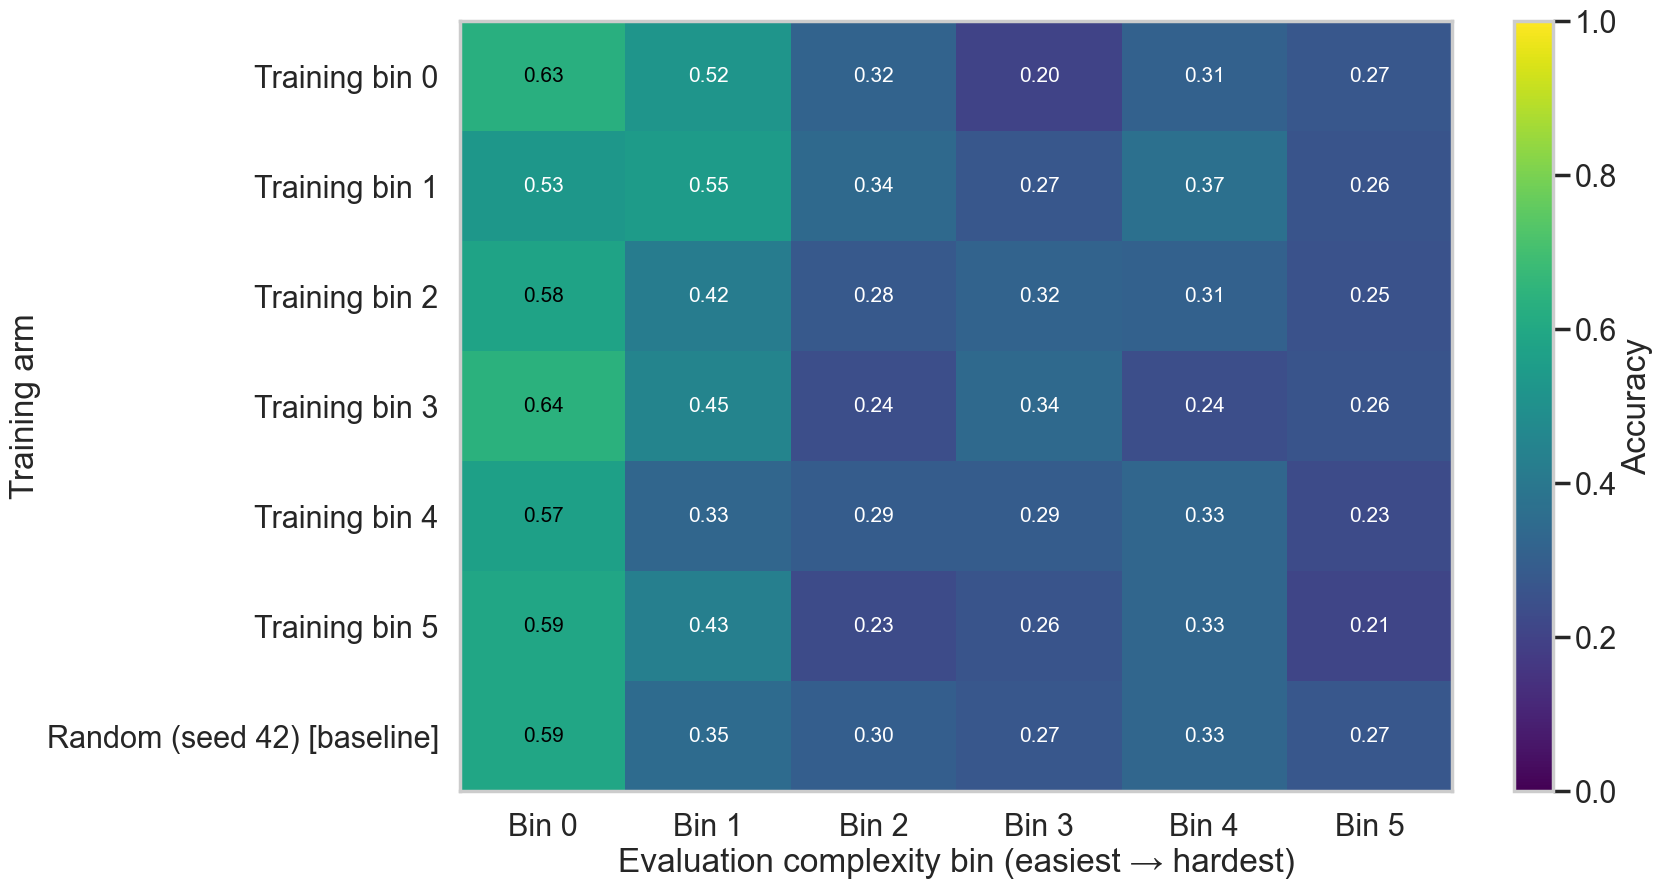

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions,Selected epoch,Selected checkpoint,Selected accuracy
Training bin 0,"1,604",50,"80,200",0.3750,0.4167,10,Unavailable (one training seed per model),600,50.000000,checkpoint-1350,0.3750
Training bin 1,"1,604",50,"80,200",0.3867,0.3867,50,Unavailable (one training seed per model),600,50.000000,checkpoint-1200,0.3867
Training bin 2,"1,604",50,"80,200",0.3600,0.3867,10,Unavailable (one training seed per model),600,50.000000,checkpoint-1250,0.3600
Training bin 3,"1,604",50,"80,200",0.3617,0.3783,10,Unavailable (one training seed per model),600,50.000000,checkpoint-1200,0.3617
Training bin 4,"1,604",50,"80,200",0.3400,0.3917,10,Unavailable (one training seed per model),600,50.000000,checkpoint-1300,0.3400
Training bin 5,"1,604",50,"80,200",0.3417,0.3800,10,Unavailable (one training seed per model),600,50.000000,checkpoint-1250,0.3417
Random (seed 42) [baseline],"1,604",50,"80,200",0.3517,0.3850,10,Unavailable (one training seed per model),600,50.000000,checkpoint-1300,0.3517


### Qwen 3B — cross-bin transfer — Best balanced600 checkpoint — cap 2048

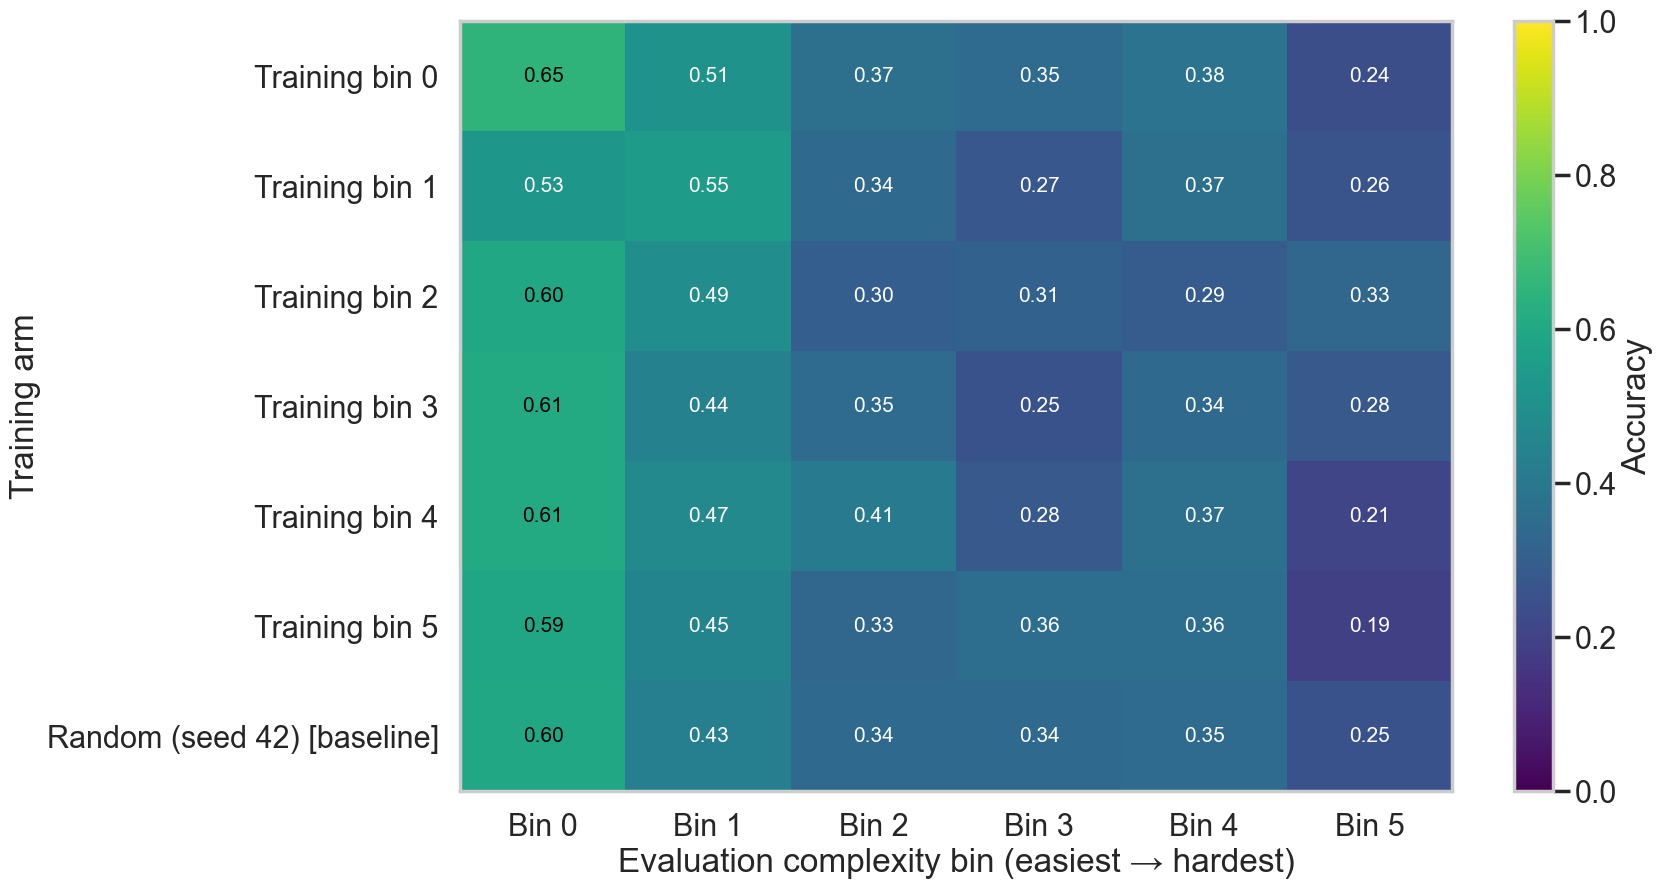

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions,Selected epoch,Selected checkpoint,Selected accuracy
Training bin 0,"1,604",50,"80,200",0.3750,0.4167,10,Unavailable (one training seed per model),600,10.000000,checkpoint-270,0.4167
Training bin 1,"1,604",50,"80,200",0.3867,0.3867,50,Unavailable (one training seed per model),600,50.000000,checkpoint-1200,0.3867
Training bin 2,"1,604",50,"80,200",0.3600,0.3867,10,Unavailable (one training seed per model),600,10.000000,checkpoint-250,0.3867
Training bin 3,"1,604",50,"80,200",0.3617,0.3783,10,Unavailable (one training seed per model),600,10.000000,checkpoint-240,0.3783
Training bin 4,"1,604",50,"80,200",0.3400,0.3917,10,Unavailable (one training seed per model),600,10.000000,checkpoint-260,0.3917
Training bin 5,"1,604",50,"80,200",0.3417,0.3800,10,Unavailable (one training seed per model),600,10.000000,checkpoint-250,0.3800
Random (seed 42) [baseline],"1,604",50,"80,200",0.3517,0.3850,10,Unavailable (one training seed per model),600,10.000000,checkpoint-260,0.3850


### Phi-4 Mini — cross-bin transfer — Final checkpoint — cap 2048

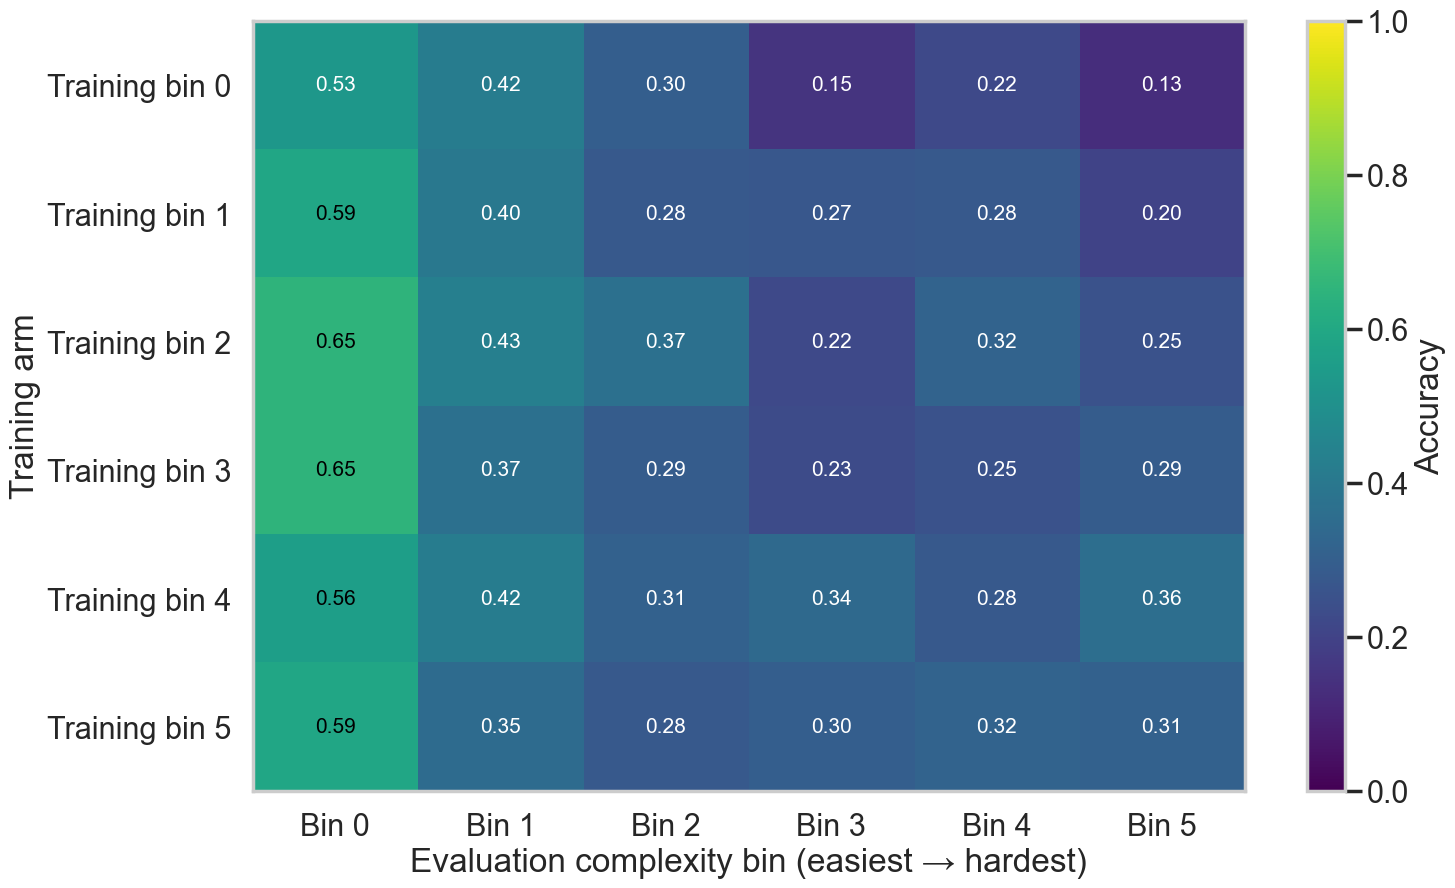

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions,Selected epoch,Selected checkpoint,Selected accuracy
Training bin 0,"1,604",50,"80,200",0.2917,0.3317,20,Unavailable (one training seed per model),600,50.000000,checkpoint-1250,0.2917
Training bin 1,"1,604",50,"80,200",0.3367,0.3533,35,Unavailable (one training seed per model),600,50.000000,checkpoint-1200,0.3367
Training bin 2,"1,604",50,"80,200",0.3733,0.3900,35,Unavailable (one training seed per model),600,50.000000,checkpoint-1300,0.3733
Training bin 3,"1,604",50,"80,200",0.3467,0.3850,35,Unavailable (one training seed per model),600,50.000000,checkpoint-1300,0.3467
Training bin 4,"1,604",50,"80,200",0.3783,0.3867,35,Unavailable (one training seed per model),600,50.000000,checkpoint-1300,0.3783
Training bin 5,"1,604",50,"80,200",0.3583,0.3600,35,Unavailable (one training seed per model),600,50.000000,checkpoint-1250,0.3583


### Phi-4 Mini — cross-bin transfer — Best balanced600 checkpoint — cap 2048

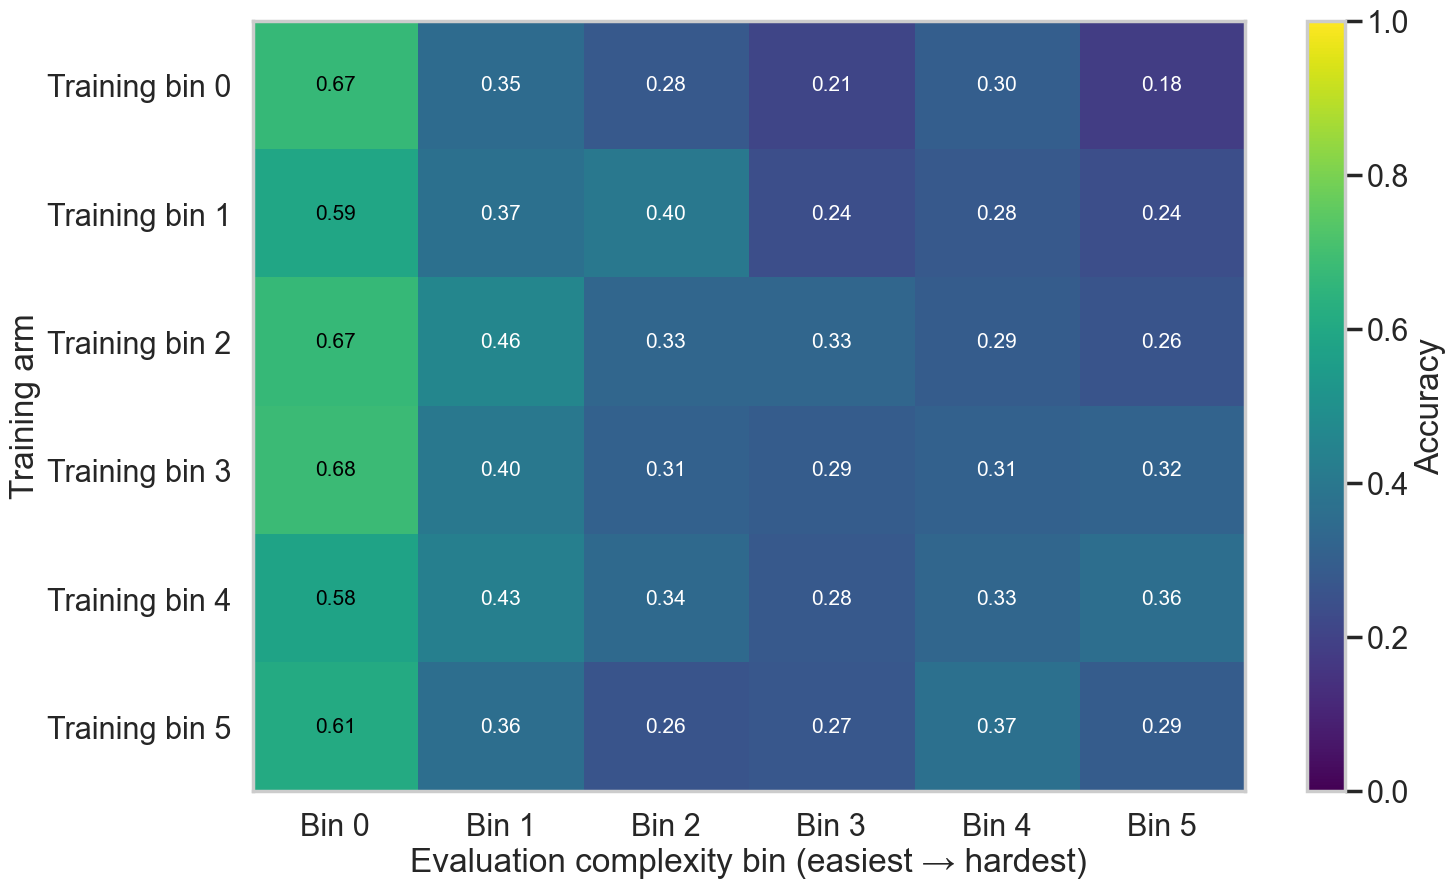

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions,Selected epoch,Selected checkpoint,Selected accuracy
Training bin 0,"1,604",50,"80,200",0.2917,0.3317,20,Unavailable (one training seed per model),600,20.000000,checkpoint-500,0.3317
Training bin 1,"1,604",50,"80,200",0.3367,0.3533,35,Unavailable (one training seed per model),600,35.000000,checkpoint-840,0.3533
Training bin 2,"1,604",50,"80,200",0.3733,0.3900,35,Unavailable (one training seed per model),600,35.000000,checkpoint-910,0.3900
Training bin 3,"1,604",50,"80,200",0.3467,0.3850,35,Unavailable (one training seed per model),600,35.000000,checkpoint-910,0.3850
Training bin 4,"1,604",50,"80,200",0.3783,0.3867,35,Unavailable (one training seed per model),600,35.000000,checkpoint-910,0.3867
Training bin 5,"1,604",50,"80,200",0.3583,0.3600,35,Unavailable (one training seed per model),600,35.000000,checkpoint-875,0.3600


### Llama 3B — cross-bin transfer — Final checkpoint — cap 2048

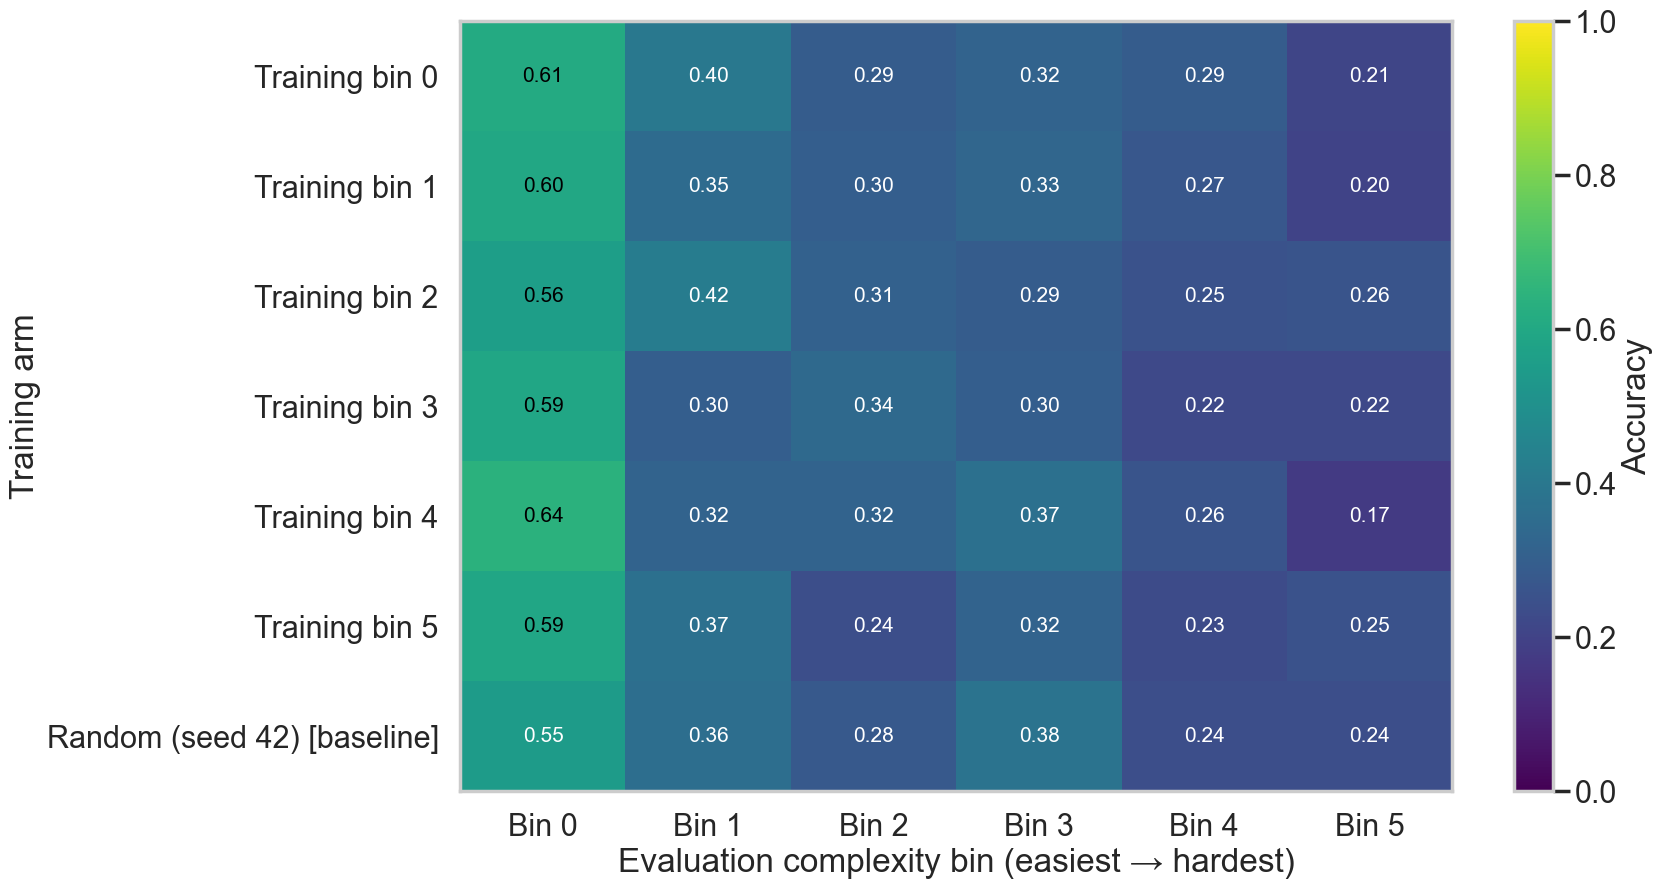

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions,Selected epoch,Selected checkpoint,Selected accuracy
Training bin 0,"1,604",50,"80,200",0.3533,0.3533,50,Unavailable (one training seed per model),600,50.000000,checkpoint-1350,0.3533
Training bin 1,"1,604",50,"80,200",0.3417,0.3817,10,Unavailable (one training seed per model),600,50.000000,checkpoint-1350,0.3417
Training bin 2,"1,604",50,"80,200",0.3483,0.3600,5,Unavailable (one training seed per model),600,50.000000,checkpoint-1250,0.3483
Training bin 3,"1,604",50,"80,200",0.3283,0.3917,10,Unavailable (one training seed per model),600,50.000000,checkpoint-1200,0.3283
Training bin 4,"1,604",50,"80,200",0.3467,0.3467,50,Unavailable (one training seed per model),600,50.000000,checkpoint-1350,0.3467
Training bin 5,"1,604",50,"80,200",0.3333,0.3817,10,Unavailable (one training seed per model),600,50.000000,checkpoint-1300,0.3333
Random (seed 42) [baseline],"1,604",50,"80,200",0.3417,0.3733,5,Unavailable (one training seed per model),600,50.000000,checkpoint-1300,0.3417


### Llama 3B — cross-bin transfer — Best balanced600 checkpoint — cap 2048

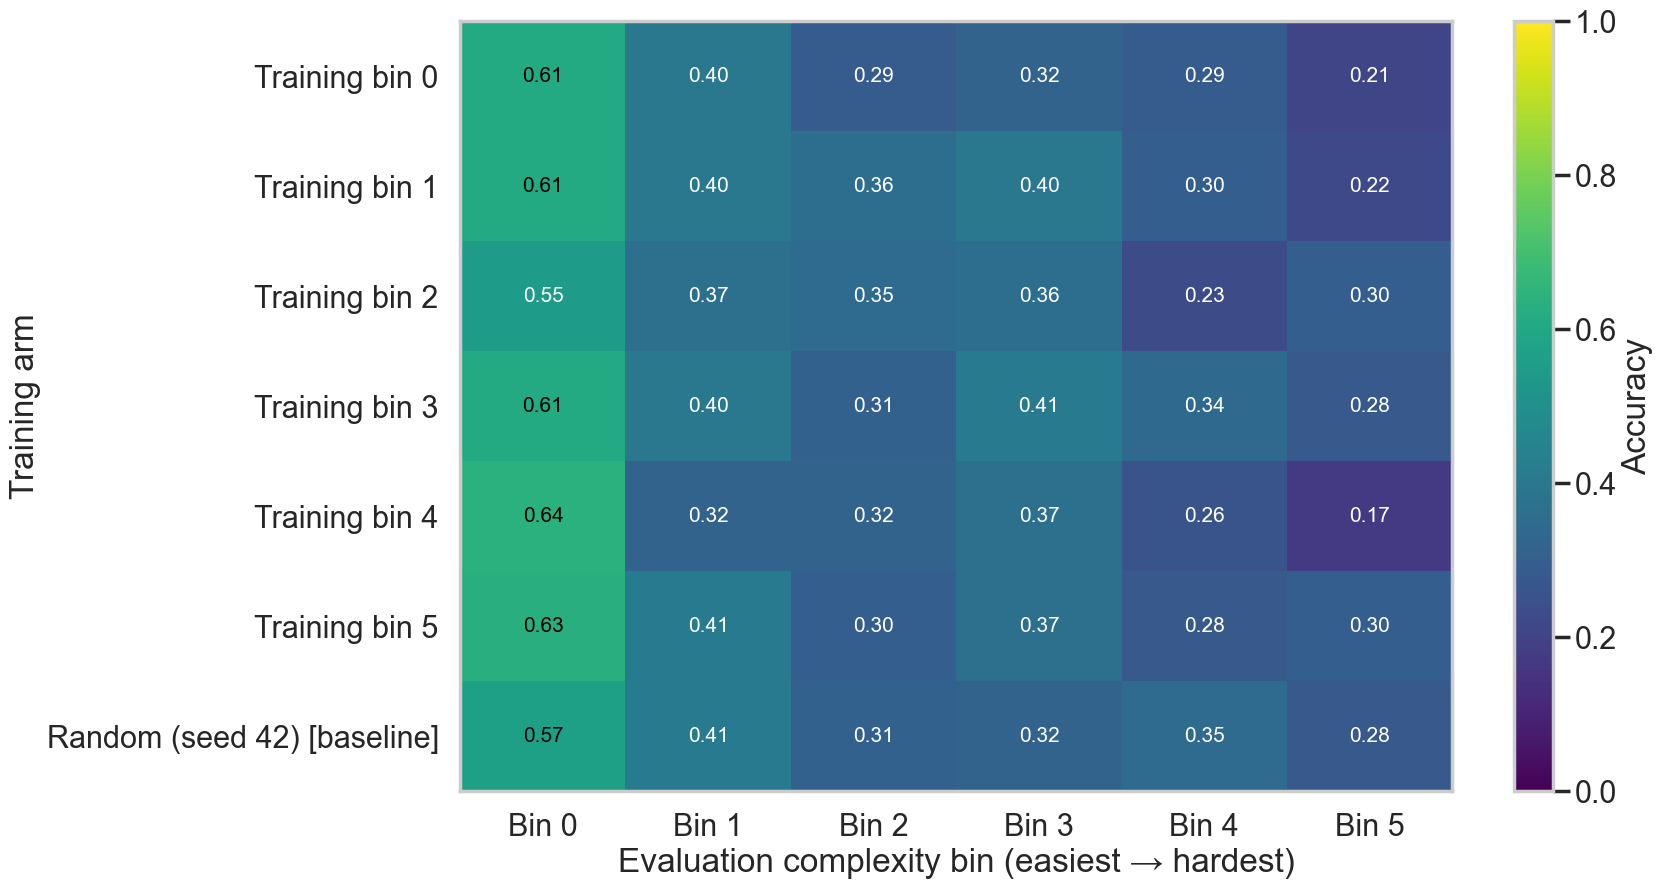

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions,Selected epoch,Selected checkpoint,Selected accuracy
Training bin 0,"1,604",50,"80,200",0.3533,0.3533,50,Unavailable (one training seed per model),600,50.000000,checkpoint-1350,0.3533
Training bin 1,"1,604",50,"80,200",0.3417,0.3817,10,Unavailable (one training seed per model),600,10.000000,checkpoint-270,0.3817
Training bin 2,"1,604",50,"80,200",0.3483,0.3600,5,Unavailable (one training seed per model),600,5.000000,checkpoint-125,0.3600
Training bin 3,"1,604",50,"80,200",0.3283,0.3917,10,Unavailable (one training seed per model),600,10.000000,checkpoint-240,0.3917
Training bin 4,"1,604",50,"80,200",0.3467,0.3467,50,Unavailable (one training seed per model),600,50.000000,checkpoint-1350,0.3467
Training bin 5,"1,604",50,"80,200",0.3333,0.3817,10,Unavailable (one training seed per model),600,10.000000,checkpoint-260,0.3817
Random (seed 42) [baseline],"1,604",50,"80,200",0.3417,0.3733,5,Unavailable (one training seed per model),600,5.000000,checkpoint-130,0.3733


In [16]:
transfer_tables = {}
for model, (nick, label) in MODELS.items():
    for cap, model_balanced in balanced.loc[balanced.model.eq(model)].groupby("cap"):
        for selection in ("final", "best_balanced600"):
            matrix_rows, selected_rows = [], []
            arms = [arm for arm in [*ARMS, "random"] if arm in set(model_balanced.arm)]
            for arm in arms:
                curve = model_balanced.loc[model_balanced.arm.eq(arm)].sort_values("epoch")
                chosen = curve.iloc[-1] if selection == "final" else best_checkpoint(curve)
                probes = raw_results.loc[
                    raw_results.model.eq(model) & raw_results.arm.eq(arm)
                    & raw_results.cap.eq(cap) & raw_results.evaluation.eq("probe")
                    & raw_results.epoch.eq(chosen.epoch) & raw_results.checkpoint.eq(chosen.checkpoint)
                ].sort_values("eval_bin")
                assert len(probes) == 6 and list(probes.eval_bin) == list(range(6))
                assert np.isclose(probes.accuracy.mean(), chosen.accuracy)
                matrix_rows.append(probes.accuracy.to_numpy())
                selected_rows.append({"Training": arm_label(arm), "Selected epoch": chosen.epoch,
                                      "Selected checkpoint": chosen.checkpoint,
                                      "Selected accuracy": chosen.accuracy})
            matrix = np.vstack(matrix_rows)
            fig, ax = plt.subplots(figsize=(16, 10))
            image = ax.imshow(matrix, vmin=0, vmax=1, cmap="viridis", aspect="auto")
            ax.grid(False)
            ax.set_xticks(range(6), [f"Bin {g}" for g in range(6)])
            ax.set_yticks(range(len(arms)), [arm_label(arm) for arm in arms])
            ax.set_xlabel("Evaluation complexity bin (easiest → hardest)")
            ax.set_ylabel("Training arm")
            for i in range(len(arms)):
                for j in range(6):
                    ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                            fontsize=15, color="black" if matrix[i, j] > 0.55 else "white")
            fig.colorbar(image, ax=ax, label="Accuracy")
            name = f"{nick}_transfer_{selection}_cap{cap}"
            title = "Final checkpoint" if selection == "final" else "Best balanced600 checkpoint"
            finish_plot(fig, ax, f"{label} — cross-bin transfer — {title} — cap {cap}", name)
            table = curve_table(model_balanced).merge(pd.DataFrame(selected_rows), on="Training", validate="one_to_one")
            transfer_tables[name] = pd.DataFrame(matrix, index=arms, columns=range(6))
            show_table(table, name)


## Cross-bin transfer averaged across all three models

Each cell is the **equally weighted mean of Qwen, Phi, and Llama accuracy** for
one training-bin → evaluation-bin pair. All six training bins must be present
for every model. Bins are model-specific entropy groups, so this compares the
same ordinal difficulty bin rather than asserting identical test questions.
The random-training row is omitted because Phi has no random baseline.

For **final checkpoints**, average the three per-model final transfer matrices.
For **best balanced600 checkpoints**, select one best checkpoint independently
for each model and training bin, then average its six probe accuracies with
the other models. This is the same selection rule as the individual matrices;
it is not a single shared best epoch, and test-bin cells are never optimized
independently. The checkpoint tables show exactly which evaluations contribute.

Each selection has an absolute-accuracy heatmap and a second heatmap showing
**advantage over the six-training-bin mean on the same evaluation bin**, in
percentage points. Subtracting the column mean makes transfer differences
visible alongside the strong effect of test difficulty. Positive values mean
that a training arm outperforms the average arm on that test bin; they are
not improvements over an unrecorded base model. Both advantage heatmaps share
a symmetric colour scale.

The summary tables report mean balanced600 accuracy, accuracy on the training
arm's own bin, and **own-bin advantage versus the other five training arms**
evaluated on that same bin. All means weight models equally. These are
descriptive comparisons from one training seed per model, without seed-based
confidence intervals or claims of statistical significance.


### All-model mean (3 models) — Mean cross-bin accuracy — Final checkpoints — cap 2048

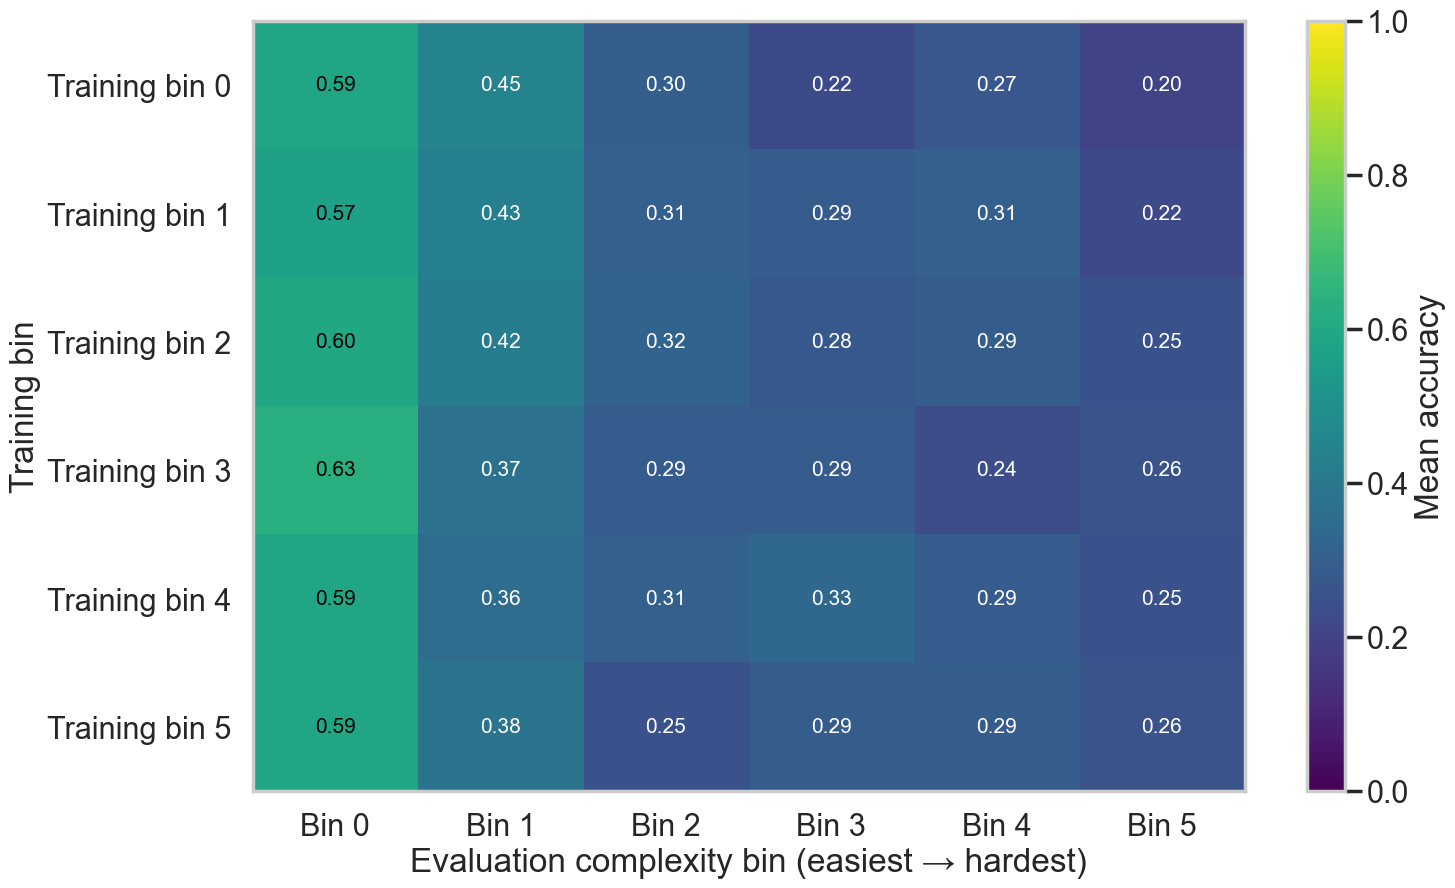

Training,Models,Mean balanced600 accuracy,Own-bin accuracy,Own-bin Δ accuracy vs other arms,95% CI (training seeds)
Training bin 0,3,0.3400,0.5900,-0.0053,Unavailable (one training seed per model)
Training bin 1,3,0.3550,0.4333,0.0367,Unavailable (one training seed per model)
Training bin 2,3,0.3606,0.3200,0.0287,Unavailable (one training seed per model)
Training bin 3,3,0.3456,0.2900,0.0067,Unavailable (one training seed per model)
Training bin 4,3,0.3550,0.2900,0.0093,Unavailable (one training seed per model)
Training bin 5,3,0.3444,0.2567,0.0193,Unavailable (one training seed per model)


### All-model mean (3 models) — Advantage over the training-bin mean — Final checkpoints — cap 2048

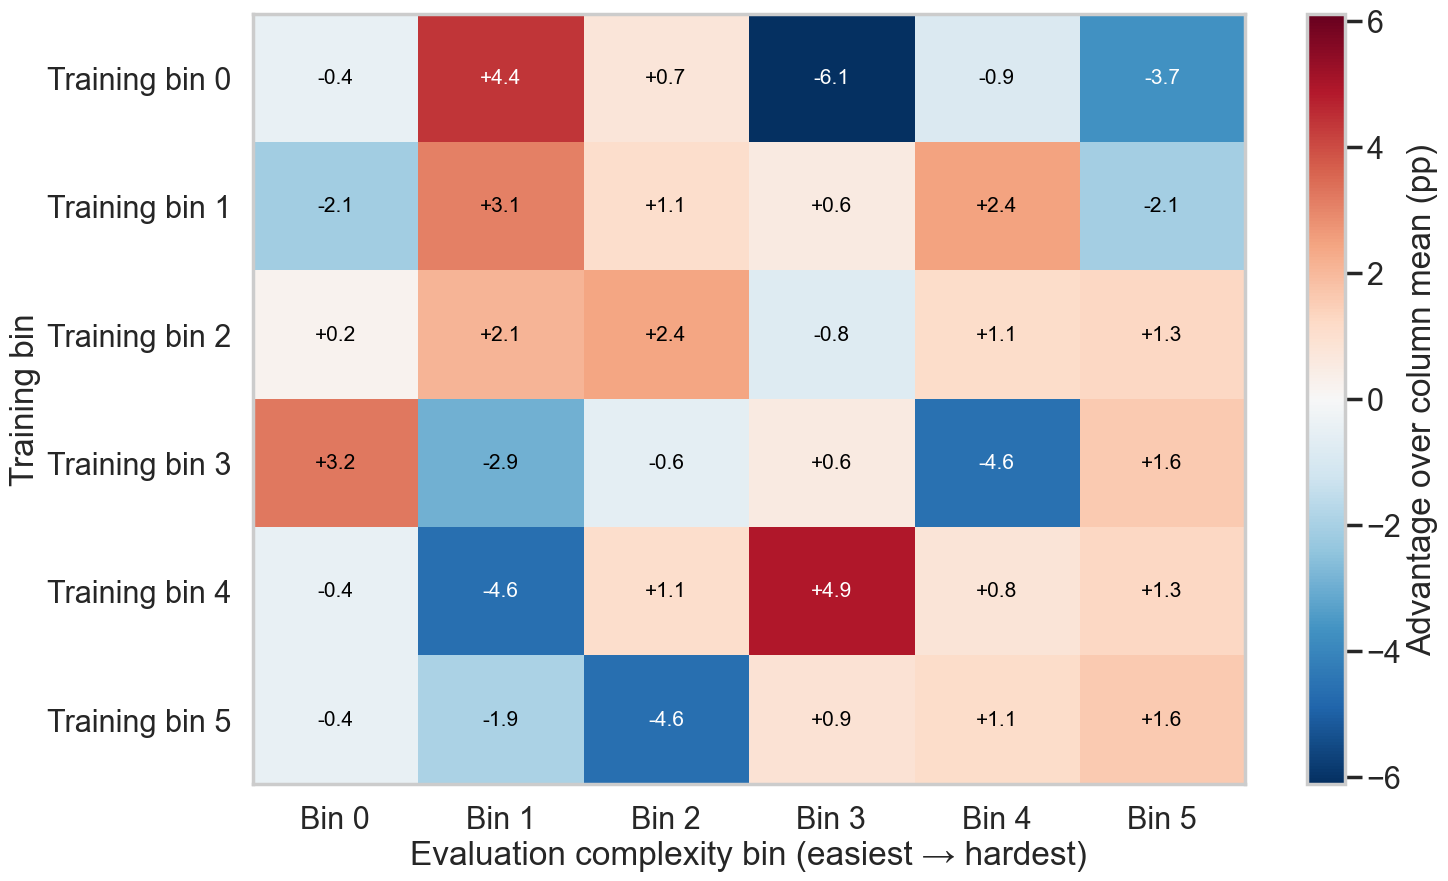

Training,Bin 0 Δ accuracy,Bin 1 Δ accuracy,Bin 2 Δ accuracy,Bin 3 Δ accuracy,Bin 4 Δ accuracy,Bin 5 Δ accuracy
Training bin 0,-0.0044,0.0439,0.0072,-0.0611,-0.0089,-0.0372
Training bin 1,-0.0211,0.0306,0.0106,0.0056,0.0244,-0.0206
Training bin 2,0.0022,0.0206,0.0239,-0.0078,0.0111,0.0128
Training bin 3,0.0322,-0.0294,-0.0061,0.0056,-0.0456,0.0161
Training bin 4,-0.0044,-0.0461,0.0106,0.0489,0.0078,0.0128
Training bin 5,-0.0044,-0.0194,-0.0461,0.0089,0.0111,0.0161


#### Checkpoint provenance

Model,Training,Selected epoch,Selected checkpoint,Training samples seen,Selected balanced600 accuracy
Qwen 3B,Training bin 0,50,checkpoint-1350,"80,200",0.3750
Qwen 3B,Training bin 1,50,checkpoint-1200,"80,200",0.3867
Qwen 3B,Training bin 2,50,checkpoint-1250,"80,200",0.3600
Qwen 3B,Training bin 3,50,checkpoint-1200,"80,200",0.3617
Qwen 3B,Training bin 4,50,checkpoint-1300,"80,200",0.3400
Qwen 3B,Training bin 5,50,checkpoint-1250,"80,200",0.3417
Phi-4 Mini,Training bin 0,50,checkpoint-1250,"80,200",0.2917
Phi-4 Mini,Training bin 1,50,checkpoint-1200,"80,200",0.3367
Phi-4 Mini,Training bin 2,50,checkpoint-1300,"80,200",0.3733
Phi-4 Mini,Training bin 3,50,checkpoint-1300,"80,200",0.3467


**Observed pattern:** Training bin 2 has the highest mean balanced600 accuracy (36.06%); training-arm means range from 34.00% to 36.06%. 5 of six training bins outperform the other five training arms on their own evaluation bin. These descriptive rankings do not establish statistical significance.

### All-model mean (3 models) — Mean cross-bin accuracy — Best balanced600 checkpoints per model/arm — cap 2048

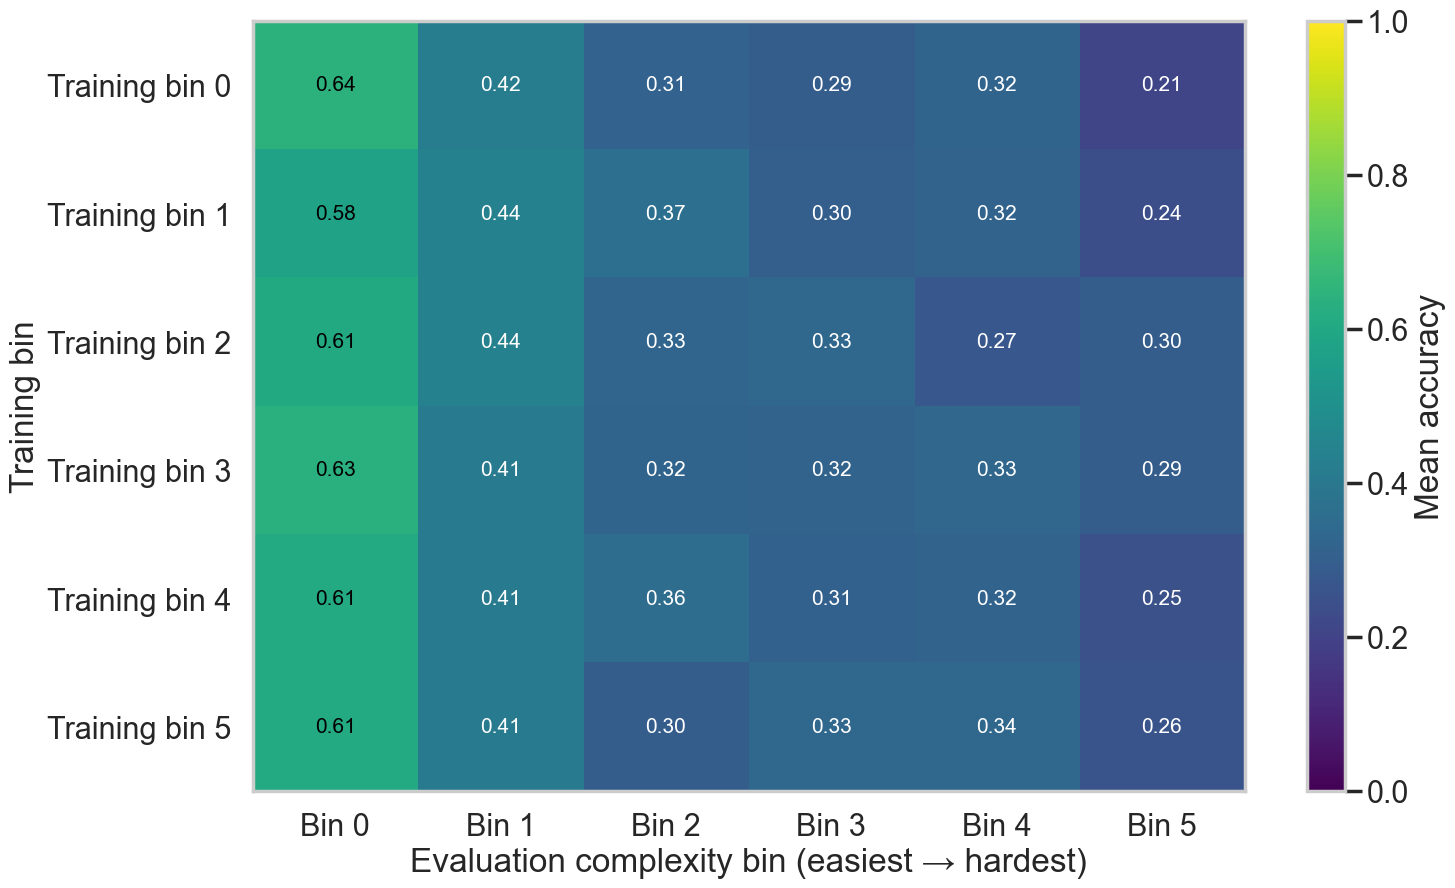

Training,Models,Mean balanced600 accuracy,Own-bin accuracy,Own-bin Δ accuracy vs other arms,95% CI (training seeds)
Training bin 0,3,0.3672,0.6433,0.0360,Unavailable (one training seed per model)
Training bin 1,3,0.3739,0.4400,0.0227,Unavailable (one training seed per model)
Training bin 2,3,0.3789,0.3267,-0.0047,Unavailable (one training seed per model)
Training bin 3,3,0.3850,0.3167,0.0020,Unavailable (one training seed per model)
Training bin 4,3,0.3750,0.3200,0.0047,Unavailable (one training seed per model)
Training bin 5,3,0.3739,0.2600,0.0027,Unavailable (one training seed per model)


### All-model mean (3 models) — Advantage over the training-bin mean — Best balanced600 checkpoints per model/arm — cap 2048

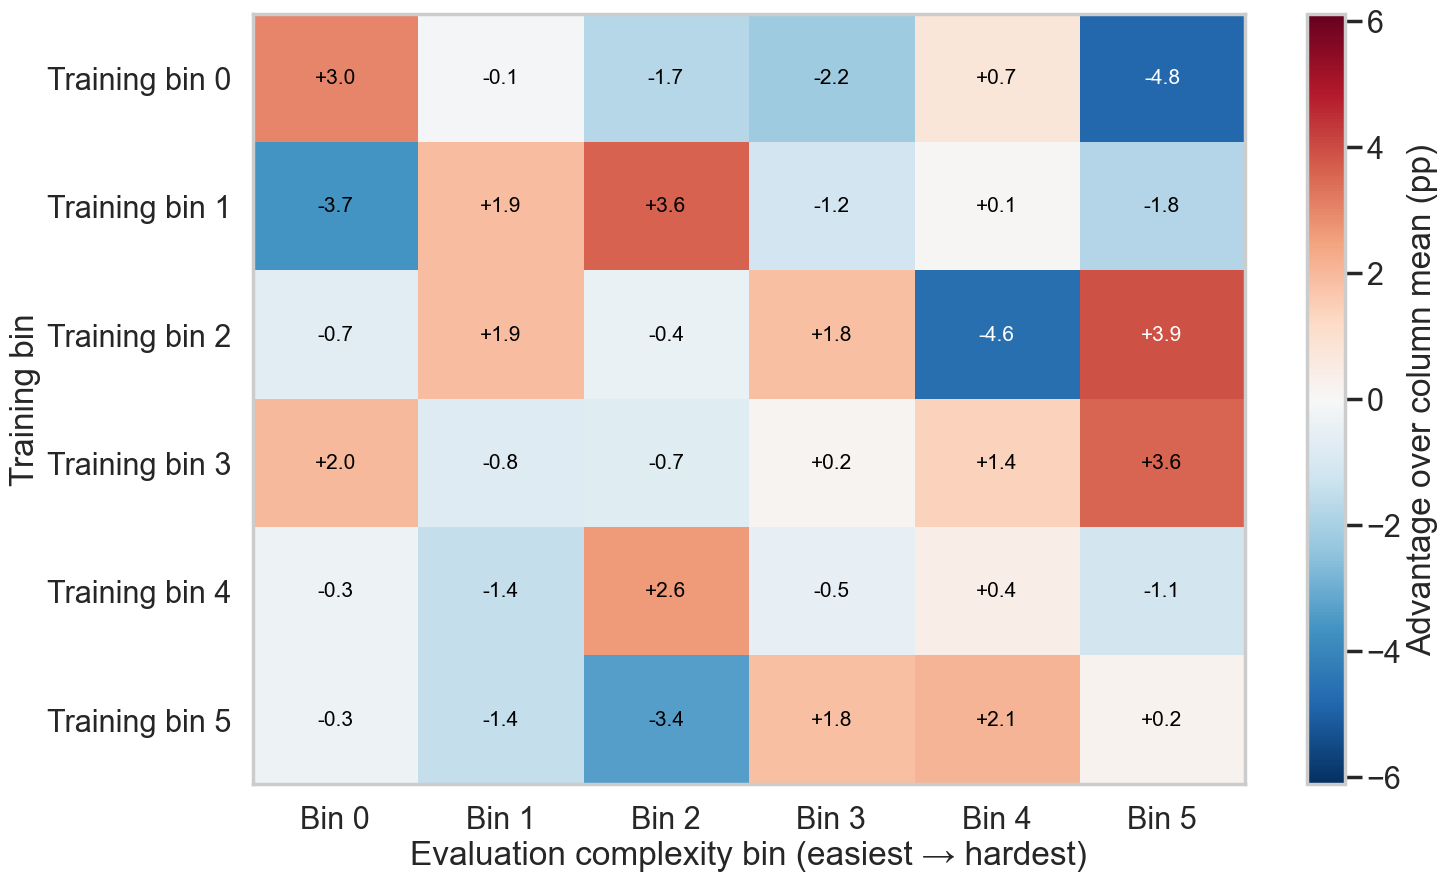

Training,Bin 0 Δ accuracy,Bin 1 Δ accuracy,Bin 2 Δ accuracy,Bin 3 Δ accuracy,Bin 4 Δ accuracy,Bin 5 Δ accuracy
Training bin 0,0.0300,-0.0011,-0.0172,-0.0217,0.0072,-0.0478
Training bin 1,-0.0367,0.0189,0.0361,-0.0117,0.0006,-0.0178
Training bin 2,-0.0067,0.0189,-0.0039,0.0183,-0.0461,0.0389
Training bin 3,0.0200,-0.0078,-0.0072,0.0017,0.0139,0.0356
Training bin 4,-0.0033,-0.0144,0.0261,-0.0050,0.0039,-0.0111
Training bin 5,-0.0033,-0.0144,-0.0339,0.0183,0.0206,0.0022


#### Checkpoint provenance

Model,Training,Selected epoch,Selected checkpoint,Training samples seen,Selected balanced600 accuracy
Qwen 3B,Training bin 0,10,checkpoint-270,"16,040",0.4167
Qwen 3B,Training bin 1,50,checkpoint-1200,"80,200",0.3867
Qwen 3B,Training bin 2,10,checkpoint-250,"16,040",0.3867
Qwen 3B,Training bin 3,10,checkpoint-240,"16,040",0.3783
Qwen 3B,Training bin 4,10,checkpoint-260,"16,040",0.3917
Qwen 3B,Training bin 5,10,checkpoint-250,"16,040",0.3800
Phi-4 Mini,Training bin 0,20,checkpoint-500,"32,080",0.3317
Phi-4 Mini,Training bin 1,35,checkpoint-840,"56,140",0.3533
Phi-4 Mini,Training bin 2,35,checkpoint-910,"56,140",0.3900
Phi-4 Mini,Training bin 3,35,checkpoint-910,"56,140",0.3850


**Observed pattern:** Training bin 3 has the highest mean balanced600 accuracy (38.50%); training-arm means range from 36.72% to 38.50%. 5 of six training bins outperform the other five training arms on their own evaluation bin. These descriptive rankings do not establish statistical significance.

In [17]:
aggregate_transfer_tables = {}
aggregate_transfer_checkpoints = {}
all_model_transfer = {}
common_transfer_caps = sorted(set.intersection(*(
    set(balanced.loc[balanced.model.eq(model), "cap"]) for model in MODELS
)))

for cap in common_transfer_caps:
    for selection in ("final", "best_balanced600"):
        model_matrices, checkpoints = [], []
        for model, (nick, label) in MODELS.items():
            model_matrix = transfer_tables[f"{nick}_transfer_{selection}_cap{cap}"].loc[ARMS, range(6)]
            if model_matrix.shape != (6, 6) or model_matrix.isna().any().any():
                raise ValueError(f"Incomplete transfer matrix for {model}, cap {cap}")
            model_matrices.append(model_matrix.to_numpy())
            for arm in ARMS:
                curve = balanced.loc[
                    balanced.model.eq(model) & balanced.arm.eq(arm) & balanced.cap.eq(cap)
                ].sort_values("epoch")
                chosen = curve.iloc[-1] if selection == "final" else best_checkpoint(curve)
                checkpoints.append({
                    "Model": label, "Training": arm_label(arm),
                    "Selected epoch": chosen.epoch, "Selected checkpoint": chosen.checkpoint,
                    "Training samples seen": chosen.samples_seen,
                    "Selected balanced600 accuracy": chosen.accuracy,
                })
        matrix = np.mean(np.stack(model_matrices), axis=0)
        all_model_transfer[(cap, selection)] = matrix
        aggregate_transfer_checkpoints[(cap, selection)] = pd.DataFrame(checkpoints)

# Use one symmetric percentage-point scale for both checkpoint selections.
advantage_limit_pp = max(
    0.1, max(float(np.abs(matrix - matrix.mean(axis=0)).max()) * 100
             for matrix in all_model_transfer.values())
) if all_model_transfer else 0.1

for (cap, selection), matrix in all_model_transfer.items():
    selection_label = "Final checkpoints" if selection == "final" else "Best balanced600 checkpoints per model/arm"
    advantages = matrix - matrix.mean(axis=0)
    name = f"all_models_transfer_{selection}_cap{cap}"
    aggregate_transfer_tables[name] = pd.DataFrame(matrix, index=ARMS, columns=range(6))

    for relative in (False, True):
        values = advantages * 100 if relative else matrix
        plot_name = f"{name}_advantage" if relative else name
        fig, ax = plt.subplots(figsize=(16, 10))
        image = ax.imshow(
            values, aspect="auto", cmap="RdBu_r" if relative else "viridis",
            vmin=-advantage_limit_pp if relative else 0,
            vmax=advantage_limit_pp if relative else 1,
        )
        ax.grid(False)
        ax.set_xticks(range(6), [f"Bin {g}" for g in range(6)])
        ax.set_yticks(range(6), [arm_label(arm) for arm in ARMS])
        ax.set_xlabel("Evaluation complexity bin (easiest → hardest)")
        ax.set_ylabel("Training bin")
        for i in range(6):
            for j in range(6):
                value = values[i, j]
                text_color = ("white" if abs(value) > advantage_limit_pp * 0.6 else "black") if relative else (
                    "black" if value > 0.55 else "white"
                )
                ax.text(j, i, f"{value:+.1f}" if relative else f"{value:.2f}",
                        ha="center", va="center", fontsize=15, color=text_color)
        fig.colorbar(image, ax=ax, label="Advantage over column mean (pp)" if relative else "Mean accuracy")
        measure = "Advantage over the training-bin mean" if relative else "Mean cross-bin accuracy"
        finish_plot(fig, ax, f"All-model mean (3 models) — {measure} — {selection_label} — cap {cap}", plot_name)
        if relative:
            table = pd.DataFrame(advantages, columns=[f"Bin {g} Δ accuracy" for g in range(6)])
            table.insert(0, "Training", [arm_label(arm) for arm in ARMS])
        else:
            diagonal = np.diag(matrix)
            other_arms = (matrix.sum(axis=0) - diagonal) / (len(ARMS) - 1)
            table = pd.DataFrame({
                "Training": [arm_label(arm) for arm in ARMS],
                "Models": len(MODELS), "Mean balanced600 accuracy": matrix.mean(axis=1),
                "Own-bin accuracy": diagonal,
                "Own-bin Δ accuracy vs other arms": diagonal - other_arms,
                "95% CI (training seeds)": CI_NOTE,
            })
        show_table(table, plot_name)

    display(Markdown("#### Checkpoint provenance"))
    checkpoint_table = aggregate_transfer_checkpoints[(cap, selection)]
    display(checkpoint_table.style.format({
        "Selected epoch": "{:.0f}", "Training samples seen": "{:,.0f}",
        "Selected balanced600 accuracy": "{:.4f}",
    }).hide(axis="index"))
    overall = matrix.mean(axis=1)
    strongest = int(np.argmax(overall))
    own_advantage = np.diag(matrix) - (matrix.sum(axis=0) - np.diag(matrix)) / 5
    display(Markdown(
        f"**Observed pattern:** Training bin {strongest} has the highest mean balanced600 "
        f"accuracy ({overall[strongest]:.2%}); training-arm means range from "
        f"{overall.min():.2%} to {overall.max():.2%}. "
        f"{int((own_advantage > 0).sum())} of six training bins outperform the other five "
        "training arms on their own evaluation bin. These descriptive rankings do not "
        "establish statistical significance."
    ))


## In-bin accuracy by token cap

Each student is tested on its own full held-out complexity bin (401 questions).
Training-bin curves therefore refer to different test sets and should not be
interpreted as a ranking on a common test. Qwen and Phi have separate figures
for caps 2048 and 4096; Llama has no current in-bin JSON summaries.


### Phi-4 Mini — MMLU — in-bin accuracy — cap 2048

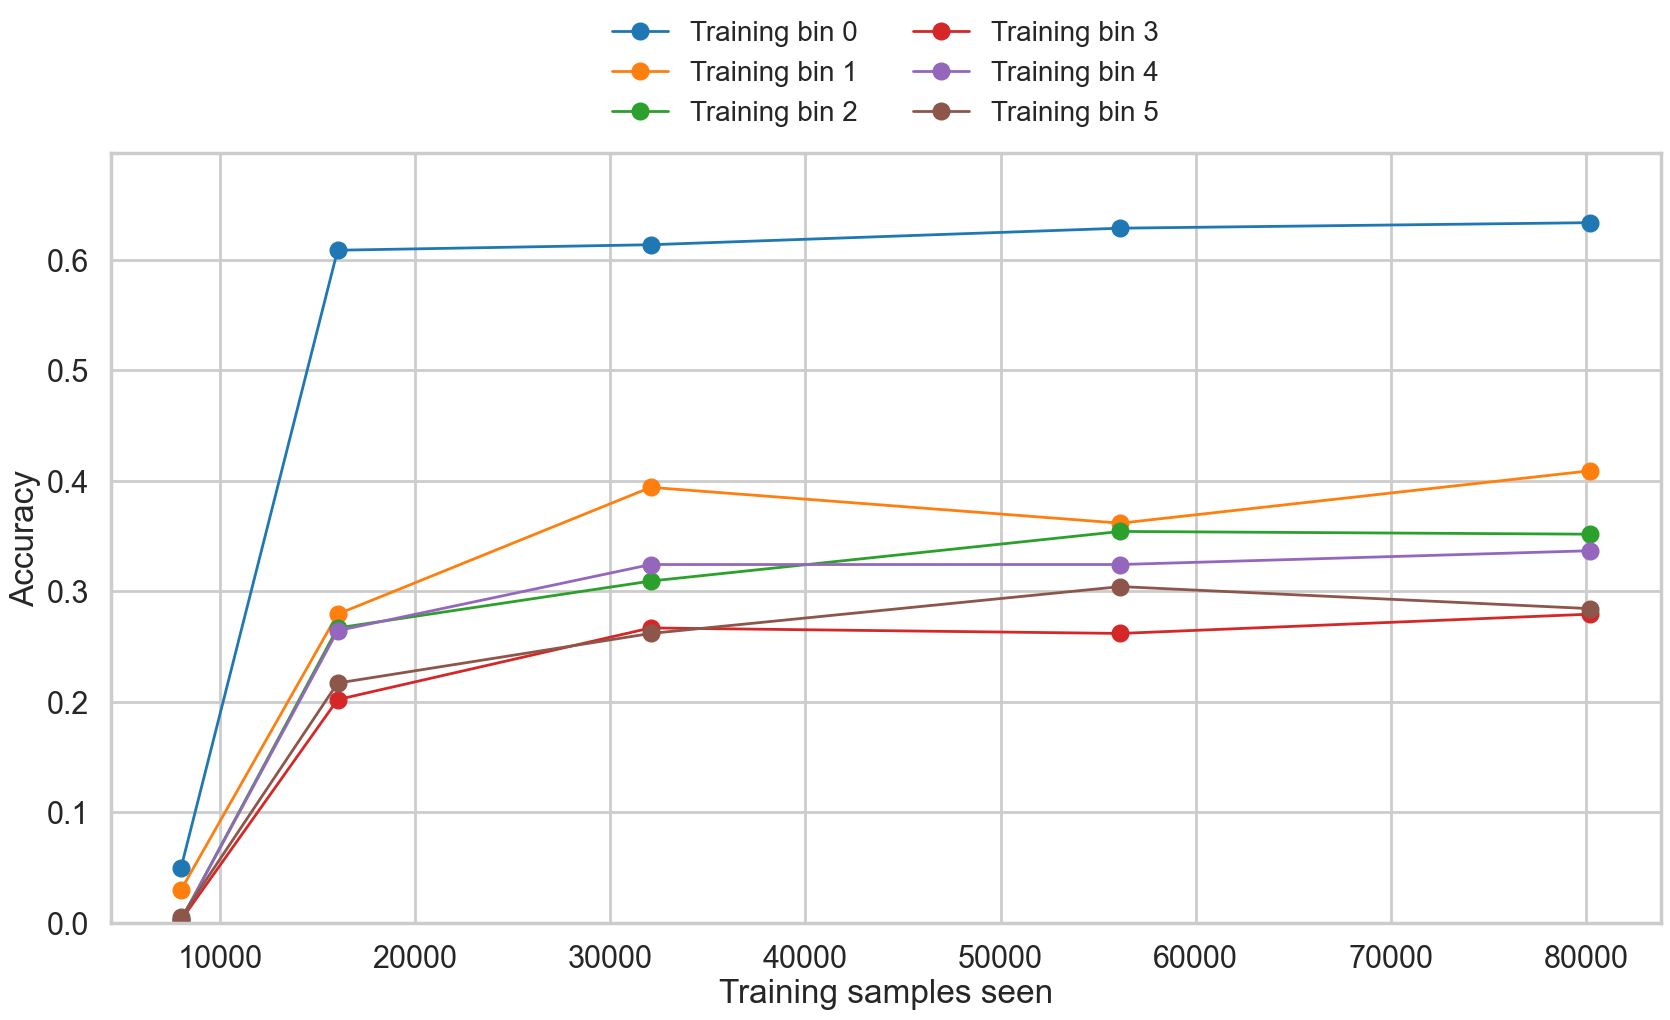

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions
Training bin 0,"1,604",50,"80,200",0.6334,0.6334,50,Unavailable (one training seed per model),401
Training bin 1,"1,604",50,"80,200",0.4090,0.4090,50,Unavailable (one training seed per model),401
Training bin 2,"1,604",50,"80,200",0.3516,0.3541,35,Unavailable (one training seed per model),401
Training bin 3,"1,604",50,"80,200",0.2793,0.2793,50,Unavailable (one training seed per model),401
Training bin 4,"1,604",50,"80,200",0.3367,0.3367,50,Unavailable (one training seed per model),401
Training bin 5,"1,604",50,"80,200",0.2843,0.3042,35,Unavailable (one training seed per model),401


### Phi-4 Mini — MMLU — in-bin accuracy — cap 4096

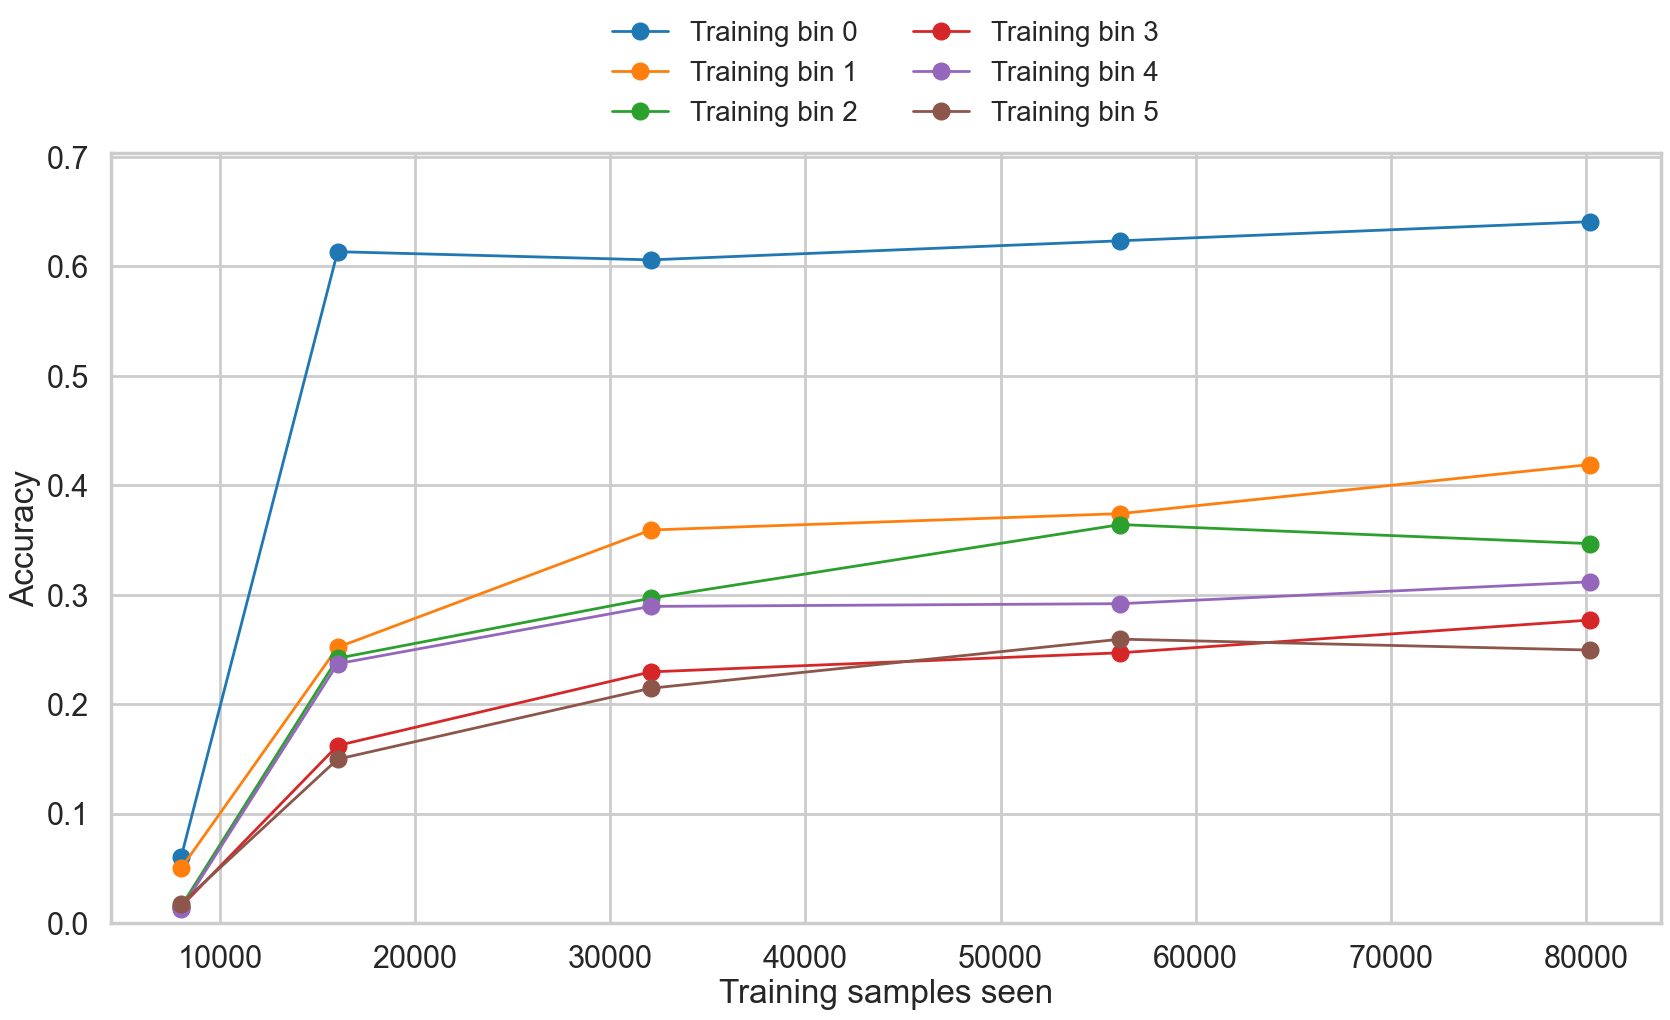

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions
Training bin 0,"1,604",50,"80,200",0.6409,0.6409,50,Unavailable (one training seed per model),401
Training bin 1,"1,604",50,"80,200",0.4190,0.4190,50,Unavailable (one training seed per model),401
Training bin 2,"1,604",50,"80,200",0.3466,0.3641,35,Unavailable (one training seed per model),401
Training bin 3,"1,604",50,"80,200",0.2768,0.2768,50,Unavailable (one training seed per model),401
Training bin 4,"1,604",50,"80,200",0.3117,0.3117,50,Unavailable (one training seed per model),401
Training bin 5,"1,604",50,"80,200",0.2494,0.2594,35,Unavailable (one training seed per model),401


### Qwen 3B — MMLU — in-bin accuracy — cap 2048

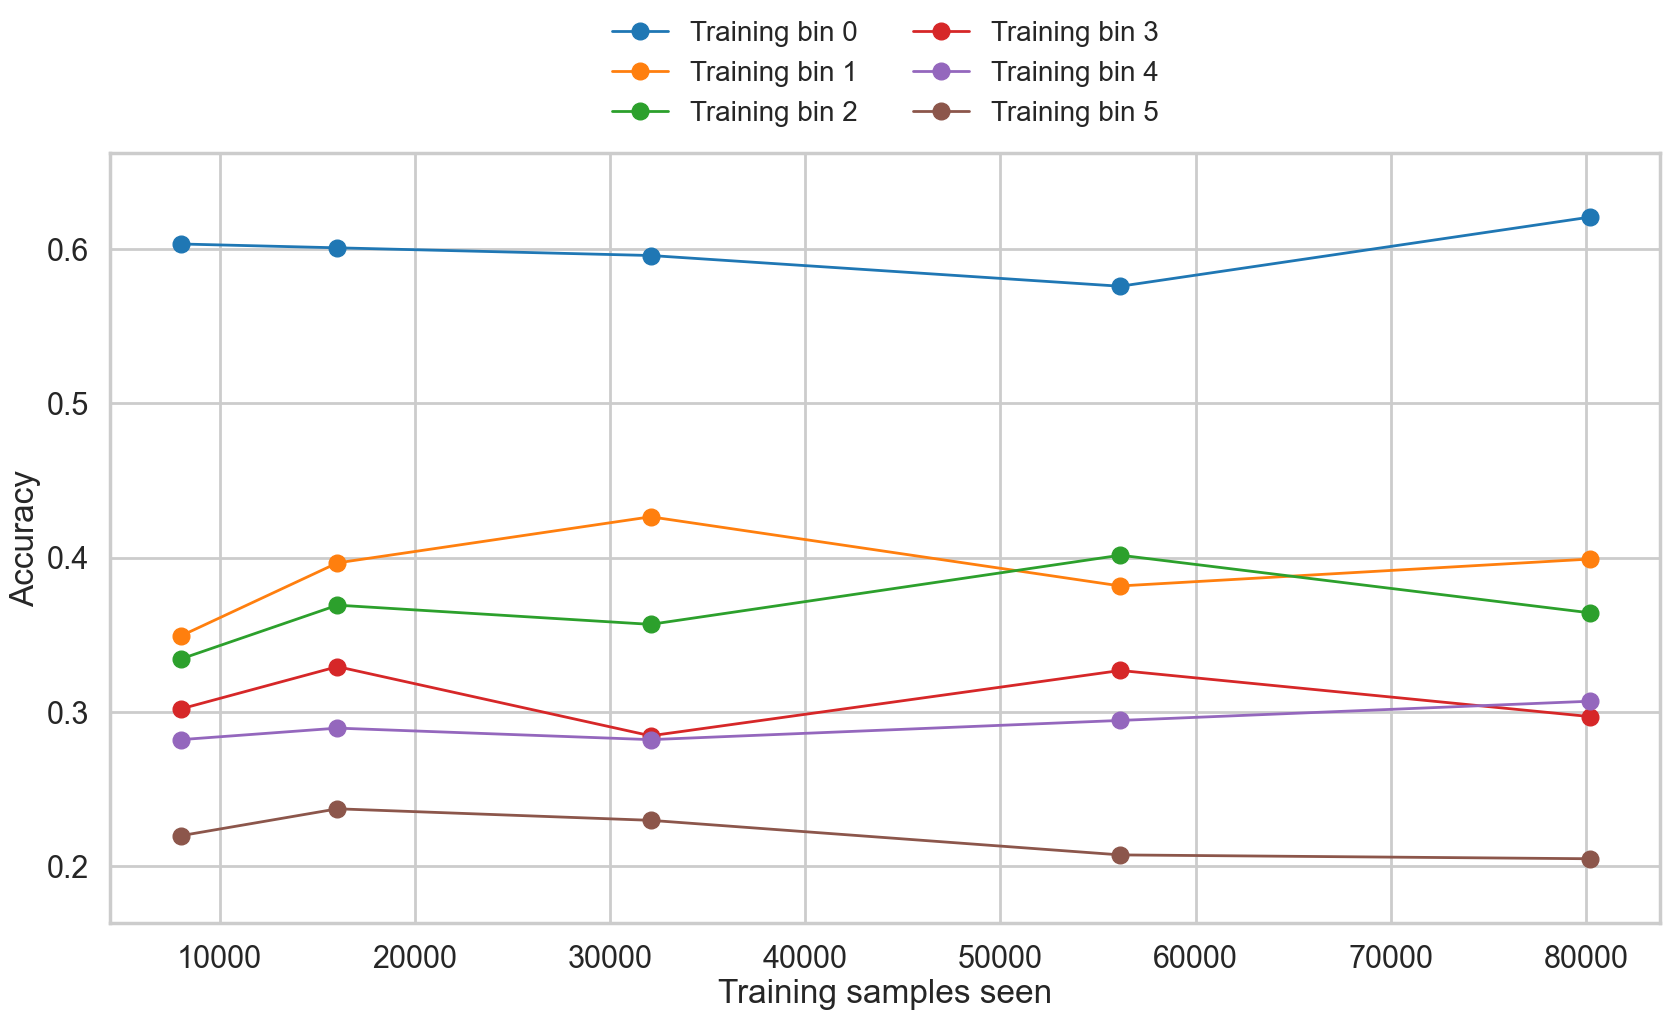

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions
Training bin 0,"1,604",50,"80,200",0.6209,0.6209,50,Unavailable (one training seed per model),401
Training bin 1,"1,604",50,"80,200",0.3990,0.4264,20,Unavailable (one training seed per model),401
Training bin 2,"1,604",50,"80,200",0.3641,0.4015,35,Unavailable (one training seed per model),401
Training bin 3,"1,604",50,"80,200",0.2968,0.3292,10,Unavailable (one training seed per model),401
Training bin 4,"1,604",50,"80,200",0.3067,0.3067,50,Unavailable (one training seed per model),401
Training bin 5,"1,604",50,"80,200",0.2045,0.2369,10,Unavailable (one training seed per model),401


### Qwen 3B — MMLU — in-bin accuracy — cap 4096

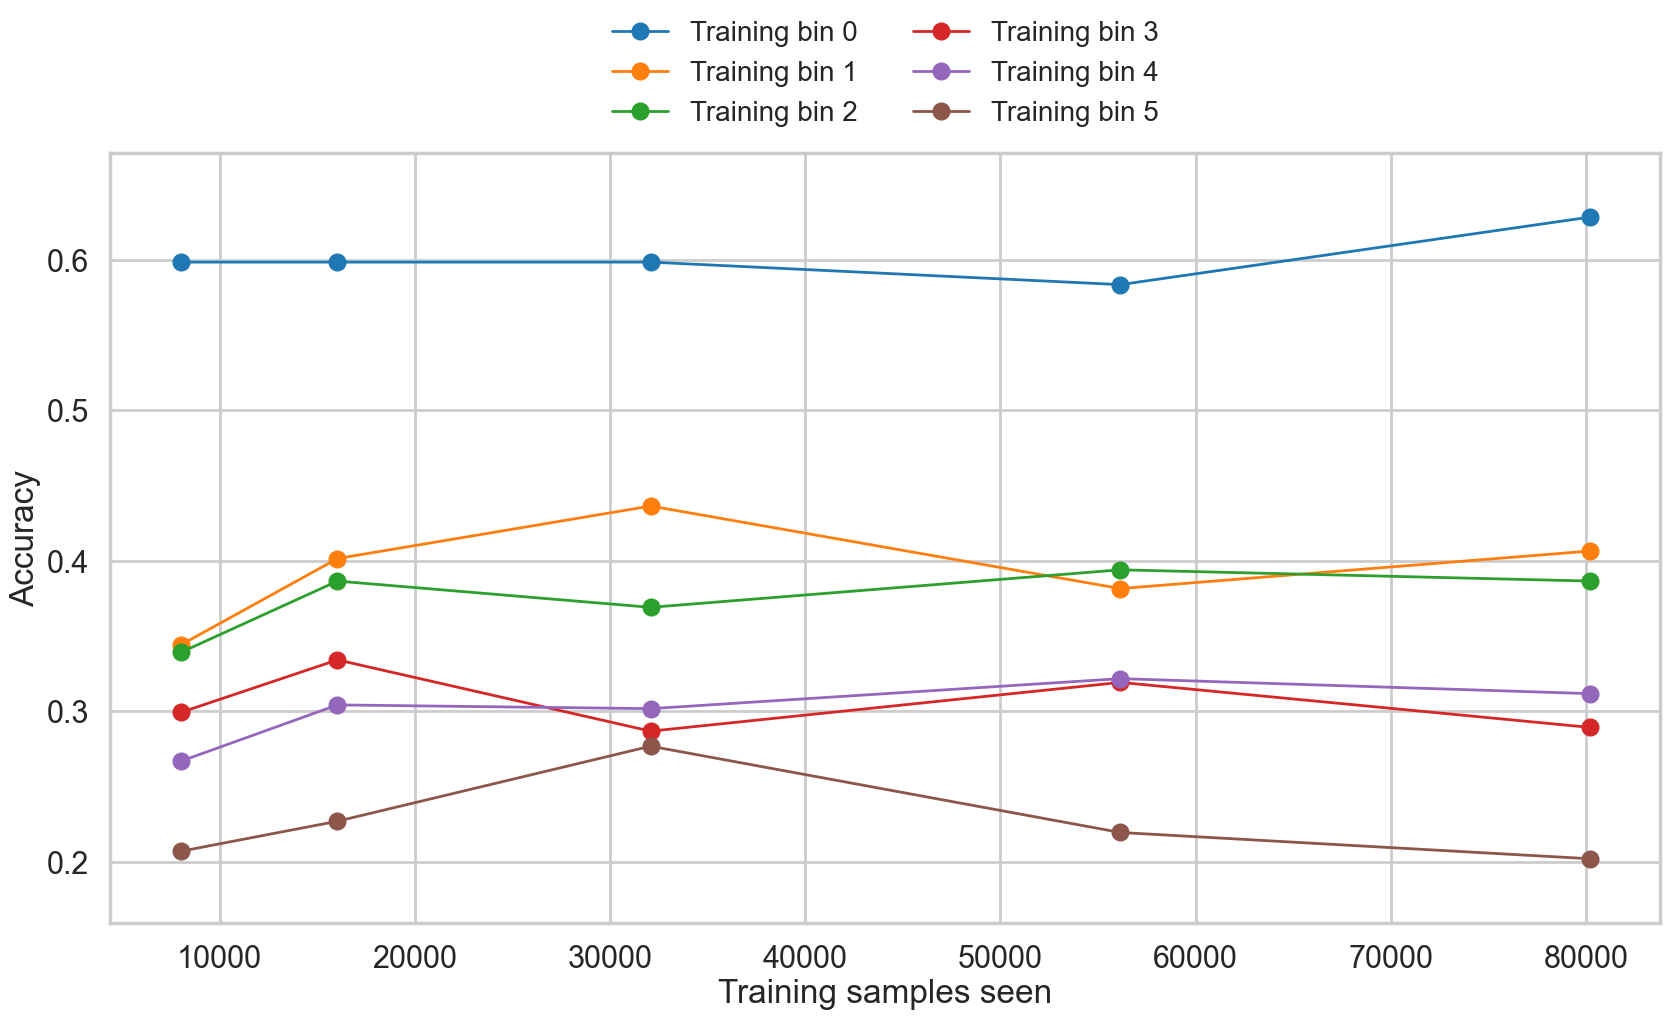

Training,Rows / epoch,Final epoch,Training samples seen,Final accuracy,Best accuracy,Best epoch,95% CI (training seeds),Test questions
Training bin 0,"1,604",50,"80,200",0.6284,0.6284,50,Unavailable (one training seed per model),401
Training bin 1,"1,604",50,"80,200",0.4065,0.4364,20,Unavailable (one training seed per model),401
Training bin 2,"1,604",50,"80,200",0.3865,0.3940,35,Unavailable (one training seed per model),401
Training bin 3,"1,604",50,"80,200",0.2893,0.3342,10,Unavailable (one training seed per model),401
Training bin 4,"1,604",50,"80,200",0.3117,0.3217,35,Unavailable (one training seed per model),401
Training bin 5,"1,604",50,"80,200",0.2020,0.2768,20,Unavailable (one training seed per model),401


In [18]:
in_bin = raw_results.loc[raw_results.evaluation.eq("in_bin")]
for (model, cap), frame in in_bin.groupby(["model", "cap"]):
    nick, label = MODELS[model]
    learning_plot(frame, f"{label} — MMLU — in-bin accuracy — cap {cap}",
                  f"{nick}_in_bin_accuracy_cap{cap}")


## Effect of the generation cap at matched checkpoints

These curves show **accuracy at cap 4096 minus accuracy at cap 2048** on the
same in-bin test and checkpoint. Positive values favour the larger cap.
Only observed checkpoints present at both caps are included. Tables report
the final difference, largest observed difference, and its earliest epoch.


### Phi-4 Mini — in-bin generation-cap comparison

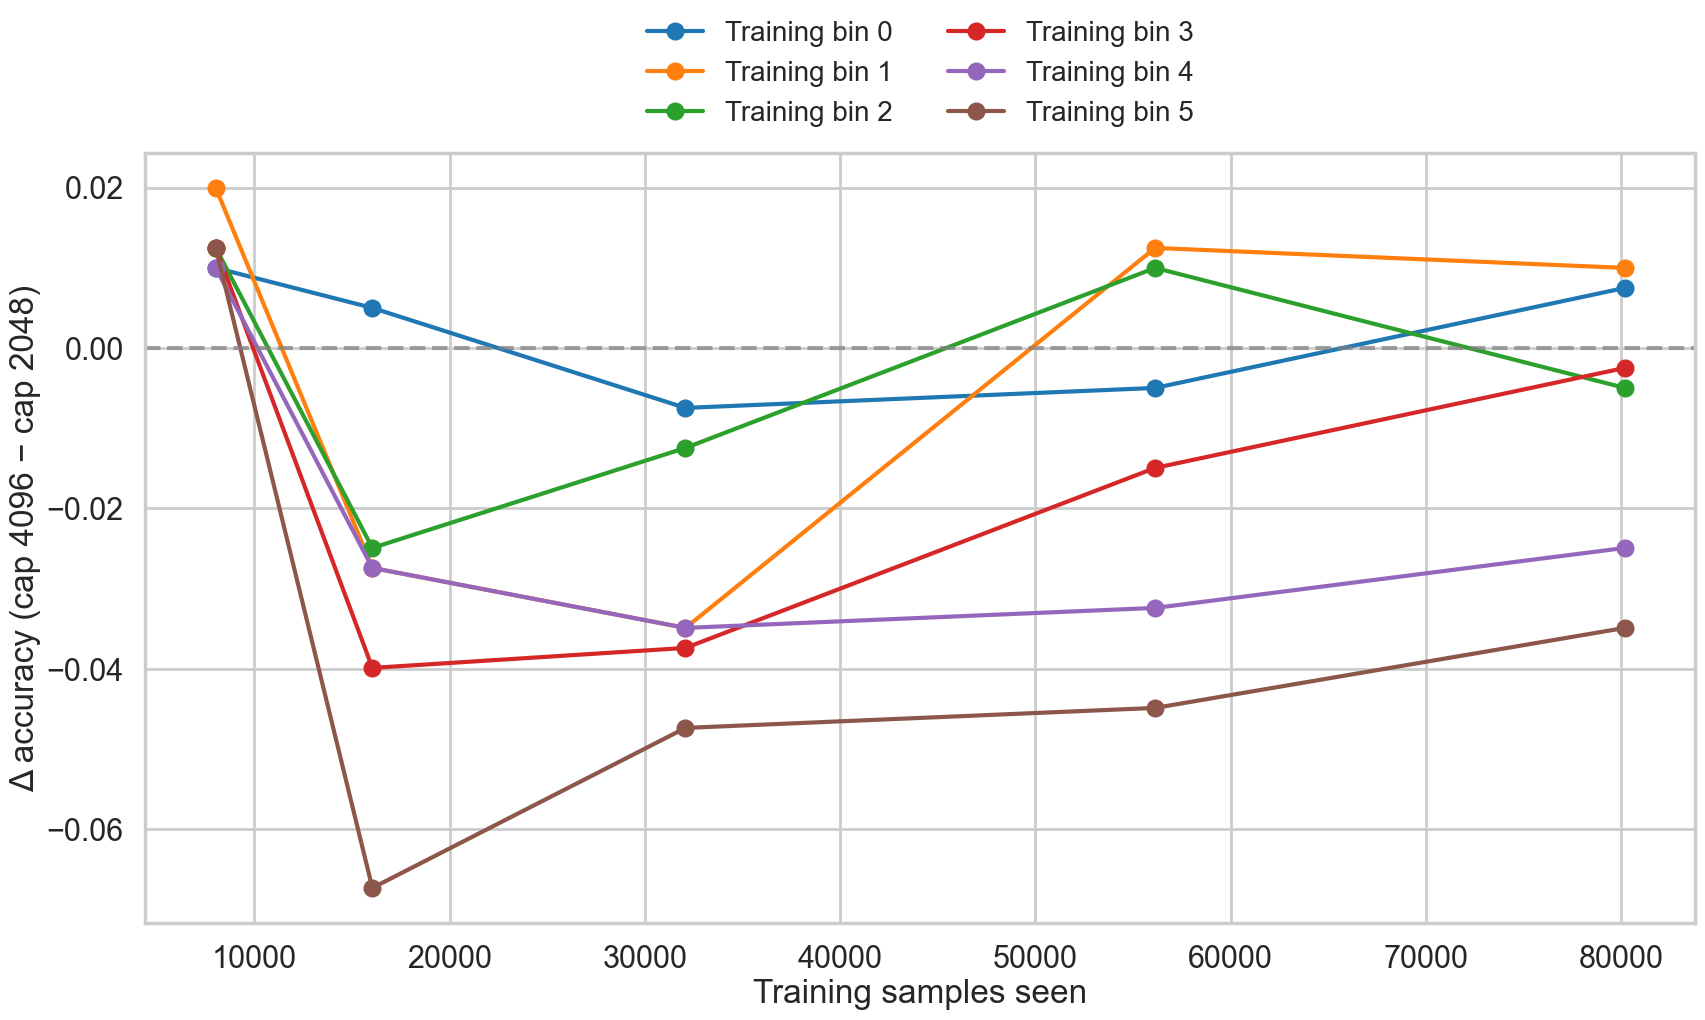

Training,Rows / epoch,Final epoch,Training samples seen,Final Δ accuracy,Maximum Δ accuracy,Best epoch,95% CI (training seeds)
Training bin 0,"1,604",50,"80,200",0.0075,0.0100,5,Unavailable (one training seed per model)
Training bin 1,"1,604",50,"80,200",0.0100,0.0200,5,Unavailable (one training seed per model)
Training bin 2,"1,604",50,"80,200",-0.0050,0.0125,5,Unavailable (one training seed per model)
Training bin 3,"1,604",50,"80,200",-0.0025,0.0125,5,Unavailable (one training seed per model)
Training bin 4,"1,604",50,"80,200",-0.0249,0.0100,5,Unavailable (one training seed per model)
Training bin 5,"1,604",50,"80,200",-0.0349,0.0125,5,Unavailable (one training seed per model)


### Qwen 3B — in-bin generation-cap comparison

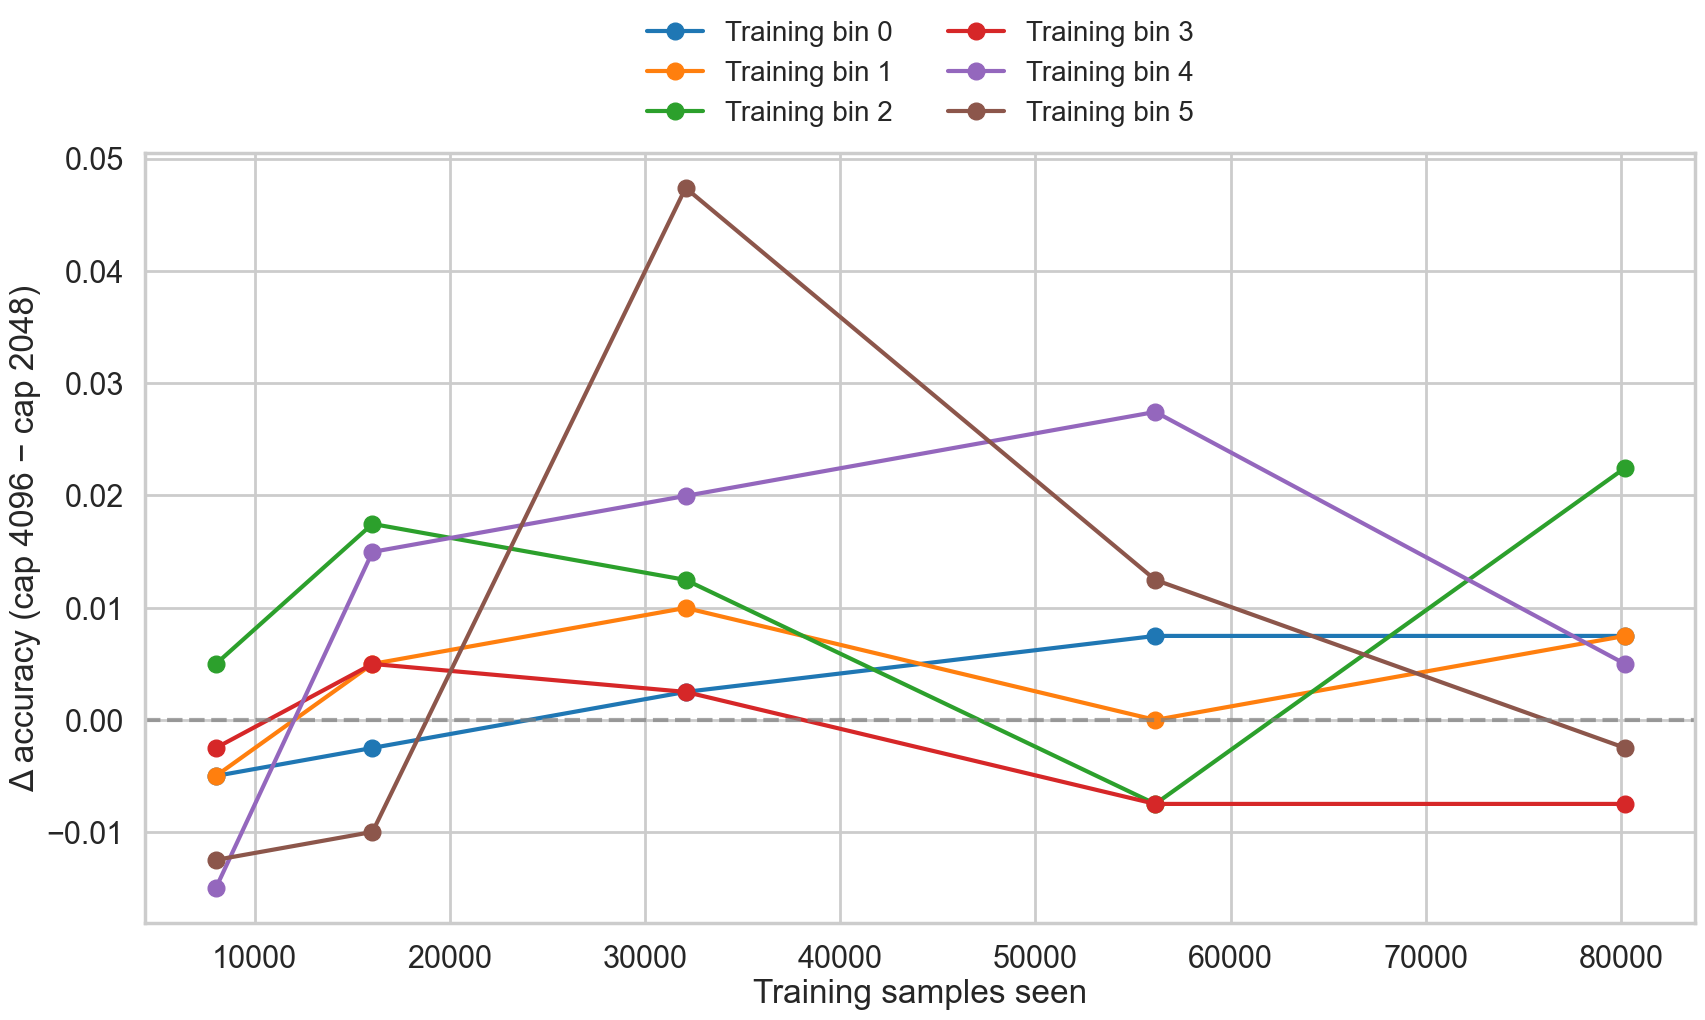

Training,Rows / epoch,Final epoch,Training samples seen,Final Δ accuracy,Maximum Δ accuracy,Best epoch,95% CI (training seeds)
Training bin 0,"1,604",50,"80,200",0.0075,0.0075,50,Unavailable (one training seed per model)
Training bin 1,"1,604",50,"80,200",0.0075,0.0100,20,Unavailable (one training seed per model)
Training bin 2,"1,604",50,"80,200",0.0224,0.0224,50,Unavailable (one training seed per model)
Training bin 3,"1,604",50,"80,200",-0.0075,0.0050,10,Unavailable (one training seed per model)
Training bin 4,"1,604",50,"80,200",0.0050,0.0274,35,Unavailable (one training seed per model)
Training bin 5,"1,604",50,"80,200",-0.0025,0.0474,20,Unavailable (one training seed per model)


In [19]:
cap_pairs = in_bin.loc[in_bin.cap.eq(2048)].merge(
    in_bin.loc[in_bin.cap.eq(4096)],
    on=["model", "arm", "seed", "epoch", "checkpoint", "eval_bin", "samples_seen", "train_rows"],
    suffixes=("_2048", "_4096"), validate="one_to_one",
)
assert cap_pairs.total_2048.eq(cap_pairs.total_4096).all()
cap_pairs["delta"] = cap_pairs.accuracy_4096 - cap_pairs.accuracy_2048
for model, frame in cap_pairs.groupby("model"):
    nick, label = MODELS[model]
    fig, ax = plt.subplots(figsize=(20, 10))
    rows = []
    for arm, curve in frame.groupby("arm"):
        curve = curve.sort_values("epoch")
        ax.plot(curve.samples_seen, curve.delta, color=ARM_COLORS[arm], marker="o", label=arm_label(arm))
        final = curve.iloc[-1]
        best = curve.sort_values(["delta", "epoch"], ascending=[False, True]).iloc[0]
        rows.append({"Training": arm_label(arm), "Rows / epoch": final.train_rows,
                     "Final epoch": final.epoch, "Training samples seen": final.samples_seen,
                     "Final Δ accuracy": final.delta, "Maximum Δ accuracy": best.delta,
                     "Best epoch": best.epoch, "95% CI (training seeds)": CI_NOTE})
    ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax.set_xlabel("Training samples seen")
    ax.set_ylabel("Δ accuracy (cap 4096 − cap 2048)")
    name = f"{nick}_in_bin_cap4096_minus_cap2048"
    finish_plot(fig, ax, f"{label} — in-bin generation-cap comparison", name)
    show_table(pd.DataFrame(rows), name)


## Truncation rates

Truncation rate is `num_truncated / total`, using the evaluator's recorded counts.
Common random600 and balanced600 figures cover all models and available random
baselines. Balanced600 sums truncated counts over the same six probes used for
accuracy. In-bin figures cover Qwen and Phi, separately at each cap. Increasing
the token cap does not necessarily reduce the recorded truncation rate.


### Qwen 3B — Balanced600 — truncation — cap 2048

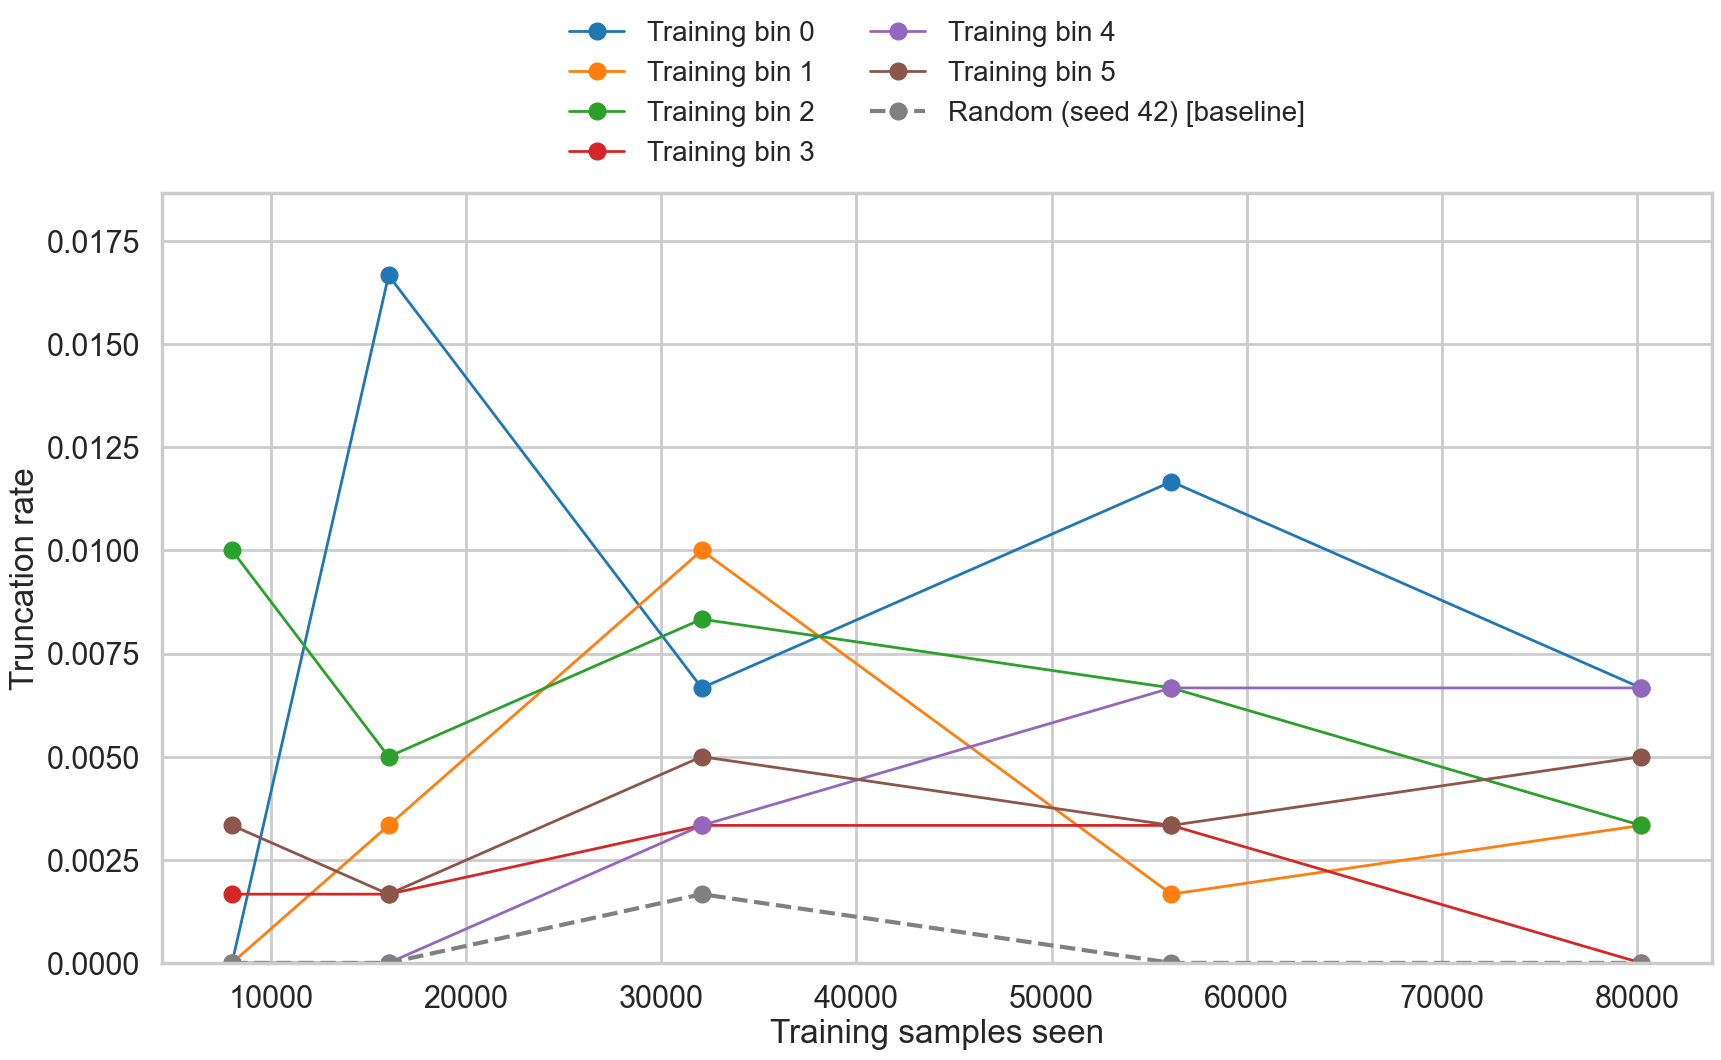

Training,Rows / epoch,Final epoch,Training samples seen,Final truncation rate,Test questions
Training bin 0,"1,604",50,"80,200",0.0067,600
Training bin 1,"1,604",50,"80,200",0.0033,600
Training bin 2,"1,604",50,"80,200",0.0033,600
Training bin 3,"1,604",50,"80,200",0.0000,600
Training bin 4,"1,604",50,"80,200",0.0067,600
Training bin 5,"1,604",50,"80,200",0.0050,600
Random (seed 42) [baseline],"1,604",50,"80,200",0.0000,600


### Qwen 3B — Random600 — truncation — cap 2048

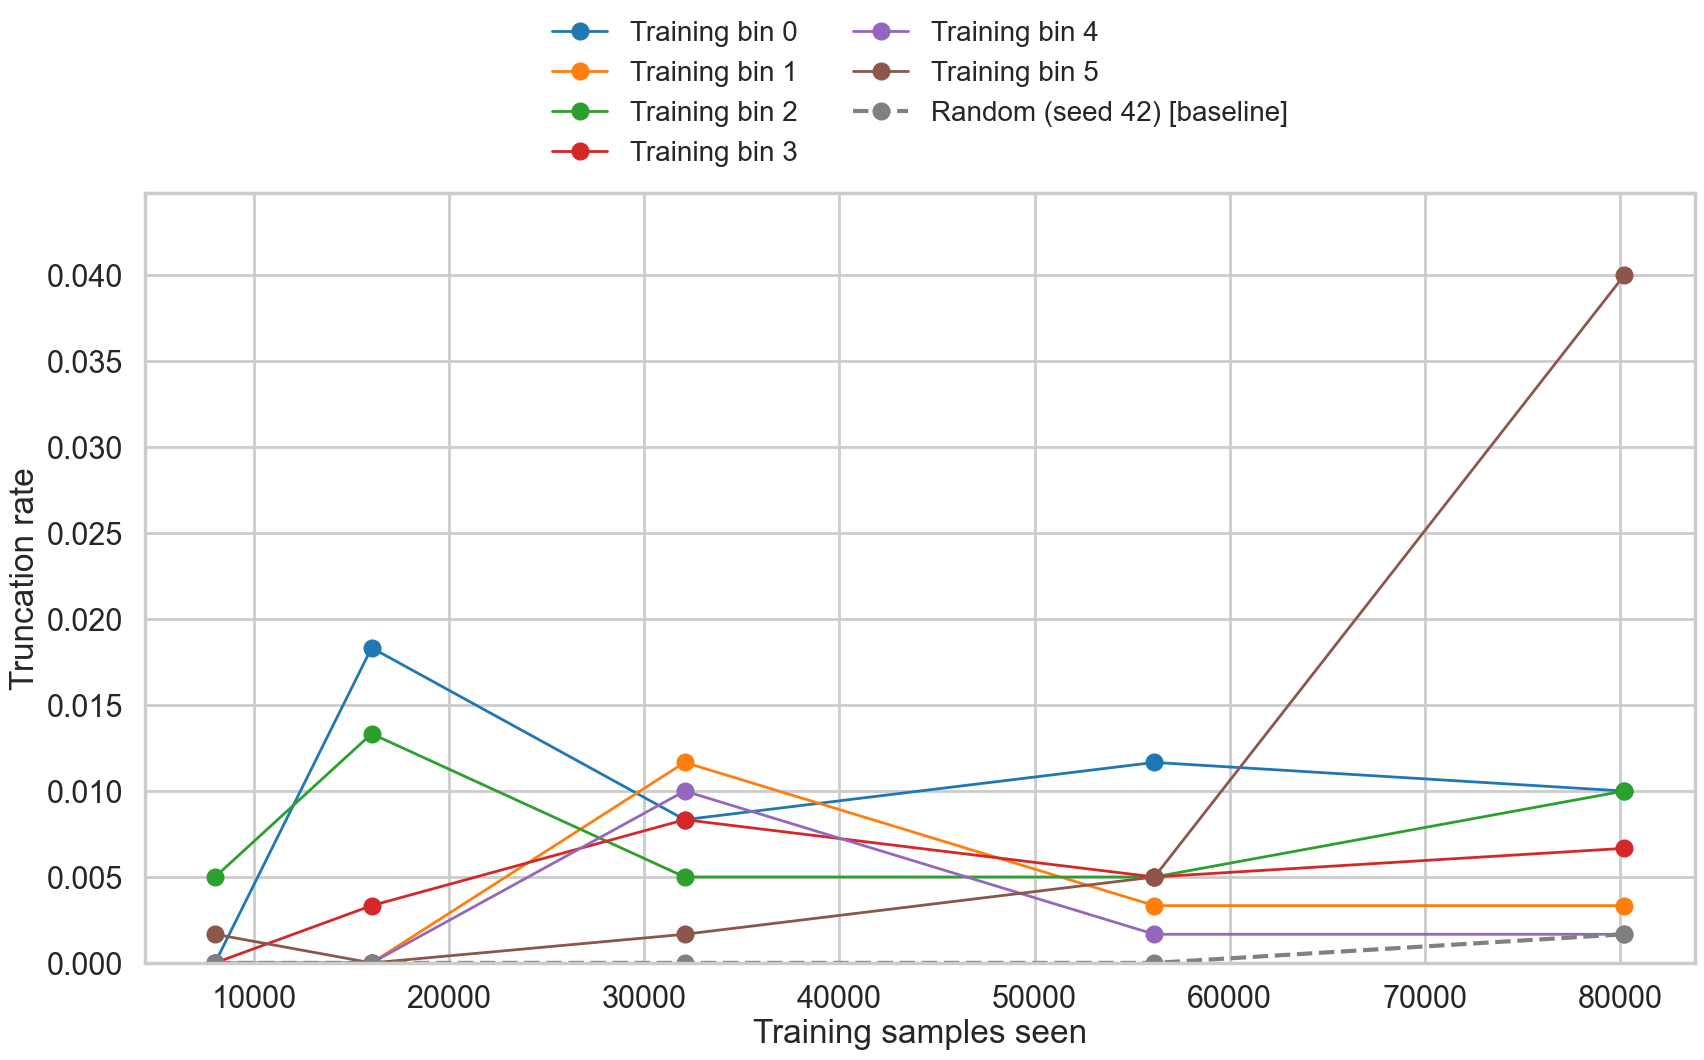

Training,Rows / epoch,Final epoch,Training samples seen,Final truncation rate,Test questions
Training bin 0,"1,604",50,"80,200",0.0100,600
Training bin 1,"1,604",50,"80,200",0.0033,600
Training bin 2,"1,604",50,"80,200",0.0100,600
Training bin 3,"1,604",50,"80,200",0.0067,600
Training bin 4,"1,604",50,"80,200",0.0017,600
Training bin 5,"1,604",50,"80,200",0.0400,600
Random (seed 42) [baseline],"1,604",50,"80,200",0.0017,600


### Phi-4 Mini — Balanced600 — truncation — cap 2048

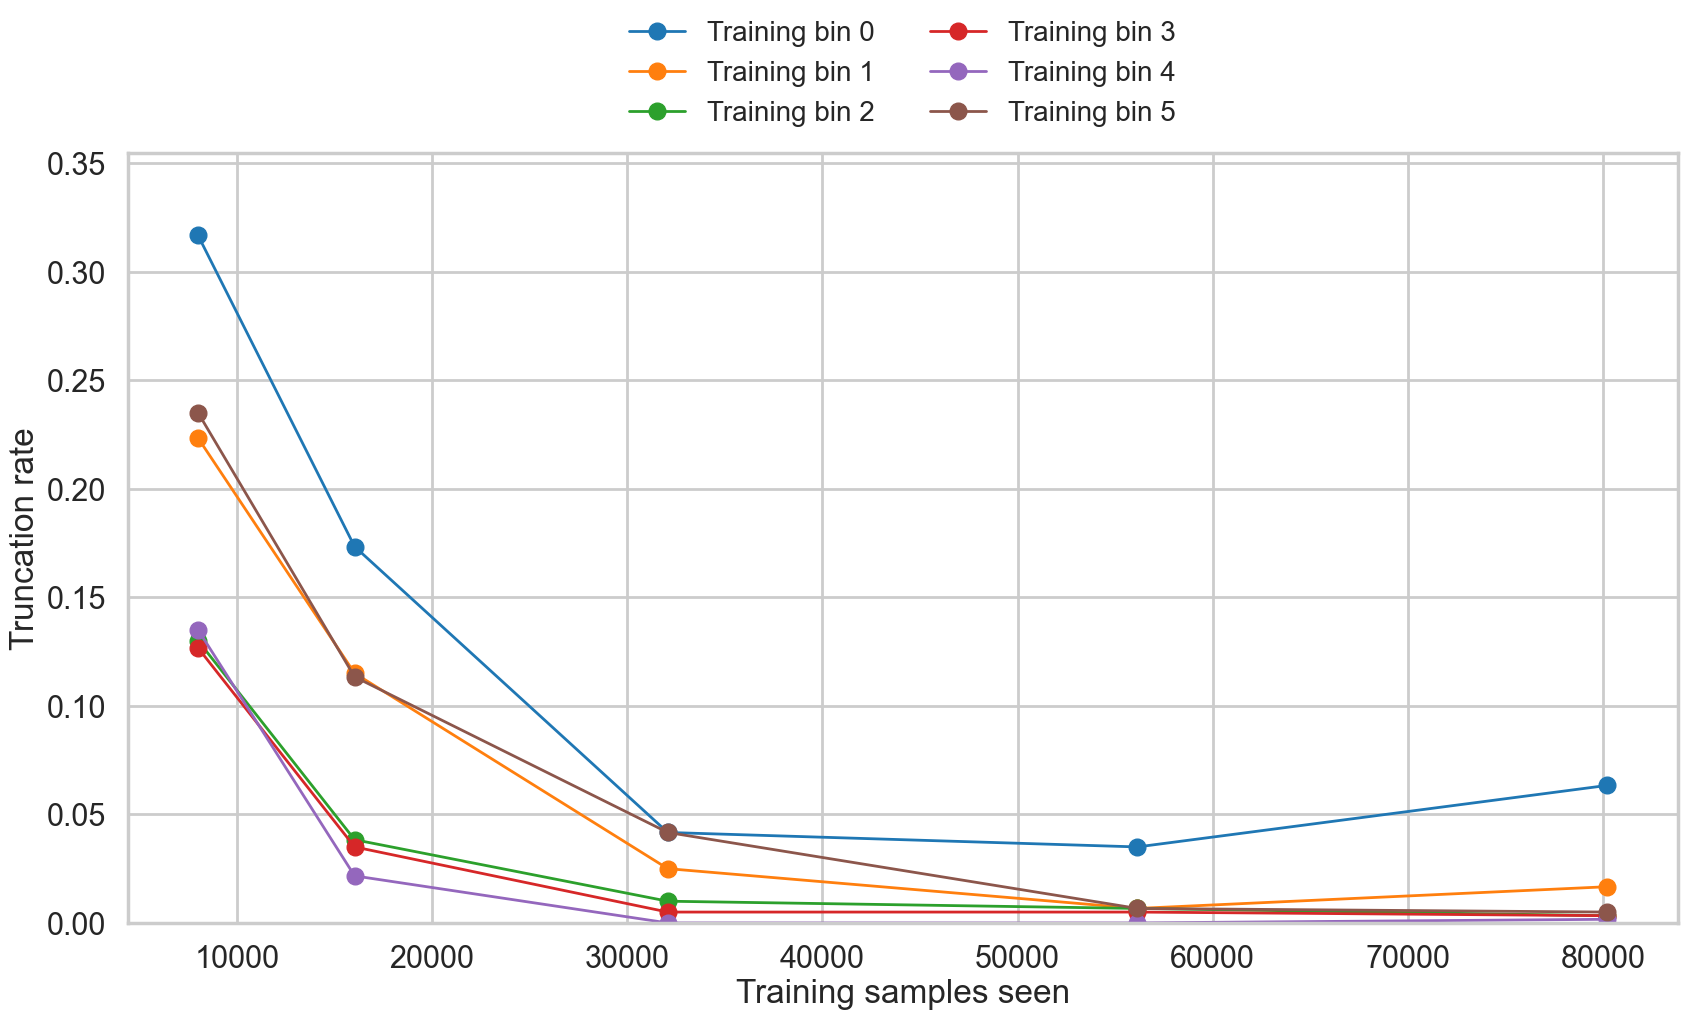

Training,Rows / epoch,Final epoch,Training samples seen,Final truncation rate,Test questions
Training bin 0,"1,604",50,"80,200",0.0633,600
Training bin 1,"1,604",50,"80,200",0.0167,600
Training bin 2,"1,604",50,"80,200",0.0033,600
Training bin 3,"1,604",50,"80,200",0.0033,600
Training bin 4,"1,604",50,"80,200",0.0017,600
Training bin 5,"1,604",50,"80,200",0.0050,600


### Phi-4 Mini — Random600 — truncation — cap 2048

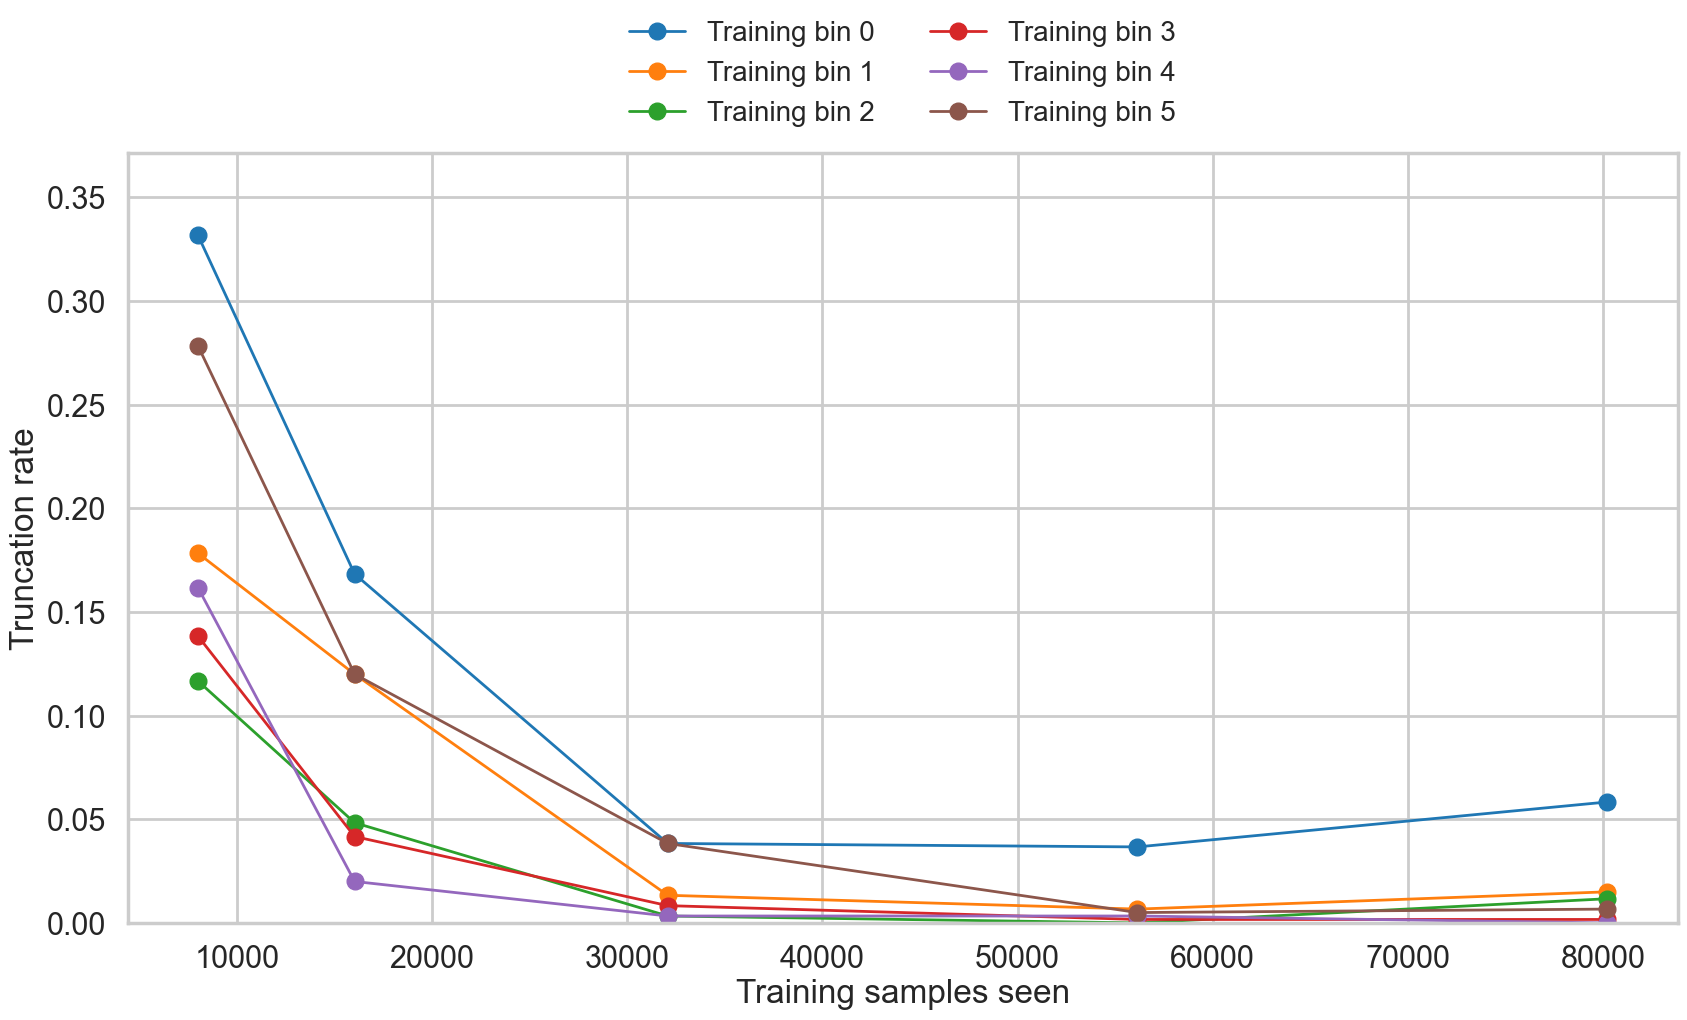

Training,Rows / epoch,Final epoch,Training samples seen,Final truncation rate,Test questions
Training bin 0,"1,604",50,"80,200",0.0583,600
Training bin 1,"1,604",50,"80,200",0.0150,600
Training bin 2,"1,604",50,"80,200",0.0117,600
Training bin 3,"1,604",50,"80,200",0.0017,600
Training bin 4,"1,604",50,"80,200",0.0000,600
Training bin 5,"1,604",50,"80,200",0.0067,600


### Llama 3B — Balanced600 — truncation — cap 2048

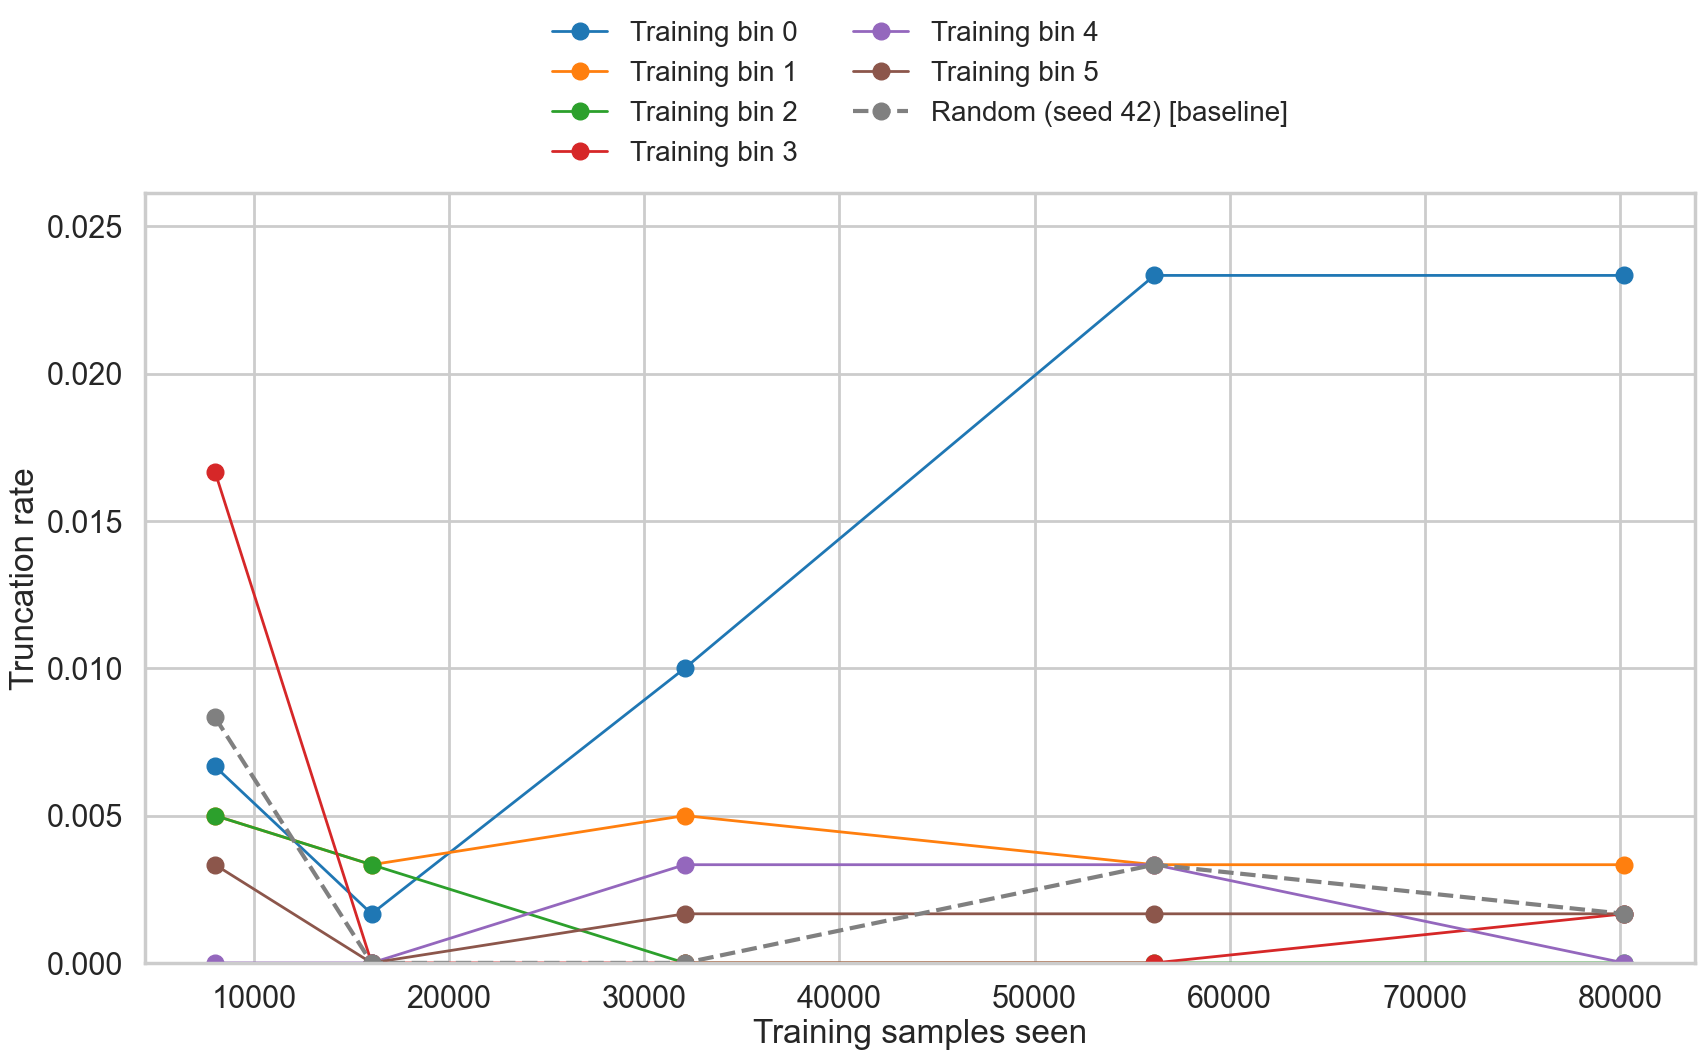

Training,Rows / epoch,Final epoch,Training samples seen,Final truncation rate,Test questions
Training bin 0,"1,604",50,"80,200",0.0233,600
Training bin 1,"1,604",50,"80,200",0.0033,600
Training bin 2,"1,604",50,"80,200",0.0000,600
Training bin 3,"1,604",50,"80,200",0.0017,600
Training bin 4,"1,604",50,"80,200",0.0000,600
Training bin 5,"1,604",50,"80,200",0.0017,600
Random (seed 42) [baseline],"1,604",50,"80,200",0.0017,600


### Llama 3B — Random600 — truncation — cap 2048

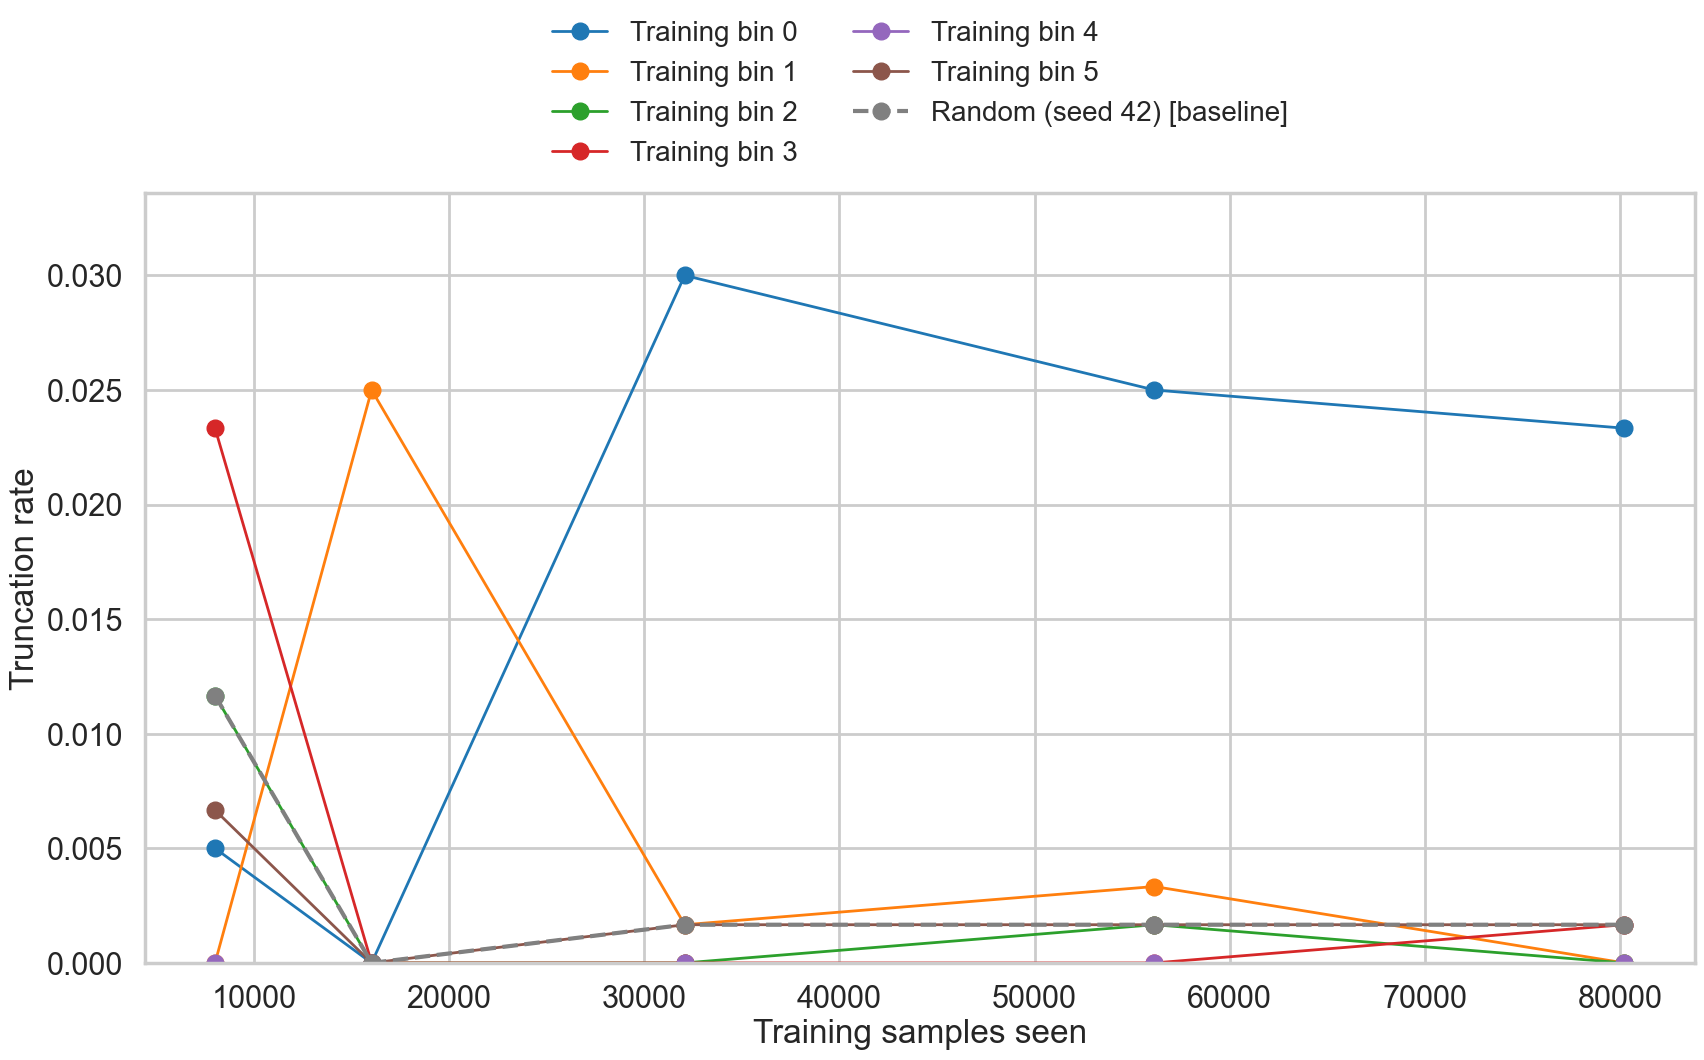

Training,Rows / epoch,Final epoch,Training samples seen,Final truncation rate,Test questions
Training bin 0,"1,604",50,"80,200",0.0233,600
Training bin 1,"1,604",50,"80,200",0.0000,600
Training bin 2,"1,604",50,"80,200",0.0000,600
Training bin 3,"1,604",50,"80,200",0.0017,600
Training bin 4,"1,604",50,"80,200",0.0000,600
Training bin 5,"1,604",50,"80,200",0.0017,600
Random (seed 42) [baseline],"1,604",50,"80,200",0.0017,600


### Phi-4 Mini — in-bin truncation — cap 2048

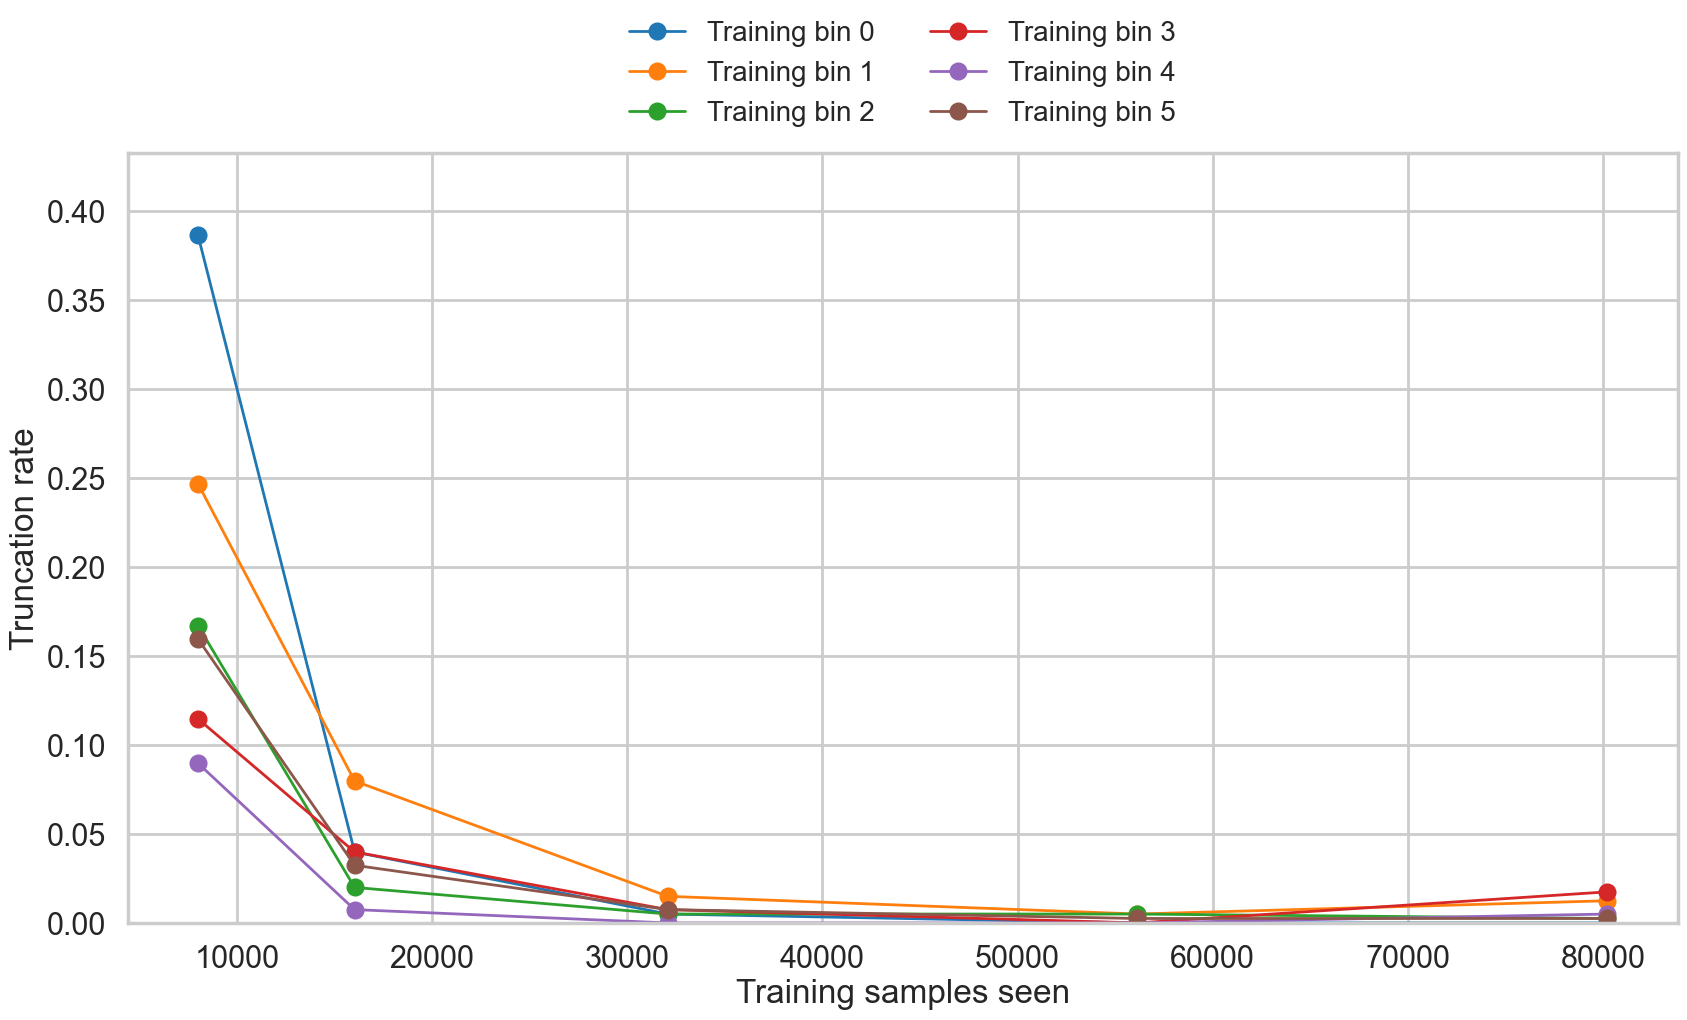

Training,Rows / epoch,Final epoch,Training samples seen,Final truncation rate,Test questions
Training bin 0,"1,604",50,"80,200",0.0000,401
Training bin 1,"1,604",50,"80,200",0.0125,401
Training bin 2,"1,604",50,"80,200",0.0025,401
Training bin 3,"1,604",50,"80,200",0.0175,401
Training bin 4,"1,604",50,"80,200",0.0050,401
Training bin 5,"1,604",50,"80,200",0.0025,401


### Phi-4 Mini — in-bin truncation — cap 4096

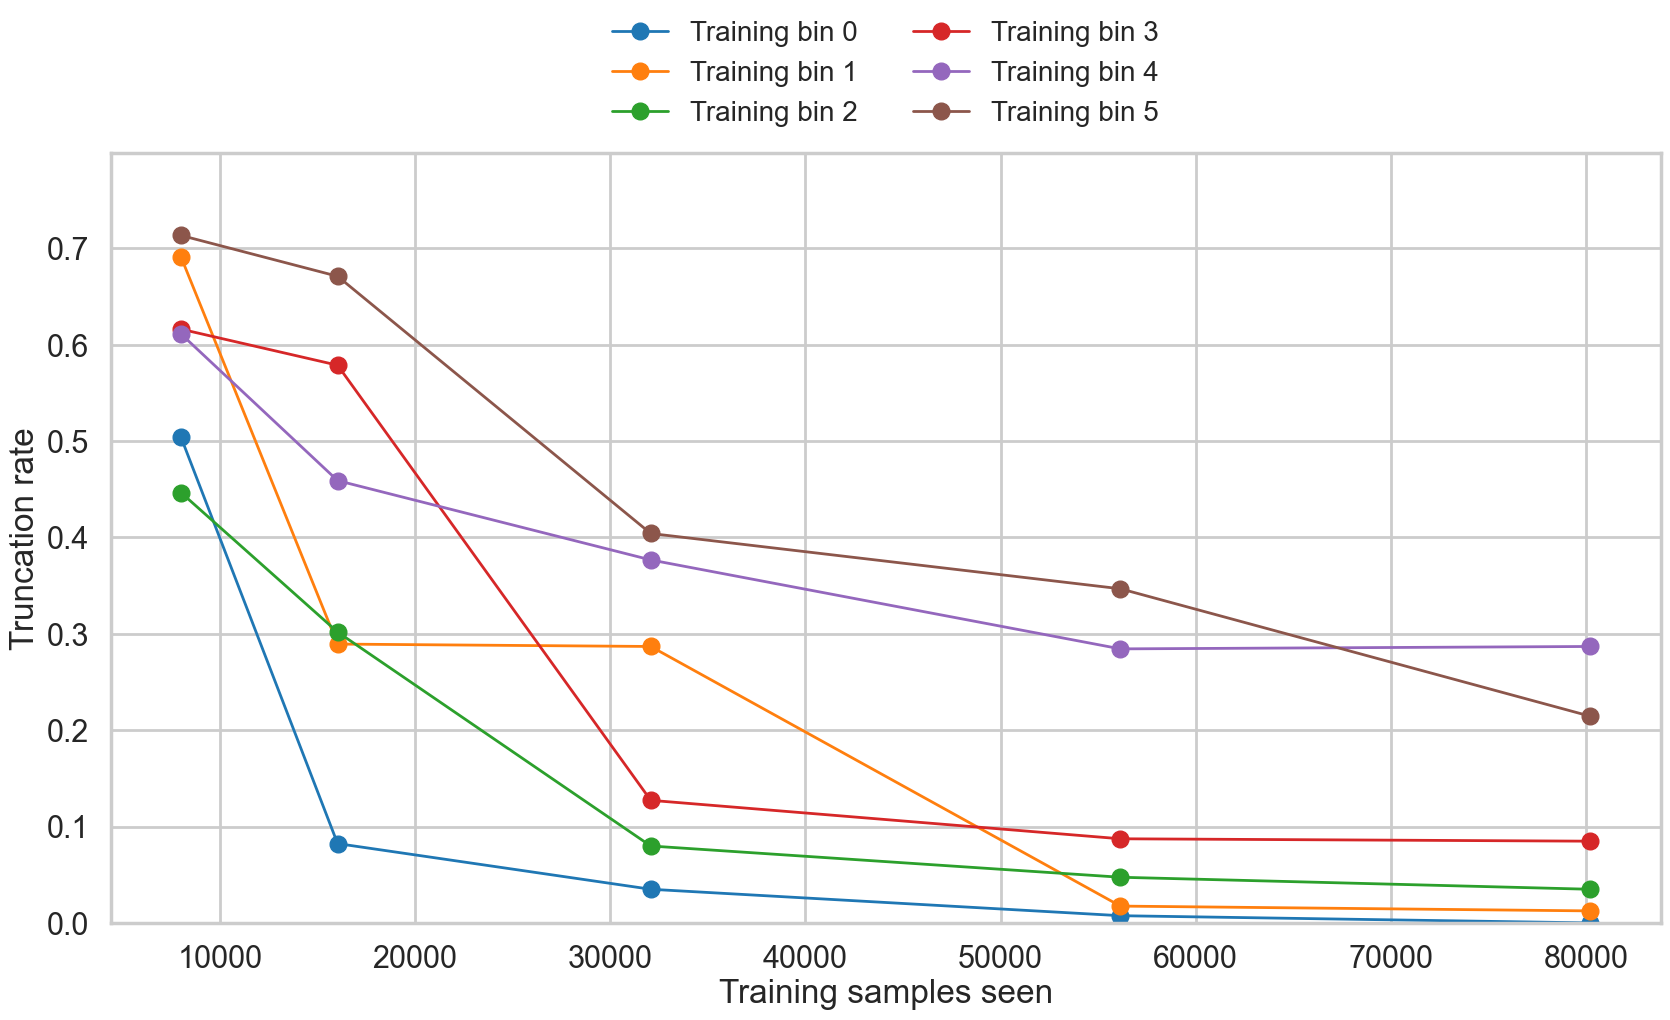

Training,Rows / epoch,Final epoch,Training samples seen,Final truncation rate,Test questions
Training bin 0,"1,604",50,"80,200",0.0000,401
Training bin 1,"1,604",50,"80,200",0.0125,401
Training bin 2,"1,604",50,"80,200",0.0349,401
Training bin 3,"1,604",50,"80,200",0.0848,401
Training bin 4,"1,604",50,"80,200",0.2868,401
Training bin 5,"1,604",50,"80,200",0.2145,401


### Qwen 3B — in-bin truncation — cap 2048

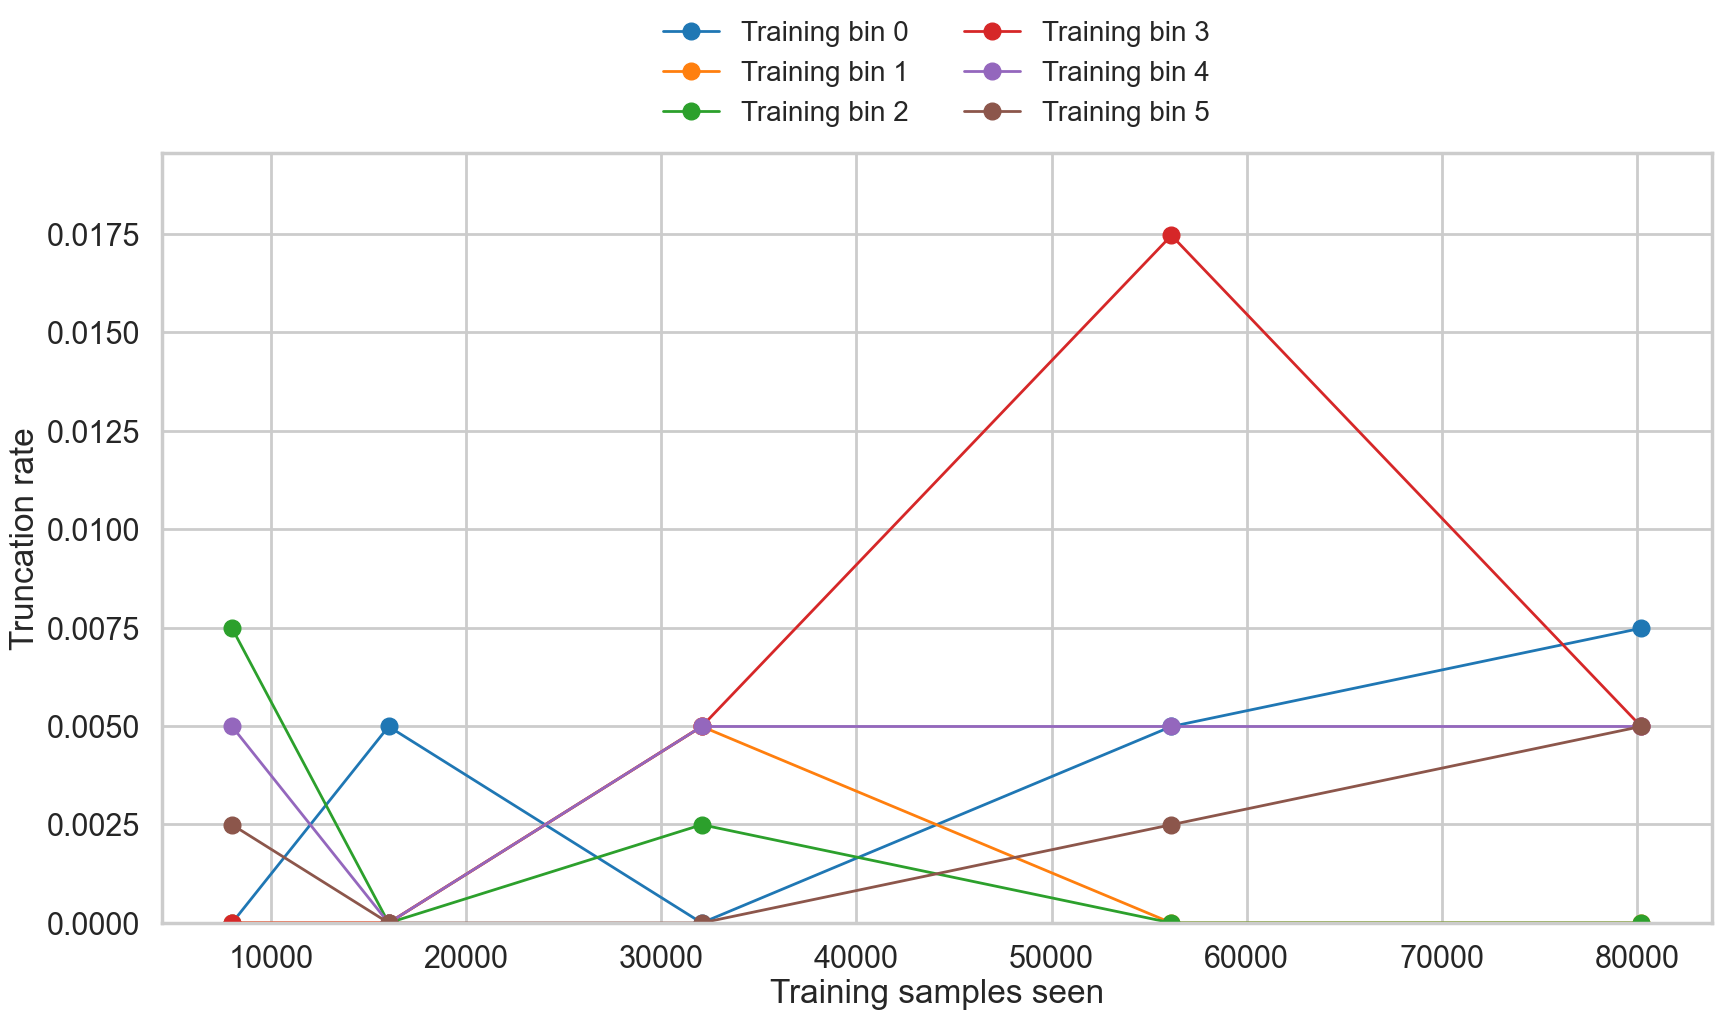

Training,Rows / epoch,Final epoch,Training samples seen,Final truncation rate,Test questions
Training bin 0,"1,604",50,"80,200",0.0075,401
Training bin 1,"1,604",50,"80,200",0.0000,401
Training bin 2,"1,604",50,"80,200",0.0000,401
Training bin 3,"1,604",50,"80,200",0.0050,401
Training bin 4,"1,604",50,"80,200",0.0050,401
Training bin 5,"1,604",50,"80,200",0.0050,401


### Qwen 3B — in-bin truncation — cap 4096

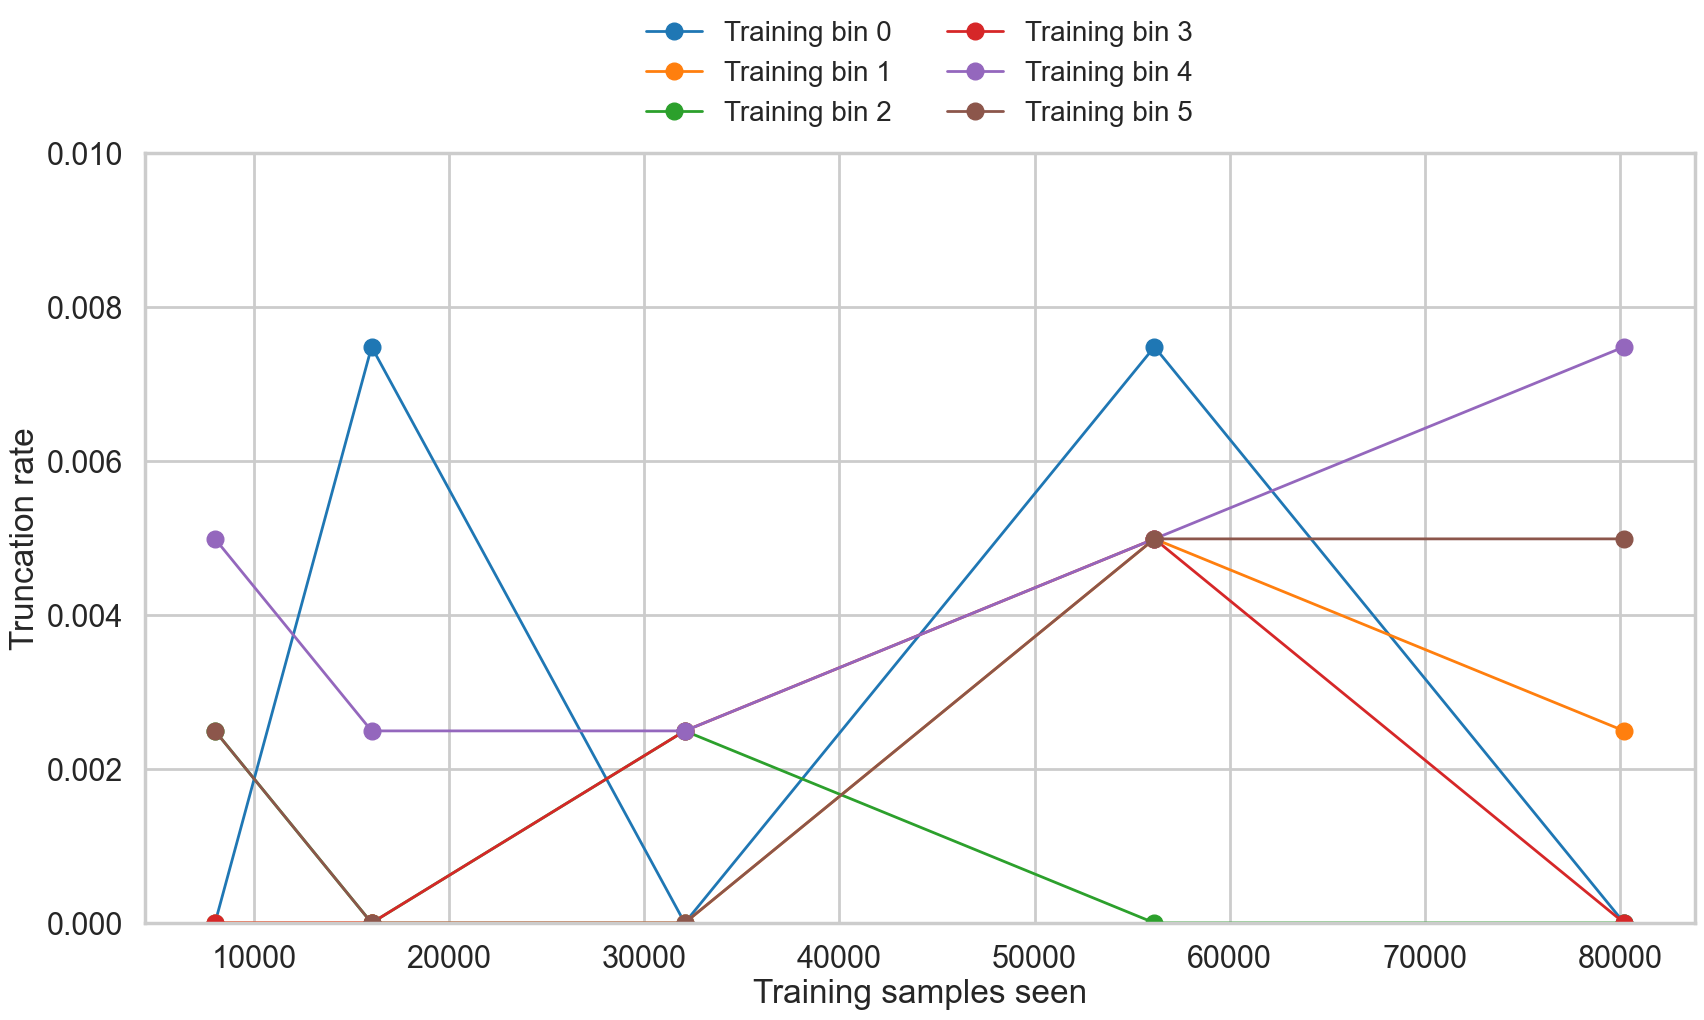

Training,Rows / epoch,Final epoch,Training samples seen,Final truncation rate,Test questions
Training bin 0,"1,604",50,"80,200",0.0000,401
Training bin 1,"1,604",50,"80,200",0.0025,401
Training bin 2,"1,604",50,"80,200",0.0000,401
Training bin 3,"1,604",50,"80,200",0.0000,401
Training bin 4,"1,604",50,"80,200",0.0075,401
Training bin 5,"1,604",50,"80,200",0.0050,401


In [20]:
for model, (nick, label) in MODELS.items():
    for (evaluation, cap), frame in common.loc[common.model.eq(model)].groupby(["evaluation", "cap"]):
        learning_plot(frame, f"{label} — {EVAL_LABELS[evaluation]} — truncation — cap {cap}",
                      f"{nick}_{evaluation}_truncation_cap{cap}", metric="truncation_rate")
for (model, cap), frame in in_bin.groupby(["model", "cap"]):
    nick, label = MODELS[model]
    learning_plot(frame, f"{label} — in-bin truncation — cap {cap}",
                  f"{nick}_in_bin_truncation_cap{cap}", metric="truncation_rate")
